# Current and Future Constraints on the Primordial Power Spectrum

This notebook reproduces the figures and tables of Cheslog, Finson, MacInnis, Sehgal, Afshordi, Nerval, and Hlo$\hat{\mathrm{z}}$ek. (2026),
*"Current and Future Constraints on the Primordial Power Spectrum"*.

It is organized in two parts:

* **Part 1: Current results** reproduces the current-data constraints:
  Figure 1 and the current-constraints table, from the (thinned) MCMC
  chains, along with the marginalized binned-$\mathcal{P}(k)$ chain
  statistics used by the later figures.
* **Part 2: Forecasted results** reproduces the remaining figures and
  tables (Figures 2 through 11), from the saved Fisher matrices, the saved
  Figure 6 points, and the chains and statistics loaded in Part 1.

**Data products.** Everything this notebook loads lives in the
`hdinitpk/data/` directory that ships with the `hdinitpk` package, located
below with `hdinitpk.data_path`. Its contents were precomputed
from the raw chains and Fisher derivative outputs: every Fisher matrix
(saved with `save_fisher_matrix`, with the priors and DESI BAO Fisher
already applied), the Figure 6 $P_\mathrm{lin}(k, z=0)$ points,
getdist-thinned copies of the MCMC chains, the binned-$\mathcal{P}(k)$
chain statistics, and the small binning files the figures need.

**Requirements:** `hdfisher`, `hdinitpk` (its `plotting_utilities` module
provides the colors, labels, and figure/table helpers used below; its
Fisher code produced the saved binned-$\mathcal{P}(k)$ Fisher matrices),
`hd_mock_data`, `hd_pk`, `getdist`, `numpy`, `pandas`, and `matplotlib`.

The cells are meant to be executed in order from top to bottom.

## Imports and plot style

In [55]:
import os
import math

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

from getdist import mcsamples, plots
from getdist.gaussian_mixtures import GaussianND

from hdfisher import utils, fisher
from hd_mock_data import hd_data
from hd_pk import cmb_from_pk

import hdinitpk
from hdinitpk import plotting_utilities
from hdinitpk.plotting_utilities import (
    ratio, print_table, sigfig, getdist_samples, legend_below, set_loglog,
    add_box_errors, param_labels, err_sig_figs, ratio_decimals,
    cb_orange, cb_skyblue, cb_blue, cb_vermillion, cb_pink,
    red, green, darkyellow, magenta, brightblue, blue,
    fig1_colors, exp_colors, exp_labels,
    mpk_labels, mpk_colors, mpk_zorders, param_line_kwargs, flat_legend)

%matplotlib inline

In [2]:
# apply the matplotlib style (rcParams) from plotting_utilities:
plotting_utilities.set_plot_style()


## Configuration

All file locations and global analysis choices are set here.

Three flags choose where the results come from. `chain_source` covers the
MCMC chains and the statistics computed from them, and `fisher_source` the
Fisher matrices. Each is either `'packaged'`, meaning the copy distributed
with `hdinitpk`, or `'custom'`, meaning the one you generated yourself,
which lives in `hdinitpk/data/user_generated_data`. `fig6_source` covers
the Figure 6 points, which come in two halves (the CMB-HD and SO-like
points from Fisher matrices, and the CMB-PAS points from chains), so it
has four options. `'packaged'` uses the published copy of both halves,
`'custom_fisher'` and `'custom_chain'` replace one half with your own, and
`'custom_both'` replaces both. The flags are independent, so you can
rebuild one part of the paper and keep the rest as published.

The binning files and the CMB-HD mock data are inputs rather than results,
so they always come from the package. The bias calculation is not in this
notebook, see `run_hdInitPk_verify_accuracy_settings.py`.

In [3]:
# Where this notebook reads from. Everything distributed with `hdinitpk`
# lives in its `data` directory, resolved with `hdinitpk.data_path` so that
# the notebook runs from any working directory. Everything you generate
# yourself lives in `data/user_generated_data`, resolved with
# `hdinitpk.user_data_path`, which mirrors the same layout.
notebook_data_path = hdinitpk.DATA_DIR
binning_data_path = hdinitpk.data_path('binning')
print(f'loading data products from {notebook_data_path}')


def source_path(source, *parts):
    """The packaged or the user-generated copy of a data directory."""
    if source == 'packaged':
        return hdinitpk.data_path(*parts)
    if source == 'custom':
        return hdinitpk.user_data_path(*parts)
    raise ValueError(f"a source must be 'packaged' or 'custom', "
                     f"not {source!r}")


# The MCMC chains and the cached binned-P(k) statistics.
#
#   'packaged'  the thinned chains distributed with hdinitpk, merged into
#               one file each, with the burn-in already removed.
#   'custom'    chains you have run yourself with
#               run_hdInitPk_current.ipynb, read as cobaya wrote
#               them: full length, `<root>.1.txt` ... `<root>.N.txt`, with
#               the burn-in still in place.
chain_source = 'packaged'

# The twenty Fisher matrices.
#
#   'packaged'  the matrices behind the published forecasts.
#   'custom'    the matrices written by run_hdInitPk_forecasts.py or
#               run_hdInitPk_forecasts.ipynb, from derivatives you have
#               calculated yourself. The file names are the same, so
#               nothing else in the notebook changes.
fisher_source = 'packaged'

# The Figure 6 P_lin(k, z=0) points. These come in two halves, written by
# the two modes of run_hdInitPk_to_LinearPk.py: the CMB-HD and SO-like
# points from the binned-P(k) Fisher matrices (fisher mode), and the
# CMB-PAS points from the binned-P(k) chains (chain mode). Each half can be
# taken from the package or from your own run.
#
#   'packaged'       both halves as published.
#   'custom_fisher'  your CMB-HD and SO-like points, with the published
#                    CMB-PAS points.
#   'custom_chain'   your CMB-PAS points, with the published CMB-HD and
#                    SO-like points.
#   'custom_both'    both halves from your own run.
#
# The theory curve is not a result and is not regenerated, so it is always
# read from the package.
fig6_source = 'packaged'

fig6_sources = {'packaged':      {'fisher': 'packaged', 'chain': 'packaged'},
                'custom_fisher': {'fisher': 'custom',   'chain': 'packaged'},
                'custom_chain':  {'fisher': 'packaged', 'chain': 'custom'},
                'custom_both':   {'fisher': 'custom',   'chain': 'custom'}}
if fig6_source not in fig6_sources:
    raise ValueError(f"fig6_source must be one of {list(fig6_sources)}, "
                     f"not {fig6_source!r}")

chains_data_path = source_path(chain_source, 'chains')
cache_path = source_path(chain_source, 'cached_results')
fisher_matrix_path = source_path(fisher_source, 'fisher_matrices')
fig6_data_paths = {kind: source_path(source, 'fig6')
                   for kind, source in fig6_sources[fig6_source].items()}
fig6_data_paths['theory'] = hdinitpk.data_path('fig6')

print(f'  chains       ({chain_source}) from {chains_data_path}')
print(f'  fisher       ({fisher_source}) from {fisher_matrix_path}')
for _kind in ('fisher', 'chain'):
    print(f'  fig6 {_kind:7s} ({fig6_sources[fig6_source][_kind]}) '
          f'from {fig6_data_paths[_kind]}')


def fig6_file(fname, kind):
    """One Figure 6 input. `kind` is 'fisher' for the CMB-HD and SO-like
    points, 'chain' for the CMB-PAS points, and 'theory' for the theory
    curve; each is read from the directory chosen for it above.

    A file missing from a custom directory raises rather than falling back
    to the packaged copy, which would quietly mix your points with the
    published ones."""
    path = os.path.join(fig6_data_paths[kind], fname)
    if not os.path.isfile(path):
        mode = {'fisher': 'RUN_FISHER_MODE', 'chain': 'RUN_CHAIN_MODE'}
        hint = (f" Write it with run_hdInitPk_to_LinearPk.py with "
                f"{mode[kind]} = True, or change fig6_source."
                if kind in mode else '')
        raise FileNotFoundError(
            f"no {fname} in {fig6_data_paths[kind]} "
            f"(fig6_source = '{fig6_source}')." + hint)
    return path


# Burn-in. The packaged chains had theirs removed BEFORE they were thinned,
# so removing it again would silently discard half of what is left. Raw
# cobaya output still carries it, and 0.5 is what the paper used.
chain_ignore_rows = 0.0 if (chain_source == 'packaged') else 0.5

# The packaged chains are named for what they are; a cobaya run is named by
# its `output:` line, which follows the input file. Map one to the other for
# 'custom'. A name with no entry here is looked for as it stands, which is
# what the CMB-HD mock chains of Figure 9 need: they come from
# `cobaya_yaml_files/HD/`, not from the current-data notebook.
custom_chain_names = {
    'pas_lcdm_nrun':         'lcdm_nrun',
    'pas_w0wacdm_nrun':      'w0wacdm_nrun',
    'pas_lcdm_nrun_nnu':     'lcdm_nrun_nnu',
    'pas_lcdm_nrun_nnu_mnu': 'lcdm_nrun_nnu_mnu',
    'pact_lb_nrun':          'p_act_lb',
    'hd_camb_mcmc_9param':   'hd_camb_9_param',
    'hd_class_mcmc_9param':  'hd_class_9_param',
}

# CMB-HD mock data from hdMockData. Only the binning matrix is read here
# (in the CAMB-vs-CLASS section); the bin edges are the same in v1.1 and
# v1.2, but pin the version rather than leaving it at 'latest' so a new
# release cannot change what the notebook plots.
data_version = 'v1.2'
hd_datalib = hd_data.HDMockData(version=data_version)

# Fiducial optical depth, used wherever an explicit e^{-2 tau} factor is
# applied to the primordial power spectrum.
tau = 0.0544

# Figure saving. When True, every figure below is written to the current
# working directory as `fig<N>-<month>-<day>-<year>.png`, using the date on
# which the notebook is run (for example `fig1-july-26-2026.png`). Set to
# False to display the figures without writing any files.
save_figures = False


def save_figure(fig_name, **savefig_kwargs):
    """Save the current figure via `plotting_utilities.save_figure`, but
    only if the `save_figures` flag above is True."""
    plotting_utilities.save_figure(fig_name, enabled=save_figures,
                                   **savefig_kwargs)

loading data products from /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdInitPk_upload_latest/hdinitpk/data
  chains       (packaged) from /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdInitPk_upload_latest/hdinitpk/data/chains
  fisher       (packaged) from /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdInitPk_upload_latest/hdinitpk/data/fisher_matrices
  fig6 fisher  (packaged) from /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdInitPk_upload_latest/hdinitpk/data/fig6
  fig6 chain   (packaged) from /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdInitPk_upload_latest/hdinitpk/data/fig6


In [4]:
# Parameter sets used throughout. The naming convention follows CAMB
# (see the CAMB <-> CLASS translation section below for the CLASS names).
nine_params = ['mnu', 'tau', 'logA', 'H0', 'ombh2', 'omch2', 'ns', 'nnu', 'nrun']
eight_params = ['mnu', 'tau', 'logA', 'H0', 'ombh2', 'omch2', 'ns', 'nnu']
six_params = ['tau', 'logA', 'H0', 'ombh2', 'omch2', 'ns',]
feedback_params = nine_params + ['HMCode_logT_AGN', 'n_ksz', 'A_ksz']

## Helper functions

The figure and table helpers (`ratio`, `print_table`, `sigfig`,
`getdist_samples`, `legend_below`, `set_loglog`, `add_box_errors`) were
imported from `hdinitpk.plotting_utilities` above. The helpers below load
the data products from the data directory.

In [5]:
def load_saved_fisher(name):
    """Load a saved Fisher matrix from `fisher_matrix_path`, which follows
    `fisher_source`. Returns the `(fisher_matrix, params)` pair, exactly as
    `Fisher.get_fisher` would; the tau prior (and, where applicable, the
    DESI BAO Fisher and the HMCode_logT_AGN prior) are already applied.
    Every file built from a CLASS configuration (`hd_class_*`, `hd_ext_*`,
    `so_class_*` and `so_ext_*`) keeps native CLASS parameter names;
    translate those with `from_class_fisher` / `from_class_errors` (defined
    below) at load time.

    A matrix missing from a custom directory raises rather than falling back
    to the packaged copy, which would quietly mix a forecast you rebuilt
    with one you did not."""
    path = os.path.join(fisher_matrix_path, f'{name}.txt')
    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"no Fisher matrix '{name}' in {fisher_matrix_path}. With "
            f"fisher_source = '{fisher_source}' that is where every matrix "
            "is read from. Rebuild it with run_hdInitPk_forecasts.py, or "
            "set fisher_source = 'packaged'.")
    return fisher.load_fisher_matrix(path)


def load_saved_results(name):
    """Read a saved results file from `<data>/cached_results`: one row per
    quantity, with the name followed by its values."""
    fname = os.path.join(cache_path, f'{name}.txt')
    results = {}
    with open(fname, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            key, *values = line.split()
            results[key] = [float(v) for v in values]
    print(f"loaded '{name}' from {fname}")
    return results


def find_chain_root(name):
    """Locate the getdist root of a chain by name, anywhere under
    `chains_data_path`.

    Both layouts are searched, since the two sources differ: the packaged
    chains are one merged `<root>.txt` in a subdirectory (`pas/`,
    `P-ACT-LB/`, `hd/`), while cobaya writes `<root>.1.txt` ...
    `<root>.N.txt` wherever its `output:` line pointed. In 'custom' mode
    the name is translated through `custom_chain_names` first.

    A root only counts if the SAMPLES file is there. Matching on
    `<root>.paramnames` alone would let a stray metadata file in the wrong
    subdirectory shadow the real chain, and getdist would then fail with a
    bare 'No chains found'.
    """
    wanted = (custom_chain_names.get(name, name)
              if chain_source == 'custom' else name)

    found = []
    for dirpath, _dirnames, filenames in os.walk(chains_data_path):
        names = set(filenames)
        if (f'{wanted}.txt' in names
                or any(f.startswith(f'{wanted}.') and f.endswith('.txt')
                       and f[len(wanted) + 1:-4].isdigit() for f in names)):
            found.append(os.path.join(dirpath, wanted))

    if not found:
        raise FileNotFoundError(
            f"could not find the samples of chain '{name}'"
            + (f" (as '{wanted}')" if wanted != name else '')
            + f" under {chains_data_path}; looked for <root>.txt and "
            f"<root>.N.txt. With chain_source = '{chain_source}', the name "
            "is taken from "
            + ("`custom_chain_names`, which may need an entry for it."
               if chain_source == 'custom' else "the packaged layout."))
    if len(found) > 1:
        raise FileNotFoundError(
            f"the chain '{name}' is ambiguous: samples files exist at "
            f"{found}. Keep only one.")

    root = found[0]
    # getdist takes the column names from `<root>.paramnames` for a getdist
    # chain, or from cobaya's `<root>.updated.yaml` for raw sampler output.
    # With neither it fails deep inside `readChains` with a bare
    # "'NoneType' object has no attribute 'deleteIndices'", so check here.
    folder, prefix = os.path.split(root)
    has_names = os.path.exists(f'{root}.paramnames') or any(
        f.startswith(prefix) and f.lower().endswith(('updated.yaml', 'full.yaml'))
        for f in os.listdir(folder))
    if not has_names:
        raise FileNotFoundError(
            f"found the samples of '{name}' at {root}, but neither "
            f"{prefix}.paramnames nor a cobaya {prefix}*.updated.yaml beside "
            "them, so getdist cannot name the columns. Copy the whole run "
            "directory, not only the .txt files.")
    return root


def load_chain(name):
    """Load one MCMC chain from `<chains_data_path>`.

    `chain_ignore_rows`, set alongside `chain_source` above, is 0 for the
    packaged chains, whose burn-in was removed before they were thinned,
    and 0.5 for raw cobaya output, which still carries it.
    """
    return mcsamples.loadMCSamples(
        find_chain_root(name), settings={'ignore_rows': chain_ignore_rows})


# Gelman-Rubin R-1 of each full chain, recorded before the chains were
# thinned (it cannot be recomputed from a merged thinned chain):
chain_convergence = {}
convergence_file = os.path.join(chains_data_path, 'chain_convergence.txt')
if os.path.exists(convergence_file):
    with open(convergence_file, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            key, val = line.split()
            chain_convergence[key] = float(val)
else:
    print(f'no {convergence_file}; R-1 will be reported as nan')

# Accept either naming. The packaged file is keyed by the packaged chain
# names; one written beside your own cobaya output is keyed by that run's
# `output:` name, so add the packaged name as an alias for it.
for _canonical, _cobaya_name in custom_chain_names.items():
    if _canonical not in chain_convergence and _cobaya_name in chain_convergence:
        chain_convergence[_canonical] = chain_convergence[_cobaya_name]

## CAMB <-> CLASS parameter-name translation

The CLASS Fisher matrices (`hd_class_*` and `hd_ext_*`) are saved with their original CLASS parameter names. We translate them to CAMB paramater names when they are loaded in for ease of use.

In [6]:
# NOTE: deliberately named `*_fisher_params` so it does not interfere with the
# `camb_to_class_chain_params` defined in the Figure 9 section for the MCMC
# chain columns. Those are chain column names ('N_eff'), which are not the
# same as the Fisher parameter names ('N_ur').
camb_to_class_fisher_params = {
    'ombh2': 'omega_b',
    'omch2': 'omega_cdm',
    'theta': 'theta_s_100',
    'tau':   'tau_reio',
    'logA':  'ln_A_s_1e10',
    'As':    'A_s',
    'ns':    'n_s',
    'H0':    'H0',
    # N_eff is varied as `N_ur`, the number of massless neutrinos, which
    # CLASS takes directly. With the three massive species fixed, a change
    # in N_ur is the same change in N_eff.
    'nnu':   'N_ur',
    # `sum_m_ncdm` is the TOTAL mass, the same quantity as CAMB's `mnu`.
    # `m_ncdm` (per-species) is what CLASS receives, but hdfisher builds
    # it from `sum_m_ncdm` and it is never a varied parameter.
    'mnu':   'sum_m_ncdm',
    'nrun':  'alpha_s',
    'omk':   'Omega_k',
    'w':     'w0_fld',
    'wa':    'wa_fld',
    'HMCode_logT_AGN': 'log10T_heat_hmcode',
}
class_to_camb_fisher_params = {v: k for k, v in camb_to_class_fisher_params.items()}


def to_class(params):
    """CAMB parameter names -> CLASS names, for passing INTO a CLASS Fisher.
    Accepts a list of names or a dict keyed by name (e.g. `priors`)."""
    if isinstance(params, dict):
        return {camb_to_class_fisher_params.get(p, p): v for p, v in params.items()}
    return [camb_to_class_fisher_params.get(p, p) for p in params]


def from_class_errors(errors):
    """`get_fisher_errors` output -> CAMB names."""
    return {class_to_camb_fisher_params.get(p, p): v for p, v in errors.items()}


def from_class_fisher(result):
    """`get_fisher` output -> CAMB names. Only the parameter names change;
    every varied CLASS parameter is the same quantity as its CAMB
    counterpart, so the matrix itself is untouched."""
    matrix, params = result
    return matrix, [class_to_camb_fisher_params.get(p, p) for p in params]


def from_class_derivs(result):
    """`load_cmb_fisher_derivs` output -> CAMB names. The derivatives
    themselves are unchanged."""
    ells, derivs = result
    out = {}
    for cmb_type, per_param in derivs.items():
        out[cmb_type] = {class_to_camb_fisher_params.get(p, p): spectra
                         for p, spectra in per_param.items()}
    return ells, out


def check_class_names(fisherlib, params):
    """Raise if a translated name is not a varied parameter of
    `fisherlib`, instead of failing later with a bare KeyError inside
    `calc_cmb_fisher`."""
    wanted = to_class(params)
    missing = [p for p in wanted if p not in fisherlib.fisher_params]
    if missing:
        raise KeyError(
            f"these CLASS parameter names are not in the Fisher: {missing}.\n"
            f"  requested : {wanted}\n"
            f"  available : {sorted(fisherlib.fisher_params)}\n"
            "Fix `camb_to_class_fisher_params` above to match the names in your "
            "CLASS parameter and step-size files.")
    return wanted

# Part 1: Current results

Everything in this part comes from the MCMC chains run on current data:
the CMB-PAS + DESI DR2 chains for the four cosmological models, the
P-ACT-LB comparison chain, and the binned-$\mathcal{P}(k)$ chains. The
chains were thinned with getdist (`MCSamples.weighted_thin`) before being
saved; the marginalized binned-$\mathcal{P}(k)$ statistics were computed
from the full, un-thinned chains.

## MCMC chains for the current constraints

Load the (thinned) CMB-PAS + DESI DR2 chains for the four cosmological
models, and the P-ACT-LB comparison chain. These are used for Figures 1, 2,
and 4 and for the current-constraints table. The quoted R-1 values were
computed from the full chains, and read from `chain_convergence.txt`.

Loading the chains takes a few minutes, since getdist reads and analyses
each one when it is loaded.

In [7]:
chain_models = ['lcdm_nrun', 'w0wacdm_nrun', 'lcdm_nrun_nnu', 'lcdm_nrun_nnu_mnu']

# `samples` holds the distributions plotted in Figures 2 and 4, keyed first by
# data set ('pas' for the CMB-PAS + DESI chains; 'so' and 'hd' Fisher
# forecasts are added below) and then by cosmological model.
samples = {'pas': {}}
mcmc_means = {}
for param_model in chain_models:
    chain = load_chain(f'pas_{param_model}')
    chain.paramNames.parWithName('nrun').label = r'\alpha_\mathrm{s}'
    cosmomc_theta = chain.getParams().cosmomc_theta
    chain.addDerived(100 * cosmomc_theta, 'theta', label=r'100\theta_\mathrm{MC}')
    samples['pas'][param_model] = chain

    mcmc_means[param_model] = {}
    mstats = chain.getMargeStats()
    for param in mstats.list():
        mcmc_means[param_model][param] = mstats.parWithName(param).mean

    r_minus_1 = chain_convergence.get(f'pas_{param_model}', float('nan'))
    print(f'{param_model:22s} : R-1 = {r_minus_1:7.4f} (full chain)')

# Center the Fisher forecast contours (Figures 2 and 4) on the marginalized
# means of the 9-parameter chain.
mcmc_fid_params = mcmc_means['lcdm_nrun_nnu_mnu'].copy()



/gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdInitPk_upload_latest/hdinitpk/data/chains/pas/pas_lcdm_nrun.txt
Removed no burn in
lcdm_nrun              : R-1 =  0.0045 (full chain)
/gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdInitPk_upload_latest/hdinitpk/data/chains/pas/pas_w0wacdm_nrun.txt
Removed no burn in
w0wacdm_nrun           : R-1 =  0.0051 (full chain)
/gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdInitPk_upload_latest/hdinitpk/data/chains/pas/pas_lcdm_nrun_nnu.txt
Removed no burn in
lcdm_nrun_nnu          : R-1 =  0.0051 (full chain)
/gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdInitPk_upload_latest/hdinitpk/data/chains/pas/pas_lcdm_nrun_nnu_mnu.txt
Removed no burn in
lcdm_nrun_nnu_mnu      : R-1 =  0.0053 (full chain)


## Inflation model predictions

Predictions for $n_\mathrm{s}$ and $\alpha_\mathrm{s}$ from the early
Universe models discussed in the paper. Models with a range of predictions
are evaluated at the endpoints of the assumed range of e-folds
($N_* \in [47, 57]$) or of $\theta_*/l_p$.

In [8]:
monodromy = {'nrun': np.zeros(2), 'ns': np.zeros(2)}
SBSGUT = {'nrun': np.zeros(2), 'ns': np.zeros(2)}
QQG = {'nrun': np.zeros(2), 'ns': np.zeros(2)}
poly = {'nrun': np.zeros(2), 'ns': np.zeros(2)}
for i, N_star in enumerate(np.linspace(47, 57, 2)):
    QQG['nrun'][i] = -4 / (3 * (N_star**2))
    QQG['ns'][i] = 1 - (4 / (3 * N_star))
    monodromy['nrun'][i] = -6 / (5 * N_star**2)
    monodromy['ns'][i] = 1 - (6 / (5 * N_star))
    SBSGUT['nrun'][i] = -1 / (N_star**2)
    SBSGUT['ns'][i] = 1 - (1 / N_star)
    poly['ns'][i] = 1 - (2 / N_star) * (3 / 4)
    poly['nrun'][i] = -(2 / N_star**2) * (3 / 4)

rhc_theta_star_lp_vals = np.linspace(0.1, 10, 2)
inflation_models = {
    'starobinsky': {'ns': [1 - 2/50, 1 - 2/60], 'nrun': [-2/(50**2), -2/(60**2)]},
    'bithermal': {'ns': [0.96478], 'nrun': [-1.8e-3]},
    'rhc': {'ns': [1 - (1 / (32.17 + np.log(theta_star_lp)))
                   for theta_star_lp in rhc_theta_star_lp_vals],
            'nrun': [1 / ((32.17 + np.log(theta_star_lp))**2)
                     for theta_star_lp in rhc_theta_star_lp_vals]},
    'qqg': QQG.copy(),
    'sbs': SBSGUT.copy(),
    'mono': monodromy.copy(),
    'poly': poly.copy(),
}

In [9]:
# Styling for Figure 1 (and reused for the inflation models in Figure 2).
data_label = 'CMB-PAS + DESI DR2'
model_labels = {
    'lcdm_nrun': r'$\Lambda$CDM+$\alpha_\mathrm{s}$',
    'w0wacdm_nrun': r'$w_0 w_a$CDM+$\alpha_\mathrm{s}$',
    'lcdm_nrun_nnu': r'$\Lambda$CDM+$\alpha_\mathrm{s}$+$N_\mathrm{eff}$',
    'lcdm_nrun_nnu_mnu': r'$\Lambda$CDM+$\alpha_\mathrm{s}$+$N_\mathrm{eff}$+$\sum m_\nu$',
}

fig1_param_models = chain_models
plt_inflation_models = ['bithermal', 'starobinsky', 'mono', 'rhc', 'qqg', 'sbs', 'poly']

# settings for the data contours:
contour_lw = 1.05
contour_alpha = 0.8




# `fig1_colors` (one color per cosmological model) is imported from
# `hdinitpk.plotting_utilities`.
fig1_kwargs = {param_model: {'color': fig1_colors[param_model],
                             'lw': contour_lw,
                             'label': model_labels[param_model]}
               for param_model in fig1_param_models}

# the colorblind-friendly palette (cb_orange, cb_skyblue, cb_blue,
# cb_vermillion, cb_pink) is imported from `hdinitpk.plotting_utilities`.
inflation_models_markersize = 6
inflation_models_lw = 1.5

inflation_models['starobinsky']['kwargs'] = {
    'label': r'Starobinsky$\, / \,$Higgs$\, / \,$Exp. $\alpha$-attractor',
    'zorder': 3, 'ls': '-', 'lw': inflation_models_lw,
    'marker': 'p', 'markersize': inflation_models_markersize,
    'color': cb_blue}
inflation_models['bithermal']['kwargs'] = {
    'label': 'Bi-thermal', 'ls': 'none',
    'marker': '*', 'markersize': 10, 'color': cb_skyblue}
inflation_models['rhc']['kwargs'] = {
    'label': 'Renorm. Holo. Cosmo.', 'ls': '-', 'lw': inflation_models_lw,
    'marker': 'D', 'markersize': inflation_models_markersize,
    'zorder': 3, 'color': cb_vermillion}
inflation_models['qqg']['kwargs'] = {
    'label': 'Quant. Quad. Grav.', 'zorder': 3,
    'ls': '-', 'lw': inflation_models_lw,
    'marker': 's', 'markersize': inflation_models_markersize,
    'color': cb_orange}
inflation_models['mono']['kwargs'] = {
    'label': r'Axion-monodromy$\, / \,$$V(\phi) \propto \phi^n, n=2/5$',
    'zorder': 5, 'ls': '-', 'lw': inflation_models_lw,
    'marker': '^', 'markersize': inflation_models_markersize,
    'color': 'tab:green'}
inflation_models['sbs']['kwargs'] = {
    'label': 'SUSY GUTS', 'zorder': 4,
    'ls': '-', 'lw': inflation_models_lw,
    'marker': 'o', 'markersize': inflation_models_markersize,
    'color': cb_pink}
inflation_models['poly']['kwargs'] = {
    'label': r'Poly. $\alpha$-attractor ($\kappa = 2$)', 'zorder': 5,
    'ls': '-', 'lw': inflation_models_lw,
    'marker': 'v', 'markersize': inflation_models_markersize,
    'color': 'dimgray'}

# `param_line_kwargs` (the nrun = 0 / ns = 1 guide lines) and
# `flat_legend` are imported from `hdinitpk.plotting_utilities`.


# Figure 1

Current constraints on ($n_\mathrm{s}$, $\alpha_\mathrm{s}$) from
CMB-PAS + DESI DR2 for the four cosmological models, compared to the
inflation model predictions.

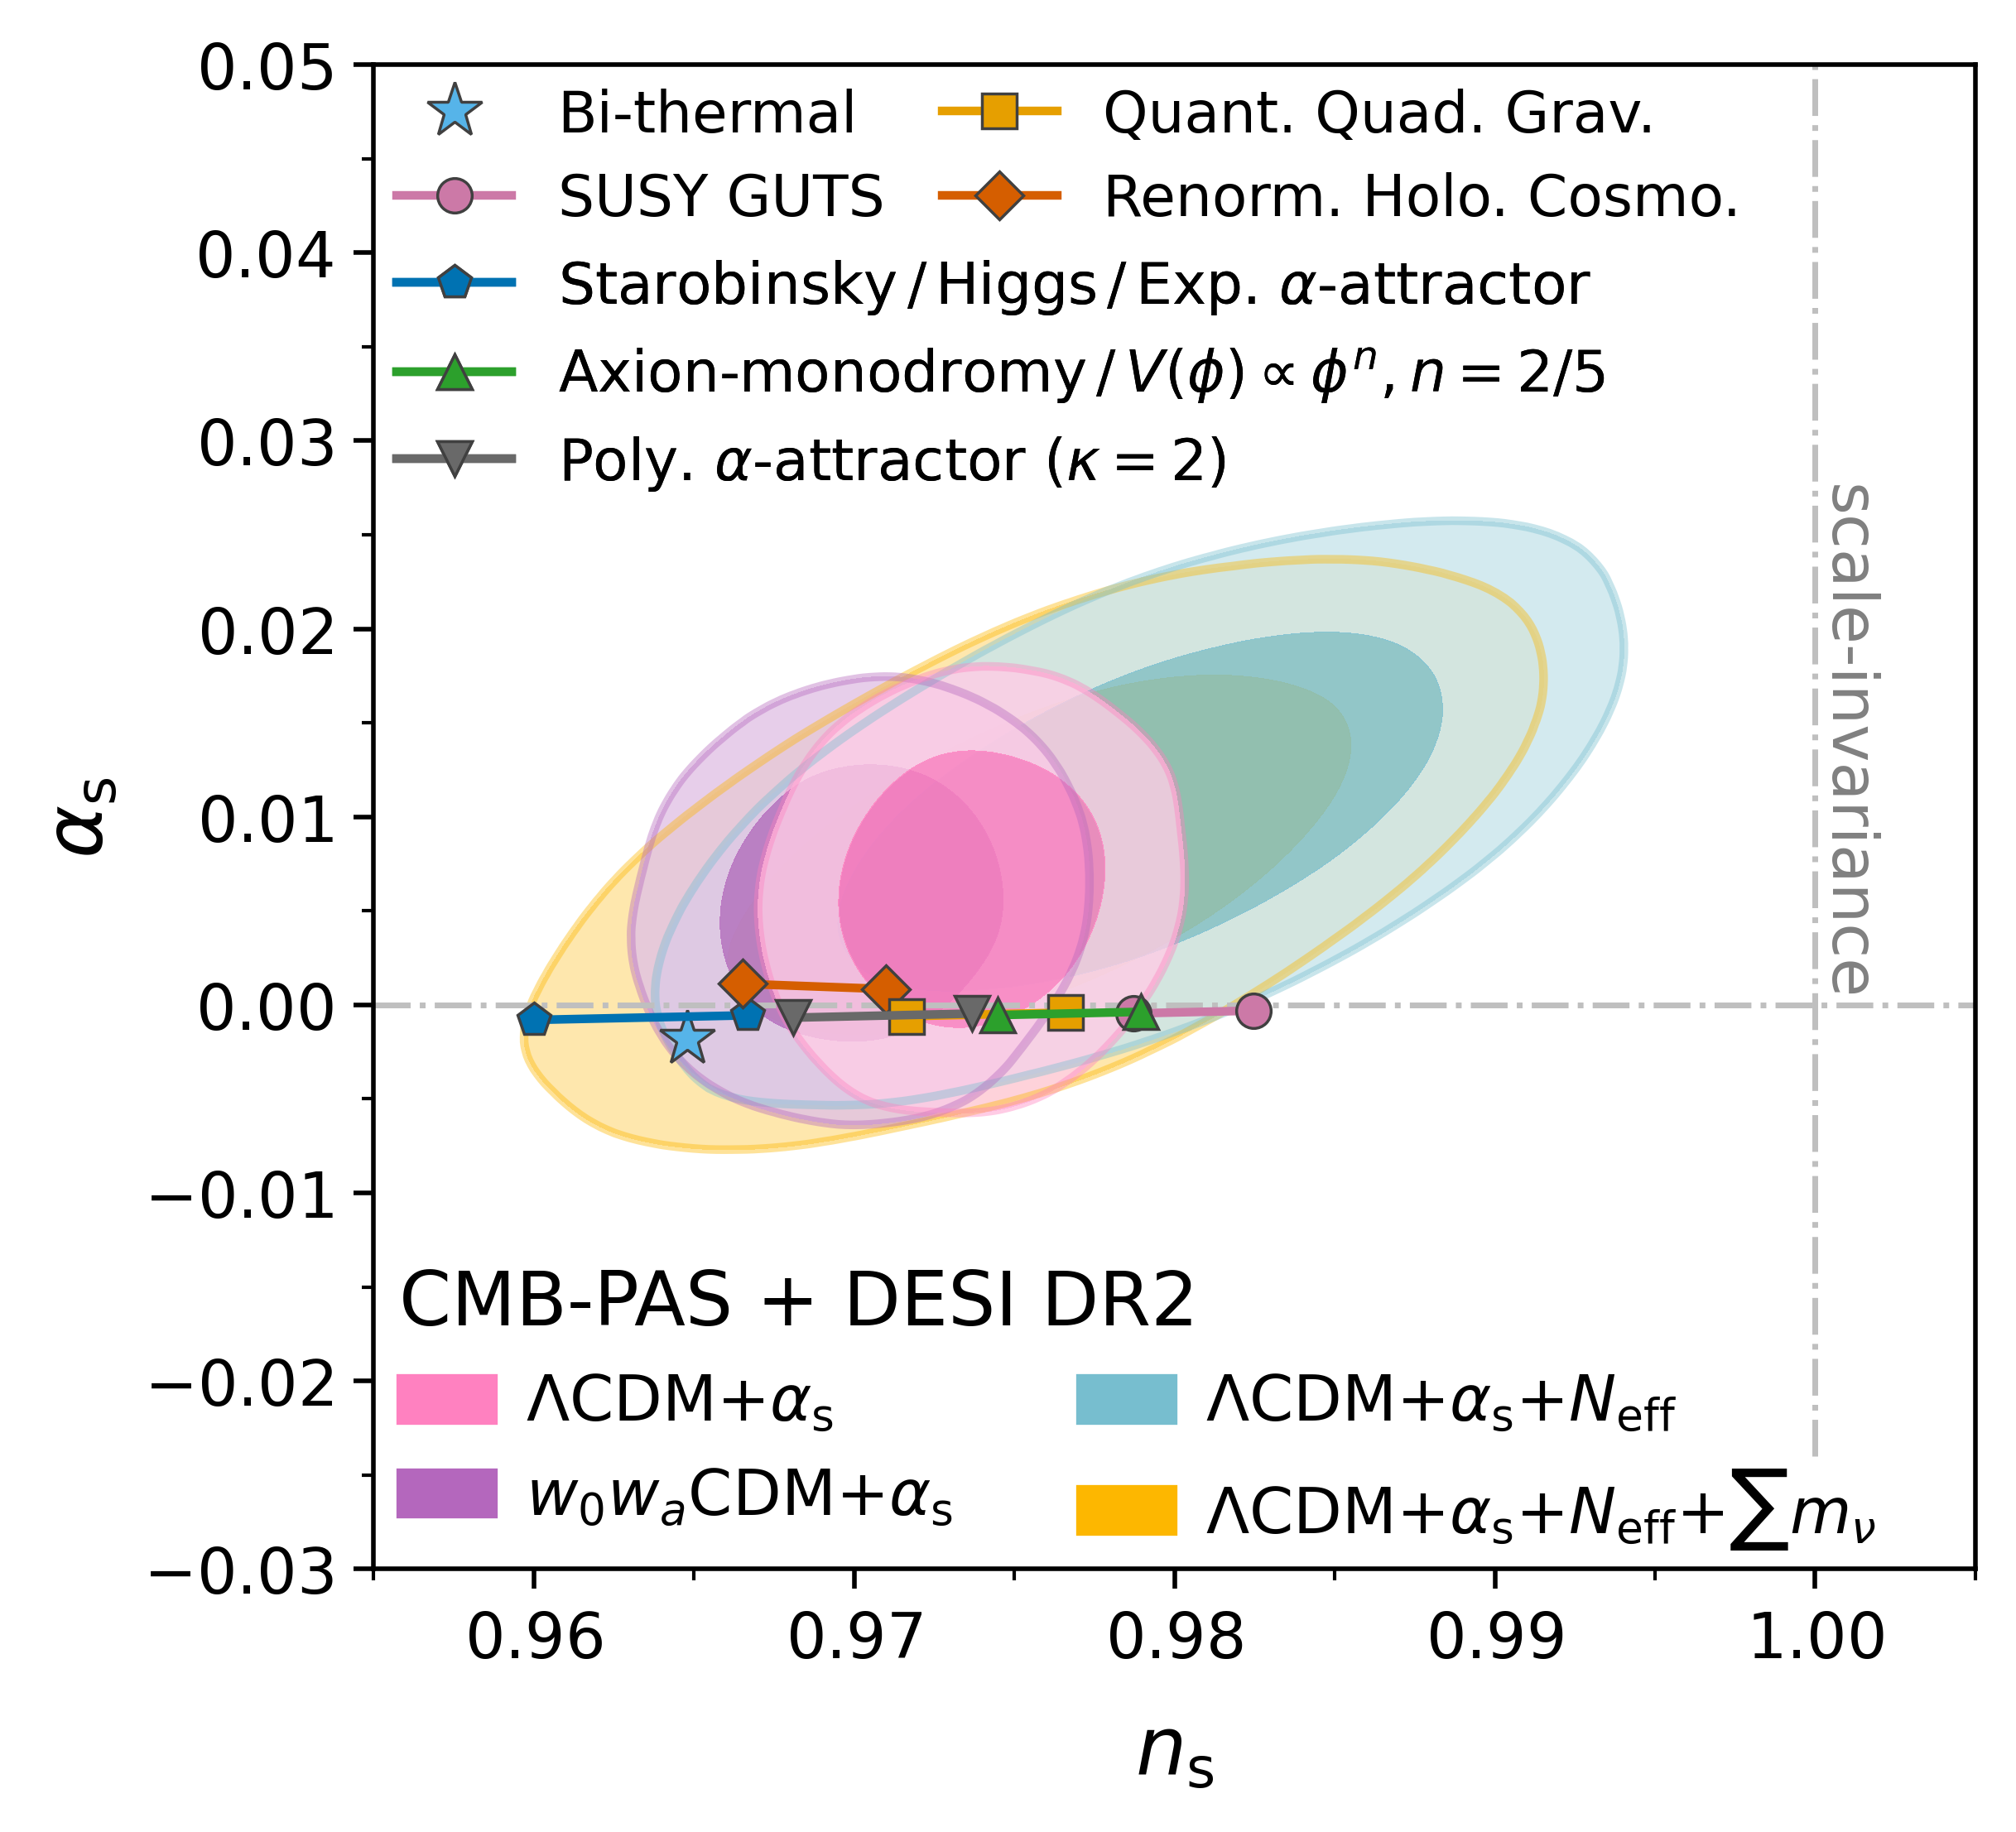

In [10]:
gd_fig = plots.get_subplot_plotter(subplot_size=5, subplot_size_ratio=0.9)

# plot the data in reverse order (largest contour first):
plt_samples = [samples['pas'][param_model] for param_model in fig1_param_models[::-1]]
colors = [fig1_kwargs[param_model]['color'] for param_model in fig1_param_models[::-1]]
lws = [contour_lw] * len(plt_samples)
gd_fig.plot_2d(plt_samples, ['ns', 'nrun'], colors=colors, filled=True,
               lws=lws, contour_args={'alpha': contour_alpha})

ax = gd_fig.subplots[0, 0]

# add a legend for the data contours:
data_handles = [mpatches.Patch(**fig1_kwargs[param_model])
                for param_model in fig1_param_models]
legend = ax.legend(handles=data_handles, fontsize=11, title=data_label,
                   title_fontsize=13, alignment='left', ncol=2,
                   bbox_to_anchor=(0, -0.005), loc='lower left',
                   handlelength=1.5, handletextpad=0.5, **flat_legend)
ax.add_artist(legend)

# plot the inflation models, keeping handles keyed by model name:
model_handles = {}
for imodel in plt_inflation_models:
    model_handle, = ax.plot(inflation_models[imodel]['ns'],
                            inflation_models[imodel]['nrun'],
                            markeredgecolor='0.25', markeredgewidth=0.5,
                            **inflation_models[imodel]['kwargs'])
    model_handles[imodel] = model_handle

# two legend groups for the models, stacked top to bottom:
top_handles = [model_handles['bithermal'], model_handles['sbs'],
               model_handles['qqg'], model_handles['rhc']]      # 2 columns
mid_handles = [model_handles['starobinsky'], model_handles['mono'],
               model_handles['poly']]                           # 1 column

legend_top = ax.legend(handles=top_handles, fontsize=10, columnspacing=1,
                       bbox_to_anchor=(0, 1), loc='upper left', ncol=2,
                       **flat_legend)
ax.add_artist(legend_top)
legend_mid = legend_below(ax, legend_top, mid_handles, ncol=1, **flat_legend)

# line for zero running (nrun = 0):
ax.axhline(**param_line_kwargs)
# line for scale-invariance (ns = 1); the range in y is set explicitly so the
# line does not run through the legend labels:
ax.vlines(1.0, -0.024, 0.05, **param_line_kwargs)
ax.text(1.000, 0.001, 'scale-invariance', fontsize=11, rotation=270,
        rotation_mode='default', color='0.5',
        verticalalignment='baseline', horizontalalignment='left')

ax.set_xlim(0.955, 1.005)
ax.set_ylim(-0.030, 0.05)
ax.xaxis.set_major_locator(MultipleLocator(0.01))
ax.xaxis.set_minor_locator(MultipleLocator(0.005))
ax.yaxis.set_major_locator(MultipleLocator(0.01))
ax.yaxis.set_minor_locator(MultipleLocator(0.005))

save_figure('fig1')
plt.show()

## Current-constraints table

The current-constraints table of the paper. All five columns are computed
directly from getdist MCMC chains: the P-ACT-LB ($\Lambda$CDM+$\alpha_s$)
column is loaded here from its own (thinned) chain, and the four
CMB-PAS + DESI DR2 columns come from the chains loaded above.

Errors are getdist's marginalized standard deviation (`par.err`), used here
as the 1-sigma. Swap `mean_pm` to use (upper - lower)/2 from `par.limits`.
The neutrino mass row is the 95% upper limit.

In [11]:
# load the (thinned) P-ACT-LB (LCDM + alpha_s) chain for the comparison column
pact_lb_nrun_samples = load_chain('pact_lb_nrun')
if pact_lb_nrun_samples.paramNames.parWithName('nrun') is not None:
    pact_lb_nrun_samples.paramNames.parWithName('nrun').label = r'\alpha_\mathrm{s}'
print(f"{'p-act-lb (lcdm_nrun)':24s} : R-1 = "
      f"{chain_convergence.get('pact_lb_nrun', float('nan')):7.4f} (full chain)")

# columns in table order: P-ACT-LB first, then the four CMB-PAS + DESI columns
table_columns = [('pact_lb', pact_lb_nrun_samples)]
table_columns += [(m, samples['pas'][m]) for m in chain_models]
table_column_labels = {
    'pact_lb': 'P-ACT-LB (LCDM + alpha_s)',
    'lcdm_nrun': 'CMB-PAS + DESI (LCDM + alpha_s)',
    'w0wacdm_nrun': 'CMB-PAS + DESI (w0waCDM + alpha_s)',
    'lcdm_nrun_nnu': 'CMB-PAS + DESI (LCDM + alpha_s + N_eff)',
    'lcdm_nrun_nnu_mnu': 'CMB-PAS + DESI (LCDM + alpha_s + N_eff + sum m_nu)',
}

# make sure the 100*theta_MC derived parameter exists in every chain
for _, chain in table_columns:
    if chain.paramNames.parWithName('theta') is None:
        cosmomc_theta = chain.getParams().cosmomc_theta
        chain.addDerived(100 * cosmomc_theta, 'theta', label=r'100\theta_\mathrm{MC}')

# cache marge stats per column
column_stats = {key: chain.getMargeStats() for key, chain in table_columns}
column_keys = [key for key, _ in table_columns]


def first_present(stats, candidates):
    """First candidate parameter name present (and varying) in `stats`,
    else None."""
    for c in candidates:
        par = stats.parWithName(c)
        if par is not None and par.err != 0:
            return c
    return None


def mean_pm(stats, candidates, dec):
    """'mean ± err' to `dec` decimals, or '---' if the parameter is absent
    or fixed."""
    name = first_present(stats, candidates)
    if name is None:
        return '---'
    par = stats.parWithName(name)
    return f'{par.mean:.{dec}f} ± {par.err:.{dec}f}'


def upper_limit(stats, candidates, dec, level=0.95):
    """'< x' upper limit at `level` to `dec` decimals, or '---' if absent."""
    name = first_present(stats, candidates)
    if name is None:
        return '---'
    par = stats.parWithName(name)
    # par.limits is aligned with stats.limits (the requested contour levels)
    i = min(range(len(stats.limits)), key=lambda k: abs(stats.limits[k] - level))
    return f'< {par.limits[i].upper:.{dec}f}'


# per-row spec: (chain-name candidates, row label, decimals, kind), where
# 'pm' -> mean ± err ; 'upper' -> 95% upper limit
TABLE_ROWS = [
    (('ombh2', 'omegabh2'),     'ombh2',                 5, 'pm'),
    (('omch2', 'omegach2'),     'omch2',                 4, 'pm'),
    (('theta', 'theta_MC_100'), '100 theta_MC',          5, 'pm'),
    (('tau', 'tau_reio'),       'tau',                   4, 'pm'),
    (('logA',),                 'logA',                  3, 'pm'),
    (('ns',),                   'ns',                    4, 'pm'),
    (('nrun',),                 'nrun',                  4, 'pm'),
    (('w', 'w0'),               'w0',                    3, 'pm'),
    (('wa',),                   'wa',                    2, 'pm'),
    (('nnu', 'N_eff'),          'nnu',                   2, 'pm'),
    (('mnu',),                  'mnu [eV] (95% upper)',  3, 'upper'),
    (('H0',),                   'H0',                    2, 'pm'),
    (('sigma8',),               'sigma8',                4, 'pm'),
]

table_list = []
for key in column_keys:
    column = {}
    for candidates, row_label, dec, kind in TABLE_ROWS:
        fmt = upper_limit if kind == 'upper' else mean_pm
        column[row_label] = fmt(column_stats[key], candidates, dec)
    table_list.append(column)
print_table(table_list, [table_column_labels[key] for key in column_keys],
            title='Current constraints: mean ± 1-sigma from the chains',
            list_of_keys=[row[1] for row in TABLE_ROWS])

/gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdInitPk_upload_latest/hdinitpk/data/chains/P-ACT-LB/pact_lb_nrun.txt
Removed no burn in
p-act-lb (lcdm_nrun)     : R-1 =  0.0045 (full chain)

 Current constraints: mean ± 1-sigma from the chains


,P-ACT-LB (LCDM + alpha_s),CMB-PAS + DESI (LCDM + alpha_s),CMB-PAS + DESI (w0waCDM + alpha_s),CMB-PAS + DESI (LCDM + alpha_s + N_eff),CMB-PAS + DESI (LCDM + alpha_s + N_eff + sum m_nu)
ombh2,0.02249 ± 0.00012,0.02240 ± 0.00010,0.02236 ± 0.00010,0.02248 ± 0.00013,0.02244 ± 0.00013
omch2,0.1179 ± 0.0009,0.1181 ± 0.0006,0.1196 ± 0.0007,0.1203 ± 0.0023,0.1194 ± 0.0023
100 theta_MC,1.04087 ± 0.00025,1.04090 ± 0.00023,1.04073 ± 0.00023,1.04072 ± 0.00029,1.04080 ± 0.00030
tau,0.0611 ± 0.0062,0.0611 ± 0.0051,0.0537 ± 0.0054,0.0601 ± 0.0052,0.0585 ± 0.0052
logA,3.055 ± 0.012,3.053 ± 0.010,3.040 ± 0.010,3.055 ± 0.010,3.050 ± 0.010
ns,0.9741 ± 0.0033,0.9737 ± 0.0027,0.9702 ± 0.0029,0.9790 ± 0.0062,0.9758 ± 0.0064
nrun,0.0062 ± 0.0053,0.0062 ± 0.0049,0.0054 ± 0.0049,0.0102 ± 0.0063,0.0080 ± 0.0064
w0,---,---,-0.433 ± 0.202,---,---
wa,---,---,-1.69 ± 0.56,---,---
nnu,---,---,---,3.18 ± 0.14,3.11 ± 0.14


## Binned-P(k) chain statistics

Marginalized statistics of the binned-$\mathcal{P}(k)$ parameters of the
current-data chains: the three 7-bin chains (P-ACT-LB, CMB-PAS, and
CMB-PAS + DESI) and the four 30-bin chains (the same three plus the
official P-ACT-LB binned-$\mathcal{P}(k)$ chain). These were computed
from the full chains and are used by Figures 3, 10, and 11 and the
binned-P(k) table in Part 2.

In [12]:
stats_7bin = load_saved_results('binned_pk_stats_7bin')

# Statistics of the sampled e^{-2 tau} P(k) parameters:
p_act_means = stats_7bin['p_act_means']
p_act_lower_errs = stats_7bin['p_act_lower_errs']
p_act_upper_errs = stats_7bin['p_act_upper_errs']
p_act_tot_err = stats_7bin['p_act_tot_err']

pas_desi_means = stats_7bin['pas_desi_means']
pas_desi_lower_errs = stats_7bin['pas_desi_lower_errs']
pas_desi_upper_errs = stats_7bin['pas_desi_upper_errs']
pas_desi_tot_err = stats_7bin['pas_desi_tot_err']

pas_means = stats_7bin['pas_means']
pas_lower_errs = stats_7bin['pas_lower_errs']
pas_upper_errs = stats_7bin['pas_upper_errs']
pas_tot_err = stats_7bin['pas_tot_err']

p_act_asymmetric_errors = [p_act_lower_errs, p_act_upper_errs]
pas_desi_asymmetric_errors = [pas_desi_lower_errs, pas_desi_upper_errs]
pas_asymmetric_errors = [pas_lower_errs, pas_upper_errs]

# Statistics of the derived raw P(k), kept for reference:
p_act_pk_means = stats_7bin['p_act_pk_means']
p_act_pk_lower_errs = stats_7bin['p_act_pk_lower_errs']
p_act_pk_upper_errs = stats_7bin['p_act_pk_upper_errs']
p_act_pk_tot_err = stats_7bin['p_act_pk_tot_err']

pas_desi_pk_means = stats_7bin['pas_desi_pk_means']
pas_desi_pk_lower_errs = stats_7bin['pas_desi_pk_lower_errs']
pas_desi_pk_upper_errs = stats_7bin['pas_desi_pk_upper_errs']
pas_desi_pk_tot_err = stats_7bin['pas_desi_pk_tot_err']

pas_pk_means = stats_7bin['pas_pk_means']
pas_pk_lower_errs = stats_7bin['pas_pk_lower_errs']
pas_pk_upper_errs = stats_7bin['pas_pk_upper_errs']
pas_pk_tot_err = stats_7bin['pas_pk_tot_err']


loaded 'binned_pk_stats_7bin' from /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdInitPk_upload_latest/hdinitpk/data/cached_results/binned_pk_stats_7bin.txt


In [13]:
stats_30bin = load_saved_results('binned_pk_stats_30bin')

p_act_means_30bin = stats_30bin['p_act_means']
p_act_lower_errs_30bin = stats_30bin['p_act_lower_errs']
p_act_upper_errs_30bin = stats_30bin['p_act_upper_errs']

pas_desi_means_30bin = stats_30bin['pas_desi_means']
pas_desi_lower_errs_30bin = stats_30bin['pas_desi_lower_errs']
pas_desi_upper_errs_30bin = stats_30bin['pas_desi_upper_errs']

pas_means_30bin = stats_30bin['pas_means']
pas_lower_errs_30bin = stats_30bin['pas_lower_errs']
pas_upper_errs_30bin = stats_30bin['pas_upper_errs']

official_means = stats_30bin['official_means']
official_lower_errs = stats_30bin['official_lower_errs']
official_upper_errs = stats_30bin['official_upper_errs']

p_act_asymmetric_errors_30bin = [p_act_lower_errs_30bin, p_act_upper_errs_30bin]
pas_desi_asymmetric_errors_30bin = [pas_desi_lower_errs_30bin, pas_desi_upper_errs_30bin]
pas_asymmetric_errors_30bin = [pas_lower_errs_30bin, pas_upper_errs_30bin]
official_asymmetric_errors = [official_lower_errs, official_upper_errs]


loaded 'binned_pk_stats_30bin' from /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdInitPk_upload_latest/hdinitpk/data/cached_results/binned_pk_stats_30bin.txt


# Part 2: Forecasted results

The remaining figures and tables. The Fisher matrices were computed on a
cluster and saved with `save_fisher_matrix`; each saved matrix already
includes the tau prior (and, where applicable, the `HMCode_logT_AGN`
prior and the DESI BAO Fisher) exactly as applied in the paper, so the
error tables below follow from a simple matrix inversion
(`fisher.get_fisher_errors`). The binned-$\mathcal{P}(k)$ Fisher matrices were
produced with `hdinitpk`; the rest with `hdfisher`.

## Fisher matrices and errors

The 9-parameter CMB-HD (CAMB and CLASS) and SO-like (CLASS) Fisher
matrices. Matrices built with CLASS are saved with native CLASS parameter
names and translated to CAMB names here.

In [14]:
# CMB-HD Fisher matrices computed with CAMB (9 parameters), lensed and
# delensed:
camb_fisher_matrix_with_desi = load_saved_fisher('hd_camb_lensed_9param')
errs_with_desi_camb = fisher.get_fisher_errors(*camb_fisher_matrix_with_desi)

delensed_camb_fisher_matrix_with_desi = load_saved_fisher('hd_camb_delensed_9param')
delensed_errs_with_desi_camb = fisher.get_fisher_errors(
    *delensed_camb_fisher_matrix_with_desi)

# CMB-HD Fisher matrix computed with CLASS (9 parameters).
# Translate CLASS to CAMB parameter names.
class_fisher_matrix_with_desi = from_class_fisher(
    load_saved_fisher('hd_class_lensed_9param'))
errs_with_desi_class = fisher.get_fisher_errors(*class_fisher_matrix_with_desi)

# SO-like Fisher matrix (9 parameters), computed with CLASS. Saved with
# native CLASS parameter names, so translate them the same way:
so_fisher_matrix_with_desi = from_class_fisher(
    load_saved_fisher('so_class_lensed_9param'))


In [15]:
# Compare the CAMB and CLASS forecasted error bars.
table_list = [errs_with_desi_camb, errs_with_desi_class,
              ratio(errs_with_desi_camb, errs_with_desi_class)]
label_list = ['CAMB + DESI forecast', 'CLASS + DESI forecast',
              'Ratio (CAMB/CLASS)']
print_table(table_list, label_list, list_of_keys=nine_params)

,CAMB + DESI forecast,CLASS + DESI forecast,Ratio (CAMB/CLASS)
mnu,0.028232,0.027559,1.024414
tau,0.004538,0.004502,1.007980
logA,0.008473,0.008408,1.007725
H0,0.317110,0.314379,1.008687
ombh2,0.000026,0.000026,1.000845
omch2,0.000389,0.000392,0.993567
ns,0.001932,0.001934,0.999151
nnu,0.015340,0.015380,0.997430
nrun,0.001288,0.001257,1.023996


## Fisher matrices including baryonic feedback

The 12-parameter Fisher matrix additionally varies the baryonic feedback
strength `HMCode_logT_AGN` and the kSZ power spectrum amplitude and slope
(`A_ksz`, `n_ksz`).

In [16]:
# The 12-parameter (feedback + kSZ) CMB-HD Fisher matrix, and the
# 9-parameter matrix formed from the same derivatives:
camb_fisher_matrix_with_desi_feedback = load_saved_fisher(
    'hd_camb_delensed_12param_feedback')
errs_with_desi_camb_feedback = fisher.get_fisher_errors(
    *camb_fisher_matrix_with_desi_feedback)

errs_with_desi_camb_no_feedback = fisher.get_fisher_errors(
    *load_saved_fisher('hd_camb_delensed_9param_from_feedback'))


In [17]:
# Compare the 12-parameter (with feedback) and 9-parameter error bars.
table_list = [errs_with_desi_camb_feedback, delensed_errs_with_desi_camb,
              ratio(errs_with_desi_camb_feedback, delensed_errs_with_desi_camb)]
label_list = ['CAMB + DESI forecast (12 param)', 'CAMB + DESI forecast (9 param)',
              'Ratio (12-param/9-param)']
print_table(table_list, label_list, list_of_keys=feedback_params)

,CAMB + DESI forecast (12 param),CAMB + DESI forecast (9 param),Ratio (12-param/9-param)
mnu,0.029029,0.028237,1.028032
tau,0.004537,0.004474,1.014167
logA,0.008551,0.008397,1.018345
H0,0.303617,0.315197,0.963262
ombh2,0.000026,0.000026,1.003480
omch2,0.000378,0.000366,1.031816
ns,0.001835,0.001809,1.014223
nnu,0.016262,0.014311,1.136328
nrun,0.001638,0.001240,1.321120
HMCode_logT_AGN,0.004672,NaN,NaN


In [18]:
# The 9- and 12-parameter errors as they appear in the paper's table:
# rounded to the significant figures used there, with the parameters that
# the 9-parameter forecast does not vary marked '---', and their ratio.
missing_str = '---'

# row order (kSZ + feedback parameters last)
feedback_row_order = ['ombh2', 'omch2', 'H0', 'tau', 'logA', 'ns', 'nrun',
                      'nnu', 'mnu', 'A_ksz', 'n_ksz', 'HMCode_logT_AGN']


def get_finite(d, p):
    """Return d[p] if present and finite, else None (treated as missing)."""
    if p not in d:
        return None
    v = d[p]
    if v is None:
        return None
    if isinstance(v, float) and math.isnan(v):
        return None
    return v


def feedback_table(col2_dict, col3_dict, order=feedback_row_order,
                   sig_figs=err_sig_figs, rdec=ratio_decimals,
                   miss=missing_str):
    """Three columns for `print_table`, as formatted strings: the
    9-parameter errors (`col2_dict`), the 12-parameter errors
    (`col3_dict`), and their ratio (12 / 9)."""
    no_feedback, feedback, ratios = {}, {}, {}
    for p in order:
        n = sig_figs[p]
        v2 = get_finite(col2_dict, p)
        v3 = get_finite(col3_dict, p)
        no_feedback[p] = sigfig(v2, n) if v2 is not None else miss
        feedback[p] = sigfig(v3, n) if v3 is not None else miss
        if (v2 is not None) and (v3 is not None):
            ratios[p] = f'{v3 / v2:.{rdec}f}'
        else:
            ratios[p] = miss
    return [no_feedback, feedback, ratios]


print_table(feedback_table(delensed_errs_with_desi_camb, errs_with_desi_camb_feedback),
            ['9 param', '12 param (feedback + kSZ)', 'Ratio (12 / 9)'],
            title='CMB-HD + DESI, delensed, CAMB: 1-sigma errors as in the paper',
            list_of_keys=feedback_row_order)


 CMB-HD + DESI, delensed, CAMB: 1-sigma errors as in the paper


,9 param,12 param (feedback + kSZ),Ratio (12 / 9)
ombh2,0.000026,0.000026,1.003
omch2,0.000366,0.000378,1.032
H0,0.315,0.304,0.963
tau,0.00447,0.00454,1.014
logA,0.00840,0.00855,1.018
ns,0.00181,0.00183,1.014
nrun,0.00124,0.00164,1.321
nnu,0.0143,0.0163,1.136
mnu,0.0282,0.0290,1.028
A_ksz,---,0.00140,---


## Fisher errors for the extended cosmological models

Forecasted 1-sigma errors for SO-like and CMB-HD-like surveys (each combined
with DESI BAO) in the four extended models considered in the paper:
$\Lambda$CDM+$\alpha_s$, $w_0 w_a$CDM+$\alpha_s$,
$\Lambda$CDM+$\alpha_s$+$N_\mathrm{eff}$, and
$\Lambda$CDM+$\alpha_s$+$N_\mathrm{eff}$+$\sum m_\nu$.
The table below is the forecast table in the paper.

In [19]:
# w0waCDM + alpha_s: CMB-HD and SO-like Fisher errors, both lensed and
# both computed with CAMB. The binned-P(k) and w0wa configurations stay
# on CAMB, so these two need no parameter-name translation.
w0wa_model_params = ['ombh2', 'omch2', 'H0', 'tau', 'logA', 'ns', 'nrun', 'w', 'wa']

hd_errs_w0_wa = fisher.get_fisher_errors(*load_saved_fisher('hd_w0wa_lensed'))
so_errs_w0_wa = fisher.get_fisher_errors(*load_saved_fisher('so_w0wa_lensed'))

# LCDM + alpha_s (+ N_eff (+ sum m_nu)): CMB-HD and SO-like Fisher errors,
# both lensed and both computed with CLASS. Each is built from the same
# derivatives as the corresponding 9-parameter CLASS Fisher above, so the
# saved files keep native CLASS parameter names and their error dictionaries
# are translated here:
hd_errs_lcdm_nrun = from_class_errors(fisher.get_fisher_errors(
    *load_saved_fisher('hd_ext_lensed_lcdm_nrun')))
hd_errs_lcdm_nrun_neff = from_class_errors(fisher.get_fisher_errors(
    *load_saved_fisher('hd_ext_lensed_lcdm_nrun_neff')))
hd_errs_lcdm_nrun_neff_mnu = from_class_errors(fisher.get_fisher_errors(
    *load_saved_fisher('hd_ext_lensed_lcdm_nrun_neff_mnu')))

so_errs_lcdm_nrun = from_class_errors(fisher.get_fisher_errors(
    *load_saved_fisher('so_ext_lensed_lcdm_nrun')))
so_errs_lcdm_nrun_neff = from_class_errors(fisher.get_fisher_errors(
    *load_saved_fisher('so_ext_lensed_lcdm_nrun_neff')))
so_errs_lcdm_nrun_neff_mnu = from_class_errors(fisher.get_fisher_errors(
    *load_saved_fisher('so_ext_lensed_lcdm_nrun_neff_mnu')))


In [20]:
# The extended-models forecast table: for each parameter, an SO-like and a
# CMB-HD column per model, rounded to the significant figures used in the
# paper. Parameters not varied in a given model get '---'.
ext_table_params = ['ombh2', 'omch2', 'H0', 'tau', 'logA', 'ns', 'nrun',
                    'w', 'wa', 'nnu', 'mnu']

# significant figures for this table (mostly 2; w gets 3)
ext_table_sig_figs = {
    'ombh2': 2, 'omch2': 2, 'H0': 2, 'tau': 2, 'logA': 2,
    'ns': 2, 'nrun': 2, 'w': 3, 'wa': 2, 'nnu': 2, 'mnu': 2,
}

ext_models = ['lcdm_nrun', 'w0wa_cdm', 'lcdm_nrun_neff', 'lcdm_nrun_neff_mnu']
ext_model_labels = {
    'lcdm_nrun':          'LCDM + alpha_s',
    'w0wa_cdm':           'w0waCDM + alpha_s',
    'lcdm_nrun_neff':     'LCDM + alpha_s + N_eff',
    'lcdm_nrun_neff_mnu': 'LCDM + alpha_s + N_eff + sum m_nu',
}

ext_model_params = {
    'lcdm_nrun':          ['ombh2', 'omch2', 'H0', 'tau', 'logA', 'ns', 'nrun'],
    'w0wa_cdm':           w0wa_model_params,
    'lcdm_nrun_neff':     ['ombh2', 'omch2', 'H0', 'tau', 'logA', 'ns', 'nrun', 'nnu'],
    'lcdm_nrun_neff_mnu': ['ombh2', 'omch2', 'H0', 'tau', 'logA', 'ns', 'nrun', 'nnu', 'mnu'],
}

so_error_dicts = {
    'lcdm_nrun':          so_errs_lcdm_nrun,
    'w0wa_cdm':           so_errs_w0_wa,
    'lcdm_nrun_neff':     so_errs_lcdm_nrun_neff,
    'lcdm_nrun_neff_mnu': so_errs_lcdm_nrun_neff_mnu,
}
hd_error_dicts = {
    'lcdm_nrun':          hd_errs_lcdm_nrun,
    'w0wa_cdm':           hd_errs_w0_wa,
    'lcdm_nrun_neff':     hd_errs_lcdm_nrun_neff,
    'lcdm_nrun_neff_mnu': hd_errs_lcdm_nrun_neff_mnu,
}


def ext_table_column(error_dicts, model_name):
    """One column for `print_table`: the formatted error of each parameter
    in `model_name`, or '---' if the parameter is not varied in that model."""
    return {p: (sigfig(error_dicts[model_name][p], ext_table_sig_figs[p])
                if p in ext_model_params[model_name] else '---')
            for p in ext_table_params}


ext_table_list, ext_table_labels = [], []
for m in ext_models:
    for exp_name, error_dicts in [('SO-like', so_error_dicts), ('CMB-HD', hd_error_dicts)]:
        ext_table_list.append(ext_table_column(error_dicts, m))
        ext_table_labels.append(f'{exp_name}, {ext_model_labels[m]}')

print_table(ext_table_list, ext_table_labels,
            title='Forecasted 1-sigma errors (with DESI BAO) in the extended models',
            list_of_keys=ext_table_params)


 Forecasted 1-sigma errors (with DESI BAO) in the extended models


,"SO-like, LCDM + alpha_s","CMB-HD, LCDM + alpha_s","SO-like, w0waCDM + alpha_s","CMB-HD, w0waCDM + alpha_s","SO-like, LCDM + alpha_s + N_eff","CMB-HD, LCDM + alpha_s + N_eff","SO-like, LCDM + alpha_s + N_eff + sum m_nu","CMB-HD, LCDM + alpha_s + N_eff + sum m_nu"
ombh2,0.000036,0.000016,0.000036,0.000018,0.000047,0.000026,0.000048,0.000026
omch2,0.00037,0.00035,0.00039,0.00036,0.00082,0.00039,0.00087,0.00039
H0,0.14,0.13,1.6,1.2,0.38,0.18,0.41,0.31
tau,0.0034,0.0033,0.0043,0.0042,0.0035,0.0033,0.0046,0.0045
logA,0.0060,0.0058,0.0078,0.0075,0.0060,0.0058,0.0089,0.0084
ns,0.0018,0.0017,0.0019,0.0017,0.0028,0.0019,0.0030,0.0019
nrun,0.0026,0.0011,0.0026,0.0015,0.0038,0.0012,0.0040,0.0013
w,---,---,0.133,0.107,---,---,---,---
wa,---,---,0.31,0.26,---,---,---,---
nnu,---,---,---,---,0.052,0.015,0.056,0.015


# Setup for Figures 2 and 4

Figures 2 and 4 compare the current CMB-PAS + DESI DR2 constraints (MCMC)
with the SO-like and CMB-HD forecasts (Fisher), all in the 9-parameter
$\Lambda$CDM+$\alpha_s$+$N_\mathrm{eff}$+$\sum m_\nu$ model.

In [21]:
# `exp_labels` (one label per data combination) and `exp_colors` are
# imported from `hdinitpk.plotting_utilities`.
# Fisher forecast contours, centered on the marginalized MCMC means:
samples['so'] = {}
samples['hd'] = {}
samples['so']['lcdm_nrun_nnu_mnu'] = getdist_samples(
    so_fisher_matrix_with_desi[0], so_fisher_matrix_with_desi[1], mcmc_fid_params)
samples['hd']['lcdm_nrun_nnu_mnu'] = getdist_samples(
    class_fisher_matrix_with_desi[0], class_fisher_matrix_with_desi[1], mcmc_fid_params)

In [22]:
# 2d parameter contours for Figure 2:
fig2_data_keys = ['pas', 'so', 'hd']
fig2_param_models = ['lcdm_nrun_nnu_mnu']

fig2_colors = {'pas': {'lcdm_nrun': darkyellow,
                       'w0wacdm_nrun': darkyellow,
                       'lcdm_nrun_nnu_mnu': exp_colors['pas']},
               'so': {'lcdm_nrun': 'g',
                      'w0wacdm_nrun': brightblue,
                      'lcdm_nrun_nnu_mnu': exp_colors['so']},
               'hd': {'lcdm_nrun': 'r',
                      'w0wacdm_nrun': magenta,
                      'lcdm_nrun_nnu_mnu': exp_colors['hd']}}

fig2_filled = {'lcdm_nrun_nnu_mnu': True, 'w0wacdm_nrun': False, 'lcdm_nrun': False}
fig2_ls = {'lcdm_nrun_nnu_mnu': '-', 'w0wacdm_nrun': '--', 'lcdm_nrun': '--'}
fig2_lw = {'lcdm_nrun_nnu_mnu': 1, 'w0wacdm_nrun': 1.15, 'lcdm_nrun': 1.5}
fig2_alpha = {'lcdm_nrun_nnu_mnu': 1.0, 'w0wacdm_nrun': 1, 'lcdm_nrun': 1}

# Figure 2

Zoomed comparison of the ($n_\mathrm{s}$, $\alpha_\mathrm{s}$) constraints
from current data with the SO-like and CMB-HD forecasts, alongside the
inflation model predictions.

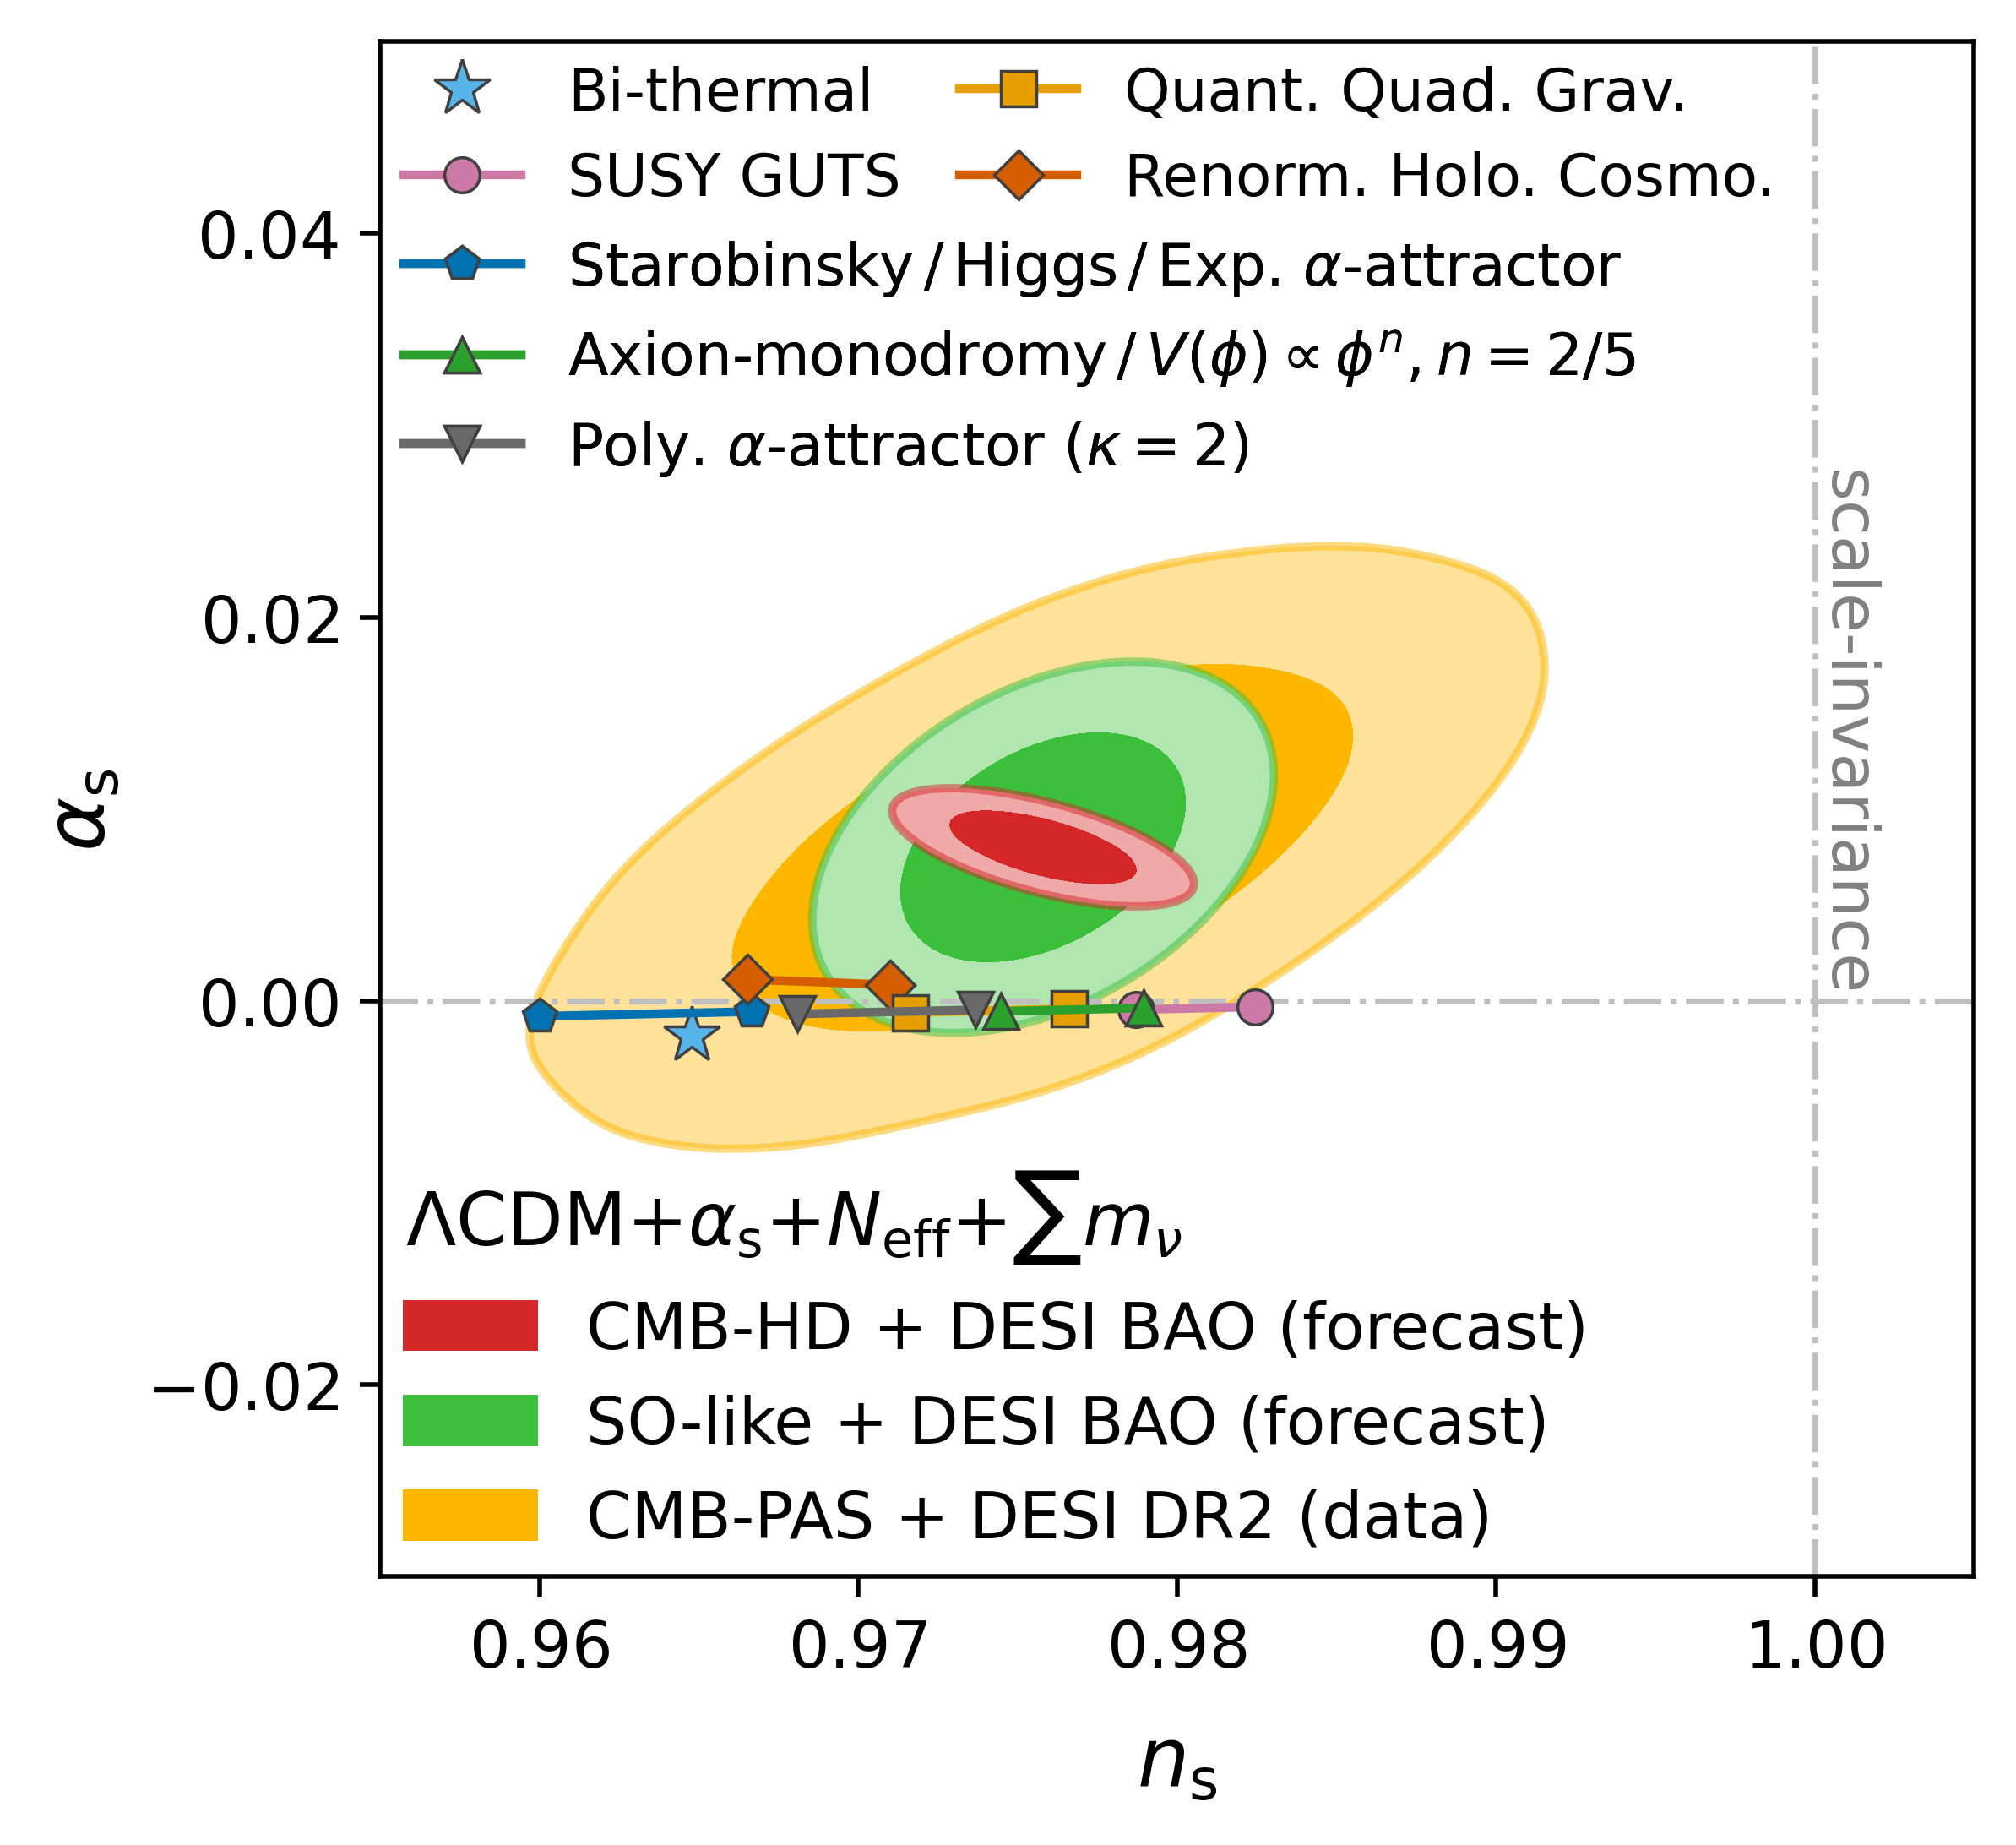

In [23]:
g_zoom = plots.get_subplot_plotter(subplot_size=5, subplot_size_ratio=0.9)

# plot the contours:
plt_samples = []
plt_colors = []
plt_lines = []
plt_lws = []
plt_filled = []
contour_args = []
for data_key in fig2_data_keys:
    for param_model in fig2_param_models:
        plt_samples.append(samples[data_key][param_model])
        plt_colors.append(fig2_colors[data_key][param_model])
        plt_lines.append(fig2_ls[param_model])
        plt_lws.append(fig2_lw[param_model])
        plt_filled.append(fig2_filled[param_model])
        contour_args.append({'alpha': fig2_alpha[param_model]})
g_zoom.plot_2d(plt_samples, ['ns', 'nrun'], filled=plt_filled,
               colors=plt_colors, ls=plt_lines, lws=plt_lws,
               contour_args=contour_args)

ax_zoom = g_zoom.subplots[0, 0]

# label the contours:
handles = [mpatches.Patch(color=exp_colors[data_key], label=exp_labels[data_key])
           for data_key in fig2_data_keys[::-1]]
legend = ax_zoom.legend(handles=handles, fontsize=11,
                        title=model_labels[fig2_param_models[0]],
                        title_fontsize=12.5, alignment='left',
                        loc='lower left', bbox_to_anchor=(0, 0), **flat_legend)
g_zoom.fig.add_artist(legend)

# lines for zero running (nrun = 0) and scale-invariance (ns = 1):
ax_zoom.axhline(**param_line_kwargs)
ax_zoom.axvline(x=1, **param_line_kwargs)
ax_zoom.text(1.000, 0.001, 'scale-invariance', fontsize=11, rotation=270,
             rotation_mode='default', color='0.5',
             verticalalignment='baseline', horizontalalignment='left')

# inflation models:
model_handles = {}
for imodel in plt_inflation_models:
    model_handle, = ax_zoom.plot(inflation_models[imodel]['ns'],
                                 inflation_models[imodel]['nrun'],
                                 markeredgecolor='0.25', markeredgewidth=0.5,
                                 **inflation_models[imodel]['kwargs'])
    model_handles[imodel] = model_handle

# two legend groups for the models, stacked top to bottom:
top_handles = [model_handles['bithermal'], model_handles['sbs'],
               model_handles['qqg'], model_handles['rhc']]      # 2 columns
mid_handles = [model_handles['starobinsky'], model_handles['mono'],
               model_handles['poly']]                           # 1 column

legend_top = ax_zoom.legend(handles=top_handles, fontsize=10, columnspacing=1,
                            bbox_to_anchor=(0, 1), loc='upper left', ncol=2,
                            **flat_legend)
ax_zoom.add_artist(legend_top)
legend_mid = legend_below(ax_zoom, legend_top, mid_handles, ncol=1, **flat_legend)

ax_zoom.set_xlim(0.955, 1.005)
ax_zoom.set_ylim(-0.030, 0.05)

save_figure('fig2')
plt.show()

## Distance of the inflation models from the forecast centers

Mahalanobis distance of each inflation model's
($n_\mathrm{s}$, $\alpha_\mathrm{s}$) prediction from the forecast center,
using the marginalized 2d covariance from the Fisher matrix. This gives the
effective "number of sigma" at which each model could be distinguished.

In [24]:
def mahalanobis_distances(fisher_result, means_dict, model_dict):
    """Mahalanobis distance in the (nrun, ns) plane for each model in
    `model_dict`, given a `(fisher_matrix, param_names)` pair. The parameter
    indices are looked up by name from `param_names`."""
    fisher_matrix, param_names = fisher_result
    covmat = np.linalg.inv(fisher_matrix)
    idx = [param_names.index('nrun'), param_names.index('ns')]
    covmat_cut = covmat[np.ix_(idx, idx)]
    means = np.array([means_dict['nrun'], means_dict['ns']])

    results = {}
    for model_name, model_data in model_dict.items():
        dists = []
        for ns, nrun in zip(np.asarray(model_data['ns']),
                            np.asarray(model_data['nrun'])):
            diff = np.array([nrun, ns]) - means   # order matches `means`
            dists.append(np.sqrt(diff @ np.linalg.solve(covmat_cut, diff)))
        results[model_name] = np.array(dists)
    return results


print('CMB-HD (CLASS) Fisher, 9-parameter model:')
for k, v in mahalanobis_distances(class_fisher_matrix_with_desi,
                                  mcmc_fid_params, inflation_models).items():
    print(f'  {k}: {v}')

print('\nCMB-HD (CAMB) Fisher, 12-parameter model with feedback:')
for k, v in mahalanobis_distances(camb_fisher_matrix_with_desi_feedback,
                                  mcmc_fid_params, inflation_models).items():
    print(f'  {k}: {v}')

CMB-HD (CLASS) Fisher, 9-parameter model:
  starobinsky: [17.27152604 13.1678033 ]
  bithermal: [15.39655681]
  rhc: [11.6929      9.47877818]
  qqg: [10.56744967  8.16178028]
  sbs: [7.49796766 6.65768967]
  mono: [9.17054724 7.35248704]
  poly: [12.49980249  9.44105461]

CMB-HD (CAMB) Fisher, 12-parameter model with feedback:
  starobinsky: [13.63365095  9.85122828]
  bithermal: [11.57627763]
  rhc: [8.95380723 6.8286891 ]
  qqg: [7.47290914 5.5851166 ]
  sbs: [5.24223002 5.27629431]
  mono: [6.31096012 5.16611546]
  poly: [9.19903821 6.53875185]


# Figure 3

Current and forecasted constraints on $e^{-2\tau} \mathcal{P}(k)$ for a
binned primordial power spectrum. The current constraints (P-ACT-LB and
CMB-PAS) come from MCMC chains with 7 $k$ bins; the SO-like and CMB-HD
forecasts come from binned-$\mathcal{P}(k)$ Fisher matrices with 7 and 11
bins, respectively.

In [25]:
# SO only measures the first 7 of the 11 CMB-HD k bins.
so_max_bin = 7

# varied parameters for the binned-P(k) Fisher matrices:
params_binned_pk = [f'Pk{i+1}' for i in range(11)] + ['H0', 'tau', 'ombh2', 'omch2']
params_binned_pk_so = [f'Pk{i+1}' for i in range(so_max_bin)] + ['H0', 'tau', 'ombh2', 'omch2']

# k bin edges [Mpc^-1] for the 11-bin (+ 1 lower-edge) binning:
pk_bin_edges = [5.623413251903490700e-05, 3.667637511098258835e-03,
                8.505899211272888866e-03, 1.972668268698882926e-02,
                4.574966151931515734e-02, 1.061015459285717805e-01,
                2.460682259622835044e-01, 5.706756795889451617e-01,
                1.323497700691443235e+00, 3.069424940269466440e+00,
                7.118538595893407539e+00, 1.650914836730800417e+01,
                3.828763111167506139e+01]

In [26]:
def hd_Pk(k):
    """Fiducial power-law primordial spectrum P_R(k), with k in Mpc^-1."""
    k_0 = 0.05
    A_s = np.exp(3.044) / 1e10
    n_s = 0.9649
    return A_s * (k / k_0)**(n_s - 1)


# k bin centers and edges for the 11-bin CMB-HD binning:
binning = utils.load_from_file(
    os.path.join(binning_data_path, 'hd_pk_wavenumbers_11bins.txt'),
    ['k bin center [Mpc^-1]', 'lower bin edge [Mpc^-1]', 'upper bin edge [Mpc^-1]'])

# fiducial P(k) and 10^9 e^{-2 tau} P(k) at the bin centers:
hd_pk_eleven_bins = [hd_Pk(k) for k in binning['k bin center [Mpc^-1]']]
eneg2tau_hd_pk_eleven_bins = [1e9 * np.exp(-2 * tau) * pk for pk in hd_pk_eleven_bins]

In [27]:
# Binned-P(k) Fisher matrices for CMB-HD (11 bins) and SO-like (7 bins),
# produced with `hdinitpk`. These have the tau prior applied and no DESI,
# matching the paper.
fisher_matrix_binned_pk = load_saved_fisher('hd_binned_pk_lensed_11bins')
fisher_matrix_binned_pk_so = load_saved_fisher('so_binned_pk_lensed_7bins')


In [28]:
def get_eneg2tau_pk_errors(fisher_matrix, fisher_params, fid_params,
                           n_samples=100000, random_state=None):
    """
    Marginalized error on e^{-2 tau} * Pk_n for each Pk bin.

    The error is obtained by sampling the forecast and forming the product
    sample by sample, which keeps the tau <-> bin correlations and the
    curvature of the exponential exactly. Steps (following getdist):
      1. Represent the Fisher forecast as a multivariate Gaussian via
         GaussianND, centered on the fiducial values, with the inverse
         Fisher matrix as the parameter covariance. This carries the full
         tau <-> bin correlations.
      2. Draw samples from that distribution.
      3. For each bin, build the derived quantity e^{-2 tau} Pk_n from the
         sampled tau and Pk_n values and append it with addDerived.
      4. Read off the marginalized error bar from the resulting distribution.
    """
    params = list(fisher_params)  # list of param name strings

    # Mean vector in the same order as fisher_params.
    mean = np.array([fid_params[p] for p in params])

    # Parameter covariance = inverse Fisher matrix.
    cov = np.linalg.inv(fisher_matrix)

    # Multivariate Gaussian centered on the fiducial point.
    gauss = GaussianND(mean, cov, names=params)

    # Independent samples carrying the full correlation structure.
    gauss_samples = gauss.MCSamples(size=n_samples, names=params,
                                    random_state=random_state)

    p = gauss_samples.getParams()
    tau_samp = getattr(p, 'tau')

    errors = {}
    for n in range(0, 62):
        pk_name = f'Pk{n}'
        if pk_name not in params:
            continue

        pk_samp = getattr(p, pk_name)

        # Derived quantity for this bin, sample by sample.
        derived = np.exp(-2.0 * tau_samp) * pk_samp
        gauss_samples.addDerived(derived, name=f'eneg2tau_{pk_name}')

        # Marginalized error bar from the derived distribution.
        errors[pk_name] = np.std(derived, ddof=1)

    return errors


# Fiducial values for the binned-P(k) Fisher parameters (including the
# baryonic feedback + kSZ parameters, used for the Figure 5 Fisher matrices).
binned_pk_fids = {'ombh2': 0.02237, 'omch2': 0.1200, 'tau': 0.0544,
                  'H0': 67.36, 'HMCode_logT_AGN': 7.8, 'A_ksz': 1.0,
                  'n_ksz': 0.0}
for n, pk_val in enumerate(hd_pk_eleven_bins, start=1):
    binned_pk_fids[f'Pk{n}'] = pk_val

eneg2tau_pk_errors = get_eneg2tau_pk_errors(
    fisher_matrix_binned_pk[0], fisher_matrix_binned_pk[1], binned_pk_fids)
eneg2tau_pk_errors_so = get_eneg2tau_pk_errors(
    fisher_matrix_binned_pk_so[0], fisher_matrix_binned_pk_so[1], binned_pk_fids)

# forecasted 1-sigma errors on 10^9 e^{-2 tau} P(k) per bin:
hd_err = [1e9 * eneg2tau_pk_errors[f'Pk{i+1}'] for i in range(11)]
so_err = [1e9 * eneg2tau_pk_errors_so[f'Pk{i+1}'] for i in range(so_max_bin)]

Removed no burn in
Removed no burn in


In [29]:
# Styling shared by the binned-P(k) figures (Figures 3, 5, 10, and 11):
axis_label_fontsize = 12
legend_fontsize = 11
elinewidth = 1
pk_ylabel_top = r"$10^9 \, e^{-2\tau} \, \mathcal{P}(k)$"
pk_ylabel_frac = r"$\frac{\sigma\left[e^{-2\tau} \, \mathcal{P}(k)\right]}{e^{-2\tau} \, \mathcal{P}(k)}$"
pk_xlabel = r"Wavenumber, $k$ [Mpc$^{-1}$]"

# k values of the 7 chain bins (arithmetic bin centers):
ks_chains_7bin = [0.0018619358218086469, 0.006086768361185574,
                  0.014116290949130859, 0.032738172103151996,
                  0.07592560372394347, 0.17608488594542765,
                  0.40837195277561433]

In [30]:
# Super-renormalizable holographic cosmology, best-fit SRHC constraints from
# CMB-PAS (this work):
#   10^9 * e^{-2 tau} * As = 1.804 +/- 0.008
#   10^3 * g               = -10.7 +/- 1.6
#   beta                   = 2.7   +/- 0.3
k0_pivot = 0.05                # pivot scale [Mpc^-1]
eneg2tau_As_srhc = 1.804       # 10^9 * e^{-2 tau} * As
g_srhc = -10.7e-3              # 10^3 * g = -10.7
beta_srhc = 2.7


def srhc_Pk_eneg2tau(k, As109=eneg2tau_As_srhc, g=g_srhc, beta=beta_srhc):
    """Returns 10^9 * e^{-2 tau} * P(k) for the SRHC model; the e^{-2 tau}
    factor is folded into the quoted amplitude (As enters only as an overall
    numerator)."""
    return As109 / (1.0 + (g * k0_pivot / k) * np.log(np.abs(k / (beta * g * k0_pivot))))

P-ACT-LB fractional errors: [0.05650929137586211, 0.01774859957777609, 0.009253887585524414, 0.006115143543793314, 0.004742634351662631, 0.006816239905074132, 0.11384602670207733]
CMB-PAS fractional errors: [0.05512784010722044, 0.016557820052317238, 0.00802997578481762, 0.005540646656764346, 0.0031609114089125195, 0.005192907524959543, 0.09162473256290447]
CMB-HD fractional errors: [0.020736727128259046, 0.008465146619963455, 0.00419485374506703, 0.0014043985768130405, 0.0007945636785272693, 0.001978293529247216, 0.008196356763933682, 0.012791676130870833, 0.086174586446515, 0.5888324997002887, 4.281614764786523]
SO-like fractional errors: [0.02110555962473485, 0.00794327756252335, 0.004380738356254838, 0.0014767906772527157, 0.0010103407529556726, 0.011217171528674894, 0.09040199185593073]


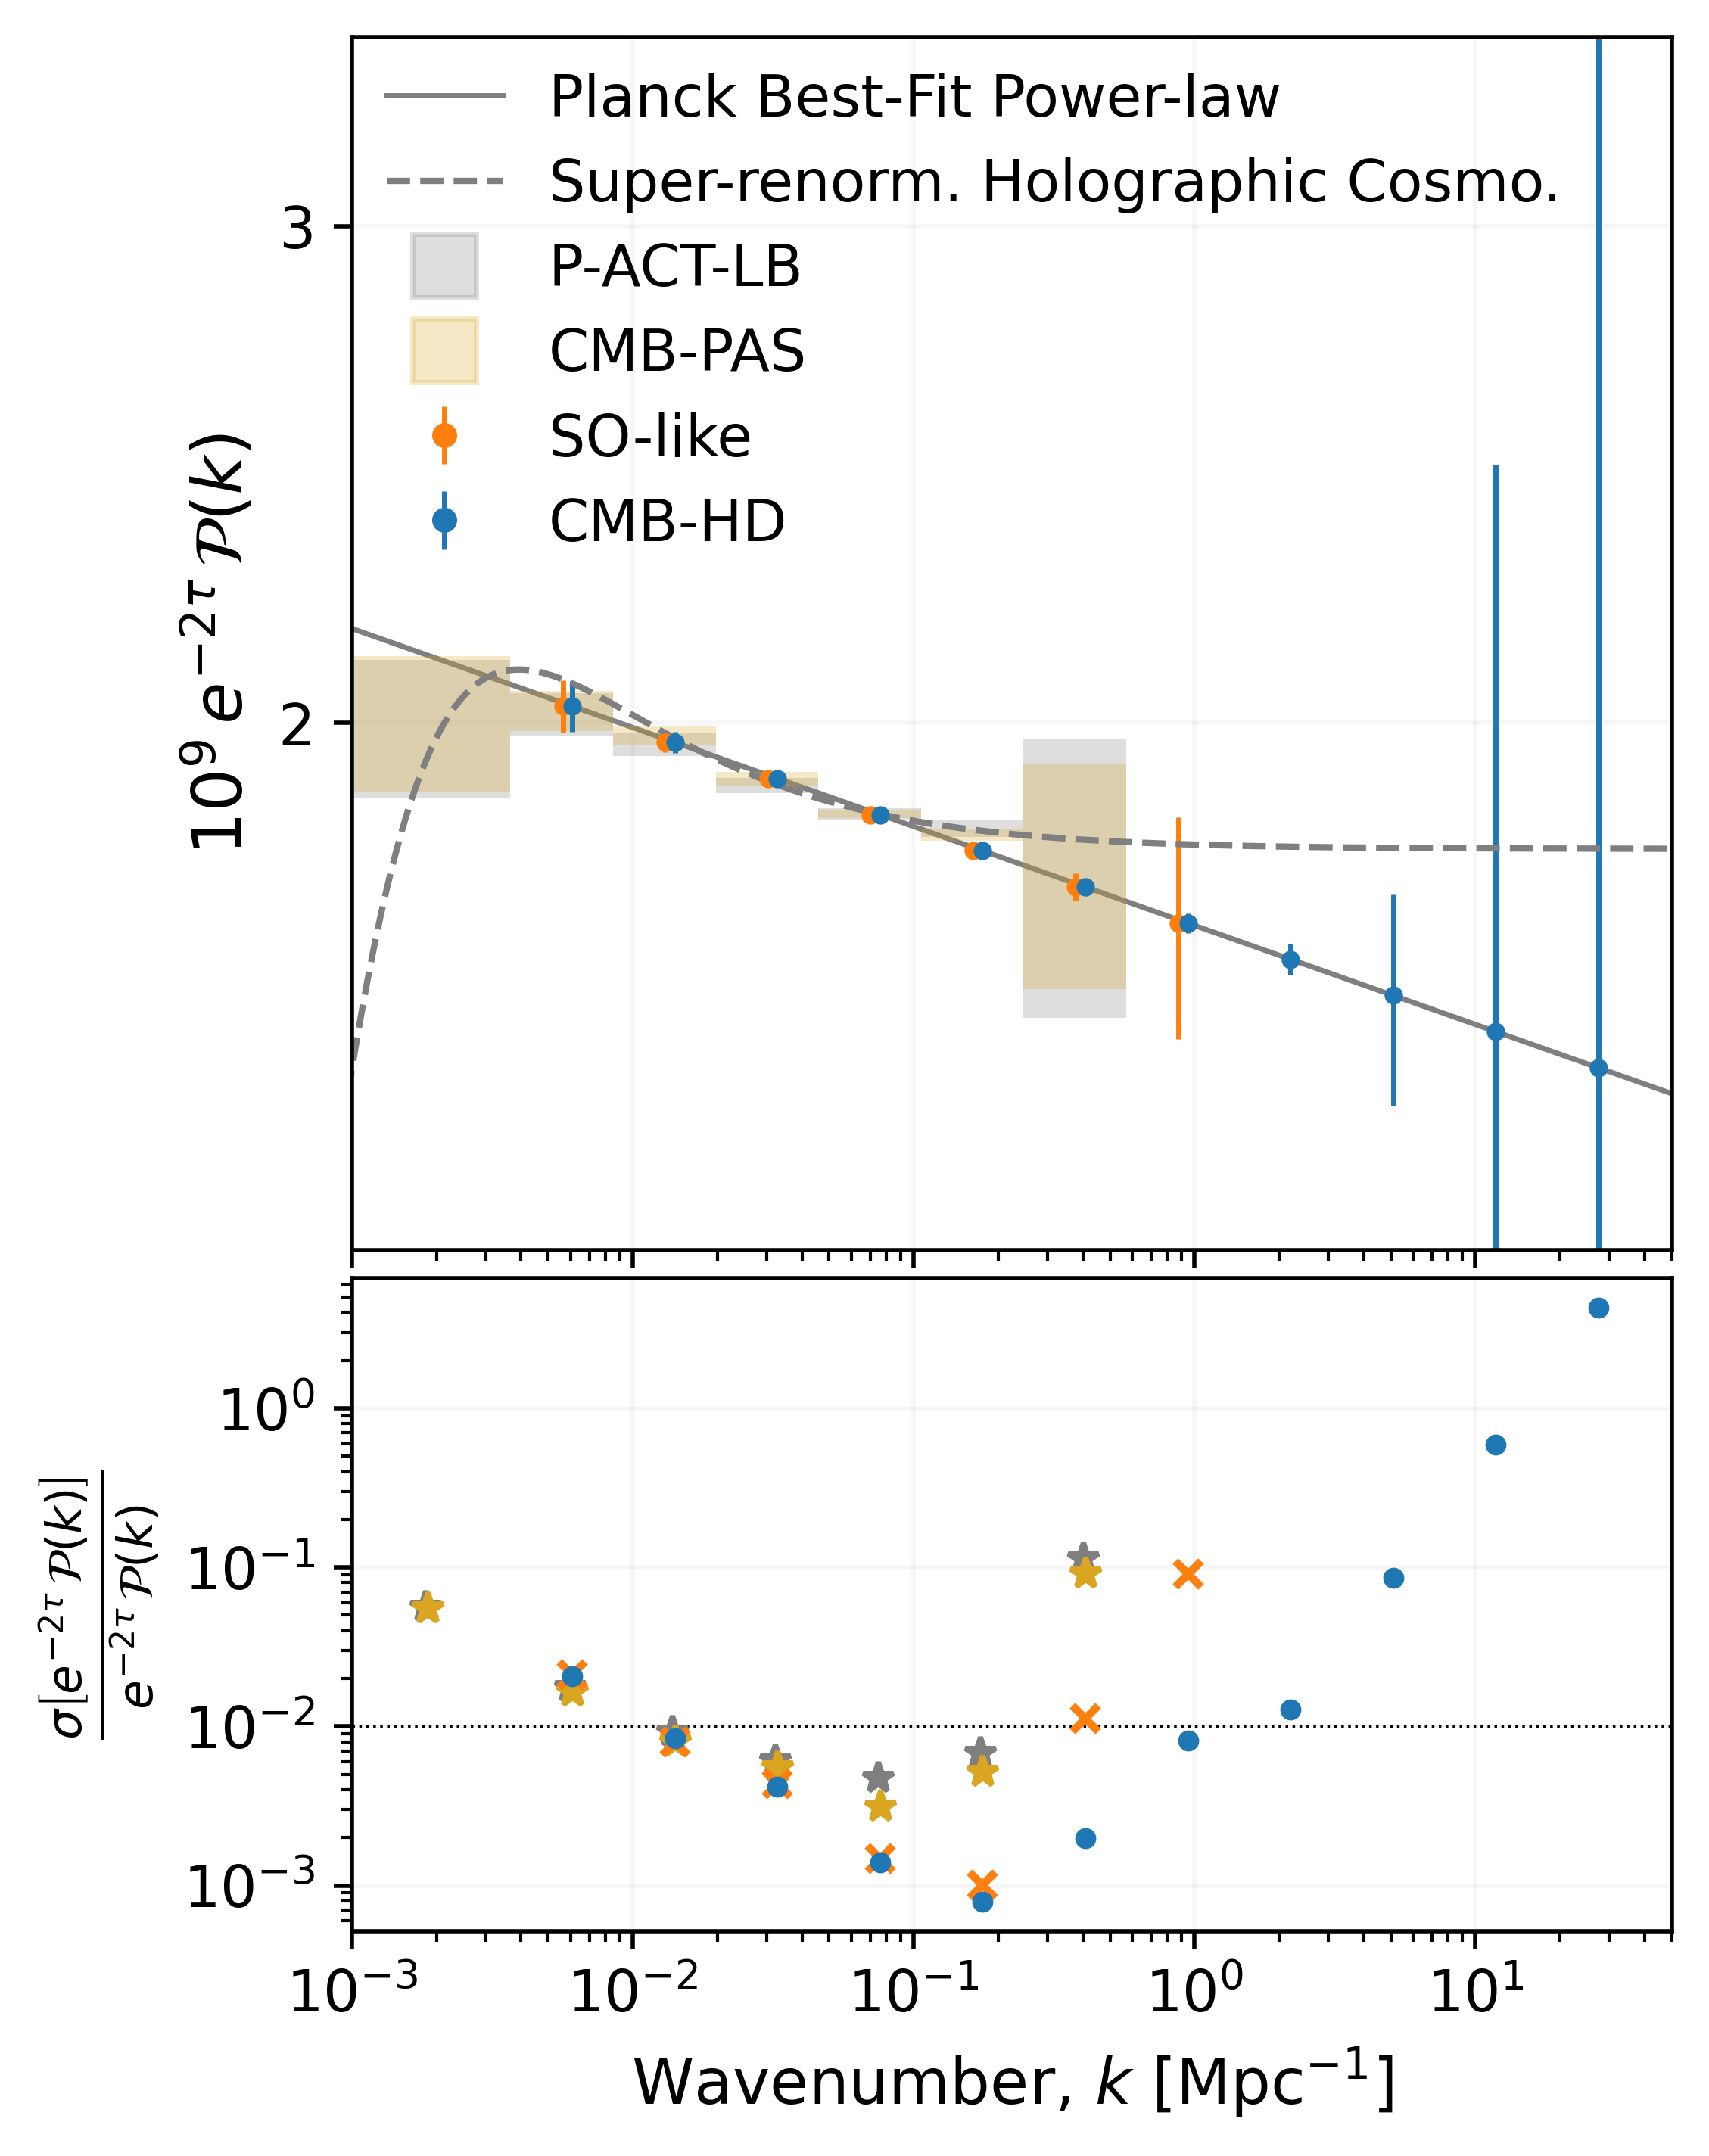

In [31]:
fig3_legend_kwargs = {
    'frameon': False,
    'fontsize': legend_fontsize,
    'loc': 'upper left',
    'bbox_to_anchor': (0, 1),
    'markerscale': 1.5,
    'borderpad': 0.1,
}

plt_kmin, plt_kmax = 1e-3, 50

ks_extended = np.logspace(np.log10(1e-8), np.log10(50), 500)
hd_pk_extended = [1e9 * np.exp(-2 * tau) * hd_Pk(k) for k in ks_extended]
srhc_pk_extended = [srhc_Pk_eneg2tau(k) for k in ks_extended]

fig, (ax_main, ax_frac) = plt.subplots(
    2, 1, figsize=(4.5, 6.5), dpi=500, facecolor='w', sharex=True,
    gridspec_kw={'height_ratios': [0.65, 0.35], 'hspace': 0.03})

fig3_sample_sets = [
    ('P-ACT-LB', p_act_means, p_act_asymmetric_errors, 'tab:grey'),
    ('CMB-PAS', pas_means, pas_asymmetric_errors, 'goldenrod'),
]

# --- main panel ---
set_loglog(ax_main)
ax_main.plot(ks_extended, hd_pk_extended, linestyle='-', color='tab:gray',
             linewidth=1, zorder=1, label='Planck Best-Fit Power-law')
for label, means, (lower_errs, upper_errs), color in fig3_sample_sets:
    add_box_errors(ax_main, ks_chains_7bin, means, lower_errs, upper_errs,
                   color=color, alpha=0.25, edges=pk_bin_edges[:8])
ax_main.errorbar(binning['k bin center [Mpc^-1]'][0:so_max_bin] * (1 - 0.075),
                 eneg2tau_hd_pk_eleven_bins[0:so_max_bin], yerr=so_err,
                 fmt='.', markersize=5, capsize=0.0, elinewidth=elinewidth,
                 color='tab:orange', label='SO-like')
ax_main.errorbar(binning['k bin center [Mpc^-1]'], eneg2tau_hd_pk_eleven_bins,
                 yerr=hd_err, fmt='.', markersize=5, capsize=0.0,
                 elinewidth=elinewidth, color='tab:blue', label='CMB-HD')
ax_main.plot(ks_extended, srhc_pk_extended, linestyle='--', color='tab:grey',
             linewidth=1.2, zorder=2, label='Super-renorm. Holographic Cosmo.')
ax_main.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
ax_main.set_yticks(list(range(1, 7)))
ax_main.set_yticklabels([str(i) for i in range(1, 7)])
ax_main.set_ylabel(pk_ylabel_top, fontsize=axis_label_fontsize + 1)
for label, means, errs, color in fig3_sample_sets:
    ax_main.plot([], [], 's', color=color, alpha=0.25, markersize=8, label=label)
ax_main.legend(**fig3_legend_kwargs)
ax_main.set_ylim(1.3, 3.5)
ax_main.set_xlim(plt_kmin, plt_kmax)
ax_main.grid(alpha=0.1)

# --- fractional-error panel ---
set_loglog(ax_frac)
ax_frac.axhline(y=0.01, color='k', ls=':', lw=0.5)
offset_ks = []
for i in range (0, len(ks_chains_7bin)):
    offset_ks.append(0.98 * ks_chains_7bin[i])
ks = [offset_ks, ks_chains_7bin,]
i=0
for label, means, (lower_errs, upper_errs), color in fig3_sample_sets:
    residuals = [np.mean([lower_errs[i], upper_errs[i]]) / means[i]
                 for i in range(len(means))]
    print(f'{label} fractional errors:', residuals)
    ax_frac.plot(ks[i], residuals, marker='*', markersize=6,
                 ls='None', color=color)
    i+=1
residual_hd = [hd_err[i] / eneg2tau_hd_pk_eleven_bins[i] for i in range(len(hd_err))]
residual_so = [so_err[i] / eneg2tau_hd_pk_eleven_bins[i] for i in range(len(so_err))]
print('CMB-HD fractional errors:', residual_hd)
print('SO-like fractional errors:', residual_so)
ax_frac.plot(binning['k bin center [Mpc^-1]'][0:so_max_bin], residual_so,
             marker='x', markersize=5, ls='None', color='tab:orange', markeredgewidth = 1.5)
ax_frac.plot(binning['k bin center [Mpc^-1]'], residual_hd,
             marker='.', markersize=6, ls='None', color='tab:blue')
ax_frac.set_xlabel(pk_xlabel, fontsize=axis_label_fontsize)
ax_frac.set_ylabel(pk_ylabel_frac, fontsize=axis_label_fontsize + 1)
ax_frac.margins(0.05)
ax_frac.set_xlim(plt_kmin, plt_kmax)
ax_frac.grid(alpha=0.1)

plt.subplots_adjust(hspace=0.03)
save_figure('fig3', bbox_inches='tight')
plt.show()

# Figure 4

Triangle plot of the full 9-parameter posterior: CMB-PAS + DESI DR2 (MCMC)
versus the SO-like and CMB-HD Fisher forecasts.

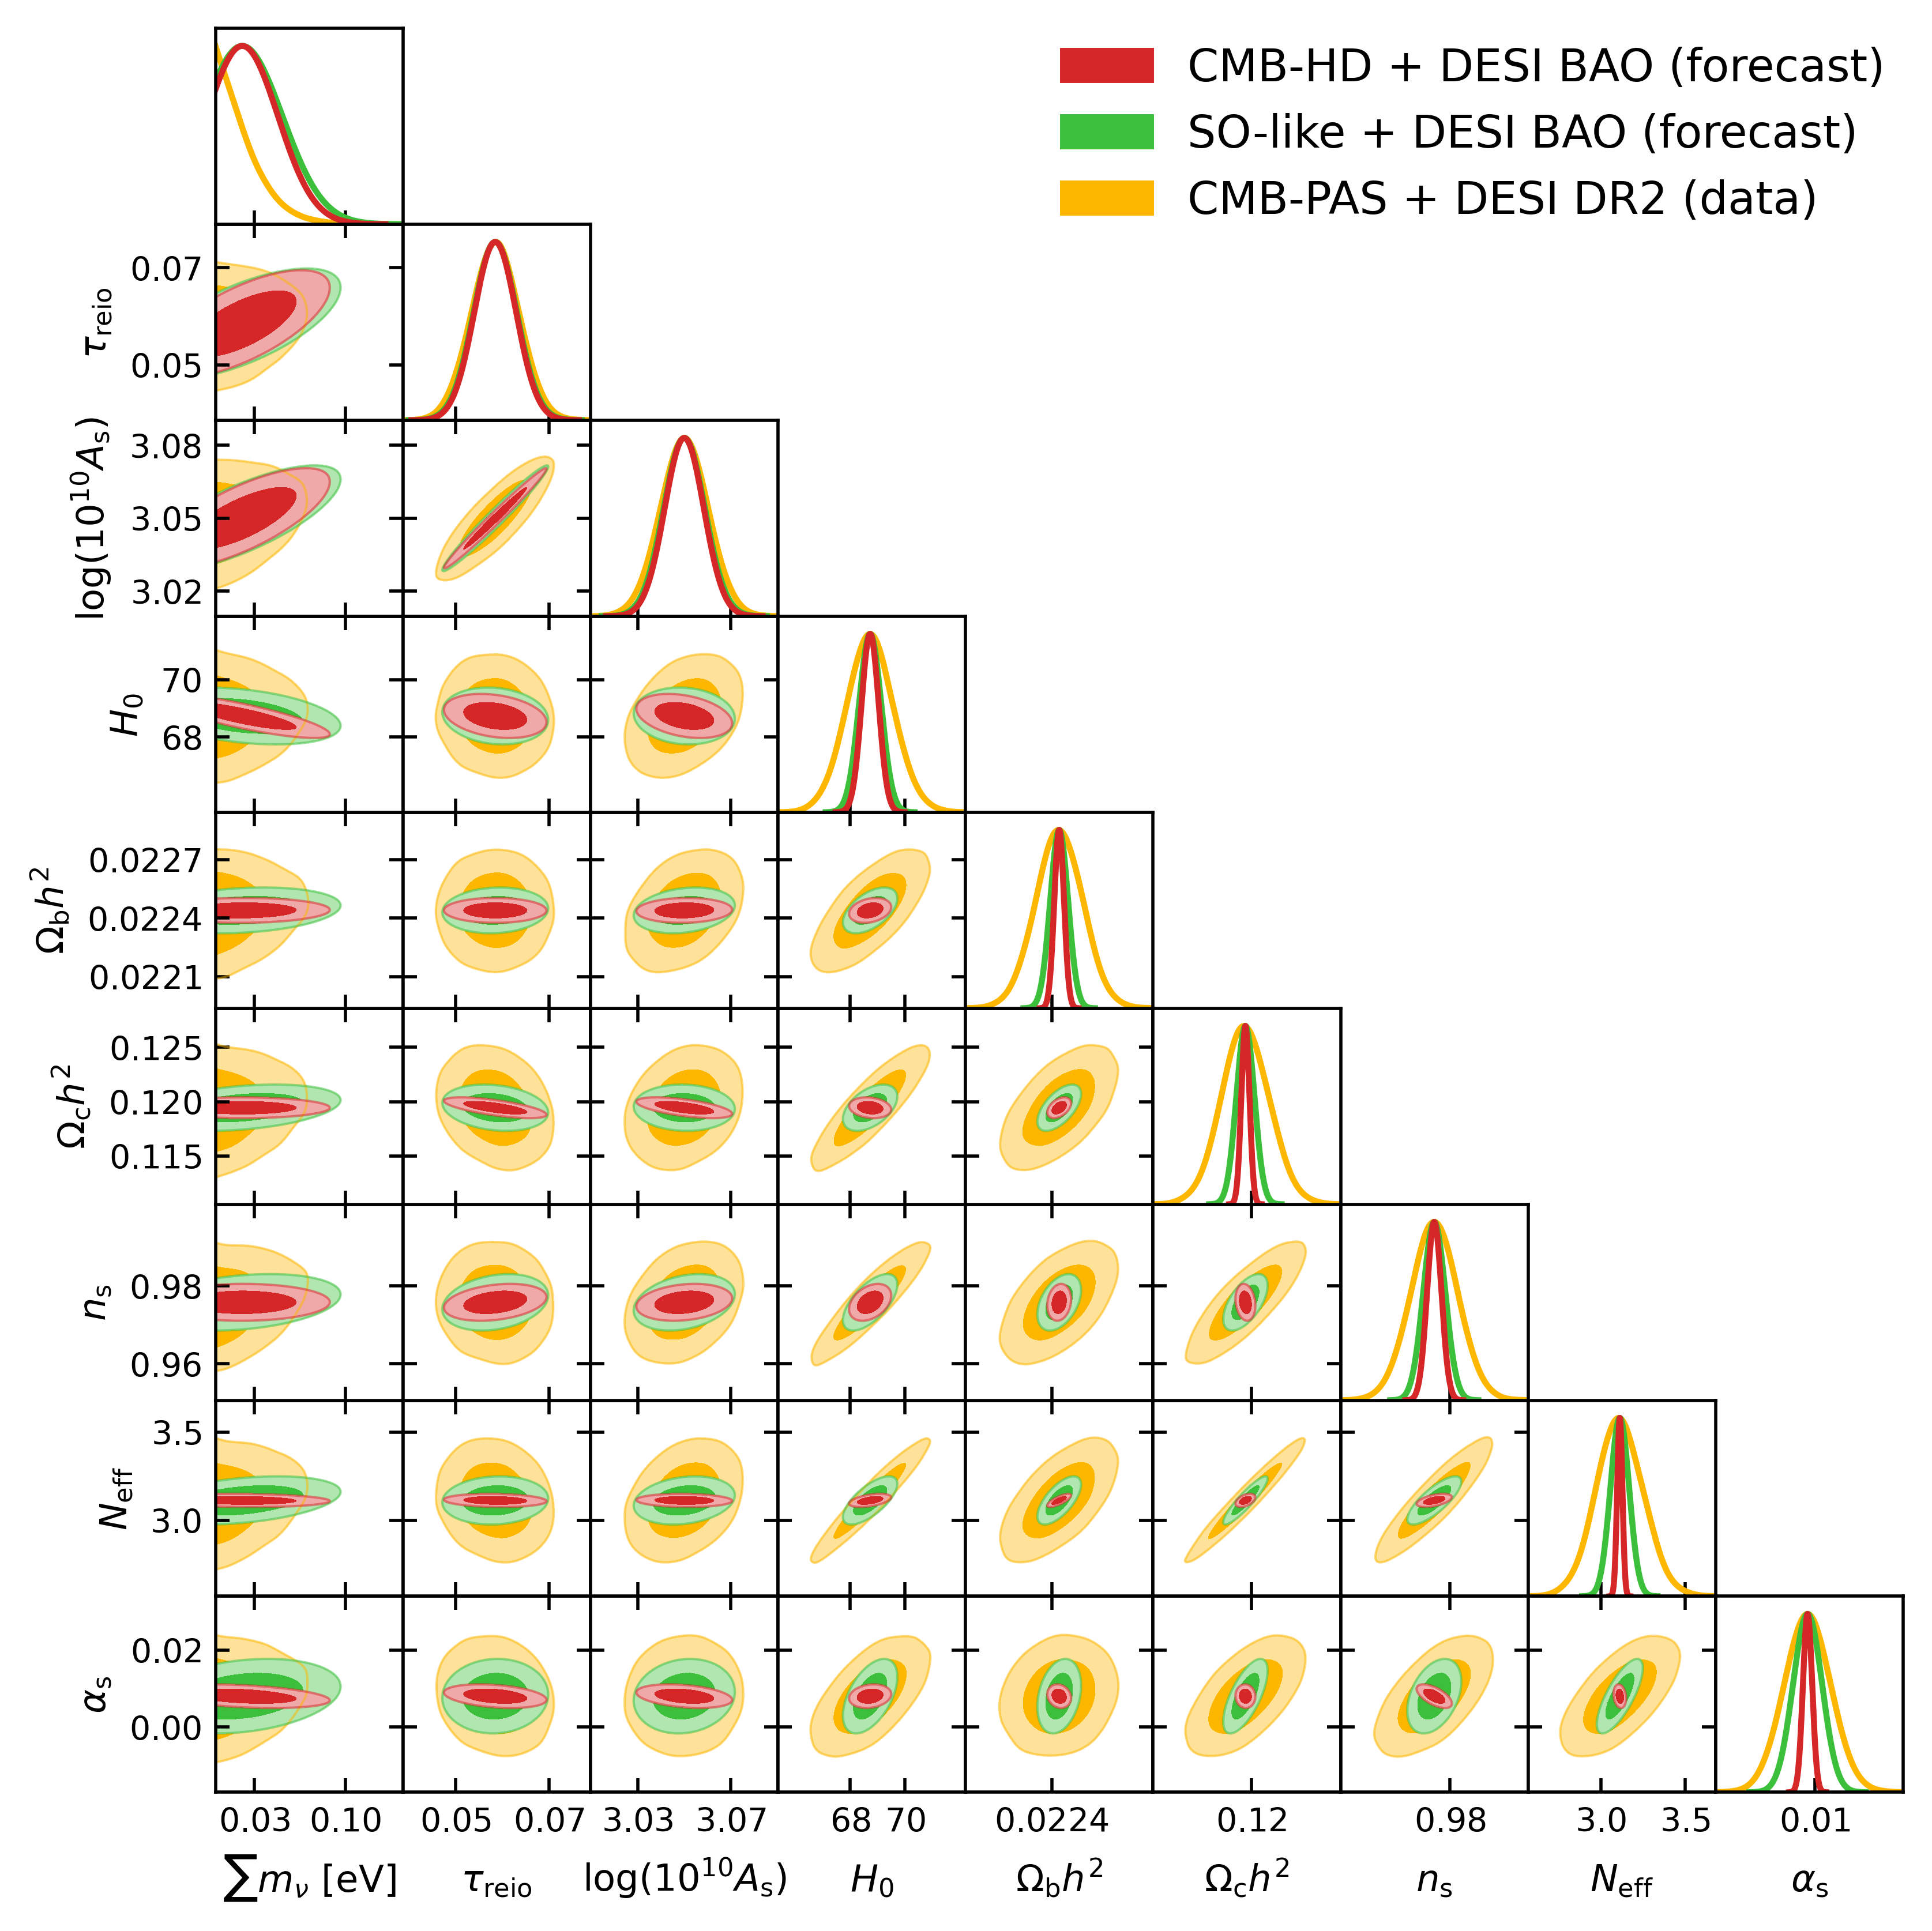

In [32]:
triangle_plot_params = ['mnu', 'tau', 'logA', 'H0', 'ombh2', 'omch2',
                        'ns', 'nnu', 'nrun']
triangle_param_model = 'lcdm_nrun_nnu_mnu'
triangle_data_sets = ['pas', 'so', 'hd']

triangle_samples = [samples[data_set][triangle_param_model]
                    for data_set in triangle_data_sets]
triangle_labels = [exp_labels[data_set] for data_set in triangle_data_sets]
triangle_colors = [exp_colors[data_set] for data_set in triangle_data_sets]
lw_1d = [1.5, 1.5, 1.5]
alphas = [0.6, 0.6, 1.0]

g = plots.get_subplot_plotter(width_inch=6.5)
g.settings.scaling_factor = 1
g.settings.legend_fontsize = 14
g.settings.axes_fontsize = 11
g.settings.axes_labelsize = 12
g.settings.constrained_layout = True
g.settings.figure_legend_frame = False
g.triangle_plot(triangle_samples,
                params=triangle_plot_params,
                filled=True,
                diag1d_kwargs={'lws': lw_1d},
                contour_colors=triangle_colors,
                contour_args=[{'alpha': 1.0}, {'alpha': 1.0}, {'alpha': 1.0}],
                legend_loc='upper right',
                legend_frame=True,
                legend_labels=triangle_labels,
                label_order=-1)

# reduce the tick clutter in the ombh2 column:
col = triangle_plot_params.index('ombh2')
for row in range(len(triangle_plot_params)):
    ax = g.subplots[row, col]
    if ax is not None:
        ax.set_xticks([0.0224])

save_figure('fig4')
plt.show()

# Figure 5

CMB-HD forecasted errors on the binned $e^{-2\tau} \mathcal{P}(k)$ when the
baryonic feedback and kSZ parameters are additionally varied, and when the
lensing reconstruction uses polarization-only estimators.

In [33]:
# The binned-P(k) + feedback + kSZ Fisher matrix, and the variant computed
# with the polarization-only lensing-noise covariance matrix (both produced
# with `hdinitpk`; tau and HMCode_logT_AGN priors and DESI already
# applied):
fisher_matrix_feedback = load_saved_fisher('hd_binned_pk_feedback_lensed')
fisher_matrix_feedback_pol = load_saved_fisher('hd_binned_pk_feedback_pol_lensed')

eneg2tau_pk_errors_feedback = get_eneg2tau_pk_errors(
    fisher_matrix_feedback[0], fisher_matrix_feedback[1], binned_pk_fids)

errs_feedback_pol = fisher.get_fisher_errors(*fisher_matrix_feedback_pol)
print(errs_feedback_pol)

eneg2tau_pk_errors_feedback_pol = get_eneg2tau_pk_errors(
    fisher_matrix_feedback_pol[0], fisher_matrix_feedback_pol[1], binned_pk_fids)

# forecasted 1-sigma errors on 10^9 e^{-2 tau} P(k) per bin:
feedback_err = [1e9 * eneg2tau_pk_errors_feedback[f'Pk{i+1}'] for i in range(11)]
feedback_pol_err = [1e9 * eneg2tau_pk_errors_feedback_pol[f'Pk{i+1}'] for i in range(11)]


Removed no burn in
{'A_ksz': 0.0048760668993886305, 'H0': 0.12719563290987168, 'HMCode_logT_AGN': 0.0046788707405858825, 'Pk1': 4.875679593353078e-11, 'Pk10': 4.374707318451677e-09, 'Pk11': 2.6489184723083138e-08, 'Pk2': 2.2663435663235003e-11, 'Pk3': 1.2389230796963125e-11, 'Pk4': 1.3176105068024933e-11, 'Pk5': 1.383770067725398e-11, 'Pk6': 1.4320507032066552e-11, 'Pk7': 2.9858471221868035e-11, 'Pk8': 4.538825328927639e-11, 'Pk9': 3.4468721053226235e-10, 'n_ksz': 0.006632202786525231, 'ombh2': 1.9508403289589478e-05, 'omch2': 0.0003404185729996886, 'tau': 0.0034661392097503027}
Removed no burn in


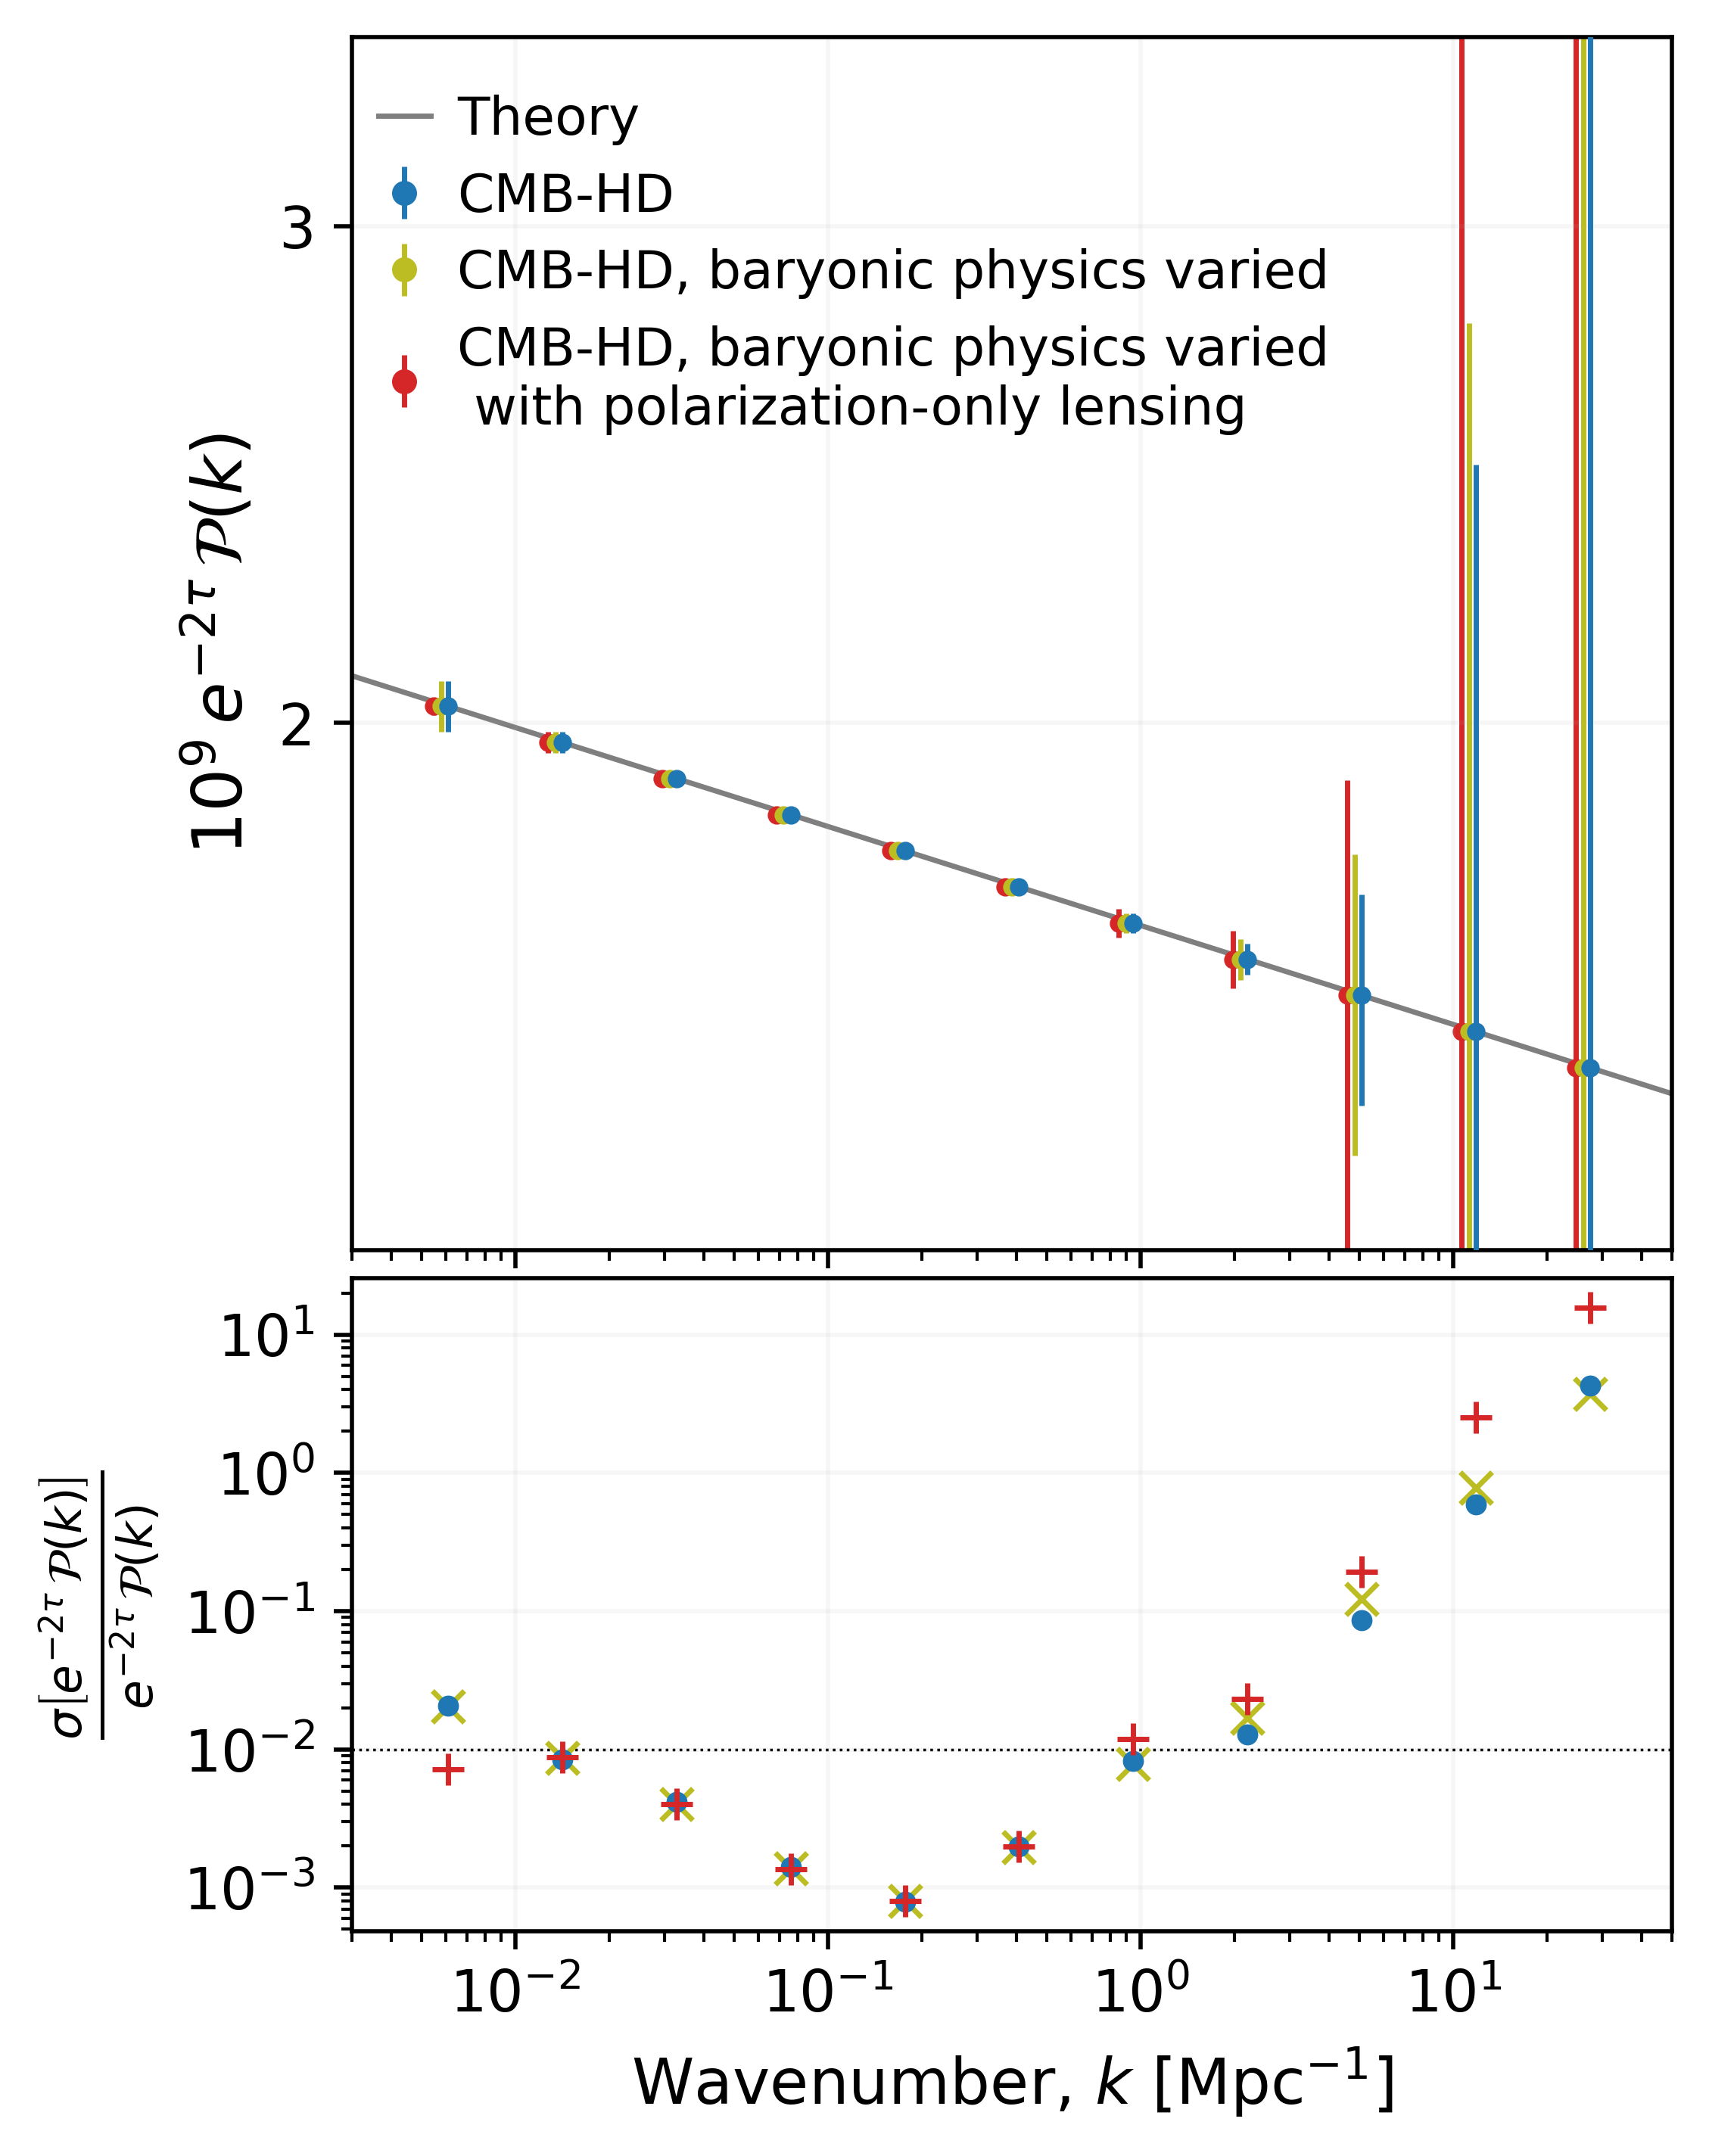

In [34]:
fig5_legend_kwargs = {
    'frameon': False,
    'fontsize': legend_fontsize - 1,
    'loc': 'upper left',
    'bbox_to_anchor': (0, 0.975),
    'markerscale': 1.5,
    'borderpad': 0,
    'handletextpad': 0.5,
    'handlelength': 1.0,
}

plt_kmin, plt_kmax = 3e-3, 50

fig, (ax_main, ax_frac) = plt.subplots(
    2, 1, figsize=(4.5, 6.5), dpi=500, facecolor='w', sharex=True,
    gridspec_kw={'height_ratios': [0.65, 0.35], 'hspace': 0.03})

yellowish = '#bdc736'

# --- main panel ---
set_loglog(ax_main)
ax_main.plot(ks_extended, hd_pk_extended, linestyle='-', color='tab:gray',
             linewidth=1, zorder=1, label='Theory')
# CMB-HD (all k bins) at the bin centers:
ax_main.errorbar(binning['k bin center [Mpc^-1]'], eneg2tau_hd_pk_eleven_bins,
                 yerr=hd_err, fmt='.', markersize=5, capsize=0.0,
                 elinewidth=elinewidth, color='tab:blue', zorder=3,
                 label='CMB-HD')
# feedback series, offset left so the points don't overlap:
ax_main.errorbar(binning['k bin center [Mpc^-1]'] * (1 - 0.05),
                 eneg2tau_hd_pk_eleven_bins, yerr=feedback_err,
                 fmt='.', markersize=5, capsize=0.0, elinewidth=elinewidth,
                 color='tab:olive', zorder=2,
                 label='CMB-HD, baryonic physics varied')
# feedback with the polarization-only lensing covmat, furthest left:
ax_main.errorbar(binning['k bin center [Mpc^-1]'] * (1 - 0.1),
                 eneg2tau_hd_pk_eleven_bins, yerr=feedback_pol_err,
                 fmt='.', markersize=5, capsize=0.0, elinewidth=elinewidth,
                 color='tab:red', zorder=1,
                 label='CMB-HD, baryonic physics varied\n with polarization-only lensing')
ax_main.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
ax_main.set_yticks(list(range(1, 7)))
ax_main.set_yticklabels([str(i) for i in range(1, 7)])
ax_main.set_ylabel(pk_ylabel_top, fontsize=axis_label_fontsize + 1)
ax_main.legend(**fig5_legend_kwargs)
ax_main.set_ylim(1.3, 3.5)
ax_main.set_xlim(plt_kmin, plt_kmax)
ax_main.grid(alpha=0.1)

# --- fractional-error panel ---
set_loglog(ax_frac)
ax_frac.axhline(y=0.01, color='k', ls=':', lw=0.5)
residual_feedback = [feedback_err[i] / eneg2tau_hd_pk_eleven_bins[i]
                     for i in range(len(feedback_err))]
residual_feedback_pol = [feedback_pol_err[i] / eneg2tau_hd_pk_eleven_bins[i]
                         for i in range(len(feedback_pol_err))]
ax_frac.plot(binning['k bin center [Mpc^-1]'], residual_feedback,
             marker='x', markersize=6, ls='None', color='tab:olive')
ax_frac.plot(binning['k bin center [Mpc^-1]'], residual_hd,
             marker='.', markersize=6, ls='None', color='tab:blue')
ax_frac.plot(binning['k bin center [Mpc^-1]'], residual_feedback_pol,
             marker='+', markersize=6, ls='None', color='tab:red')
ax_frac.set_xlabel(pk_xlabel, fontsize=axis_label_fontsize)
ax_frac.set_ylabel(pk_ylabel_frac, fontsize= axis_label_fontsize + 1)
ax_frac.margins(0.05)
ax_frac.set_xlim(plt_kmin, plt_kmax)
ax_frac.grid(alpha=0.1)

plt.subplots_adjust(hspace=0.03)
save_figure('fig5', bbox_inches='tight')
plt.show()

In [35]:
# Fractional change in the errors when varying the baryonic physics
# parameters (and additionally switching to polarization-only lensing).
print('1 - sigma(feedback) / sigma(fiducial) per bin:')
for i in range(11):
    print(f'  {1 - feedback_err[i] / hd_err[i]}')
print('\n1 - sigma(feedback, pol-only lensing) / sigma(fiducial) per bin:')
for i in range(11):
    print(f'  {1 - feedback_pol_err[i] / hd_err[i]}')
print('\nk bin centers [Mpc^-1]:', binning['k bin center [Mpc^-1]'])

1 - sigma(feedback) / sigma(fiducial) per bin:
  0.012504269630185028
  -0.028773797977273308
  0.04761546218697987
  0.022858301710387163
  -0.0012018791605807877
  0.013663016948862627
  0.04114960336106388
  -0.31804263195513593
  -0.4203801772297988
  -0.3302400502989806
  0.12600174634044514

1 - sigma(feedback, pol-only lensing) / sigma(fiducial) per bin:
  0.6531211924272975
  -0.03321217099277196
  0.039839381689313225
  0.026636598616481932
  -0.007381084149148176
  -0.008349730474016992
  -0.44972449445907925
  -0.8235171389970113
  -1.2308428829294864
  -3.2794668429174703
  -2.663027666007419

k bin centers [Mpc^-1]: [6.08676836e-03 1.41162909e-02 3.27381721e-02 7.59256037e-02
 1.76084886e-01 4.08371953e-01 9.47086690e-01 2.19646132e+00
 5.09398177e+00 1.18138435e+01 2.73983897e+01]


# Figure 6

Current and forecasted constraints on the linear matter power spectrum
today, $P_\mathrm{lin}(k, z=0)$, compared to a compilation of measurements
from other surveys. The raw CMB-HD, SO-like, and CMB-PAS
$P_\mathrm{lin}(k, z=0)$ points were computed by `run_hdInitPk_to_LinearPk.py`
(from the feedback + polarization-only-lensing Fisher, the
binned-$\mathcal{P}(k)$ SO Fisher, and the binned-$\mathcal{P}(k)$ chains,
respectively) and saved at their k bin centers in `<data>/fig6`; the
cosmetic x-offsets, the snap onto the theory k grid, and the choice of
central value are applied below, in this notebook. The other survey points
are read from the `hd_pk` package files.

In [36]:
def invMpc_to_h_invMpc(k, h):
    return k / h


def h_invMpc_to_invMpc(k, h):
    return k * h


def cubed_Mpc_per_h_to_Mpc(Pk, h):
    return Pk / h**3


h_fid = 0.6736

# --- theory linear matter power spectrum (today), and survey data points ---
pk_data_dir = os.path.join(cmb_from_pk.hd_pk_dir(), 'pk_plot_data')
pk_data_path = lambda x: os.path.join(pk_data_dir, x)

theo_ks, theo_Pks = np.loadtxt(
    fig6_file('fig6_theory_linear_matter_power.txt', 'theory'), unpack=True)

include_SOlike = True

# survey data sets read straight from the hd_pk package files; the HD, SO,
# and CMB-PAS points are filled below from this notebook's own analysis.
survey_names = ['pas', 'uvlf', 'lya', 'des', 'sdss']
has_k_errs = {'hd': False, 'so': False, 'pas': False, 'uvlf': True,
              'sdss': False, 'lya': False, 'des': True}

mpk_ks = {}
mpk_Pks = {}
mpk_k_errs = {}
mpk_Pk_errs = {}
mpk_Pk_upper_errs = {}
mpk_Pk_lower_errs = {}

# the file-based survey sets (everything except 'pas', handled separately):
for name in ['uvlf', 'lya', 'des', 'sdss']:
    mpk_ks[name] = h_invMpc_to_invMpc(np.loadtxt(pk_data_path(f'{name}_ks.txt')), h_fid)
    if has_k_errs[name]:
        mpk_k_errs[name] = h_invMpc_to_invMpc(
            np.loadtxt(pk_data_path(f'{name}_k_errs.txt')), h_fid)
    mpk_Pks[name] = cubed_Mpc_per_h_to_Mpc(
        np.loadtxt(pk_data_path(f'{name}_Pks.txt')), h_fid)
    mpk_Pk_errs[name] = cubed_Mpc_per_h_to_Mpc(
        np.loadtxt(pk_data_path(f'{name}_Pk_errs.txt')), h_fid)

In [37]:
# ----------------------------------------------------------------------
# CMB-HD, SO-like, and CMB-PAS P_lin(k, z=0) points.
# ----------------------------------------------------------------------
# The saved files hold the RAW per-bin values: the k bin centers (with no
# offsets applied), the central value (the sample
# mean), the symmetric 1-sigma, and the (positive) lower/upper 68% errors.
# The cosmetic x-offsets, the snap onto the theory k grid, and the choice
# of central value are all applied here, so it is clear what is being done.

# Highest bin to keep per experiment.
PLIN_MAX_BIN = {'hd': 11, 'so': 7}

# Cosmetic x-offsets, so overlapping points are readable.
PLIN_X_OFFSET = {'hd': 1.0, 'so': 0.95, 'pas': 0.9}

# Central value for each point:
#   'theory' places the point on the plotted theory curve, which is the
#     fiducial
#   'sample' uses the mean of the sampled Plin
PLIN_CENTRAL = 'sample'

# Symmetric 1 sigma, or the asymmetric 68% interval, for the HD/SO points
# (the CMB-PAS chain points are always plotted with asymmetric errors).
PLIN_ASYMMETRIC = False


def load_plin_points(name):
    """Read fig6_points_<name>.txt into a dict of columns. The CMB-HD and
    SO-like points are the Fisher half of Figure 6, and the CMB-PAS points
    the chain half, so each is read from the directory `fig6_source`
    chose for it."""
    kind = 'chain' if name == 'pas' else 'fisher'
    path = fig6_file(f'fig6_points_{name}.txt', kind)
    k, mean, sigma, lo, hi = np.loadtxt(path, unpack=True)
    return {'k': k, 'mean': mean, 'sigma': sigma, 'lower': lo, 'upper': hi}


# --- CMB-HD and SO-like, from the binned-P(k) Fisher matrices ---
for name in ('hd', 'so'):
    if name == 'so' and not include_SOlike:
        continue
    d = load_plin_points(name)
    n_keep = min(PLIN_MAX_BIN[name], len(d['k']))

    ks, pks, errs, lo_errs, hi_errs = [], [], [], [], []
    for i in range(n_keep):
        k_plot = d['k'][i] * PLIN_X_OFFSET[name]   # cosmetic x-offset
        # snap to the nearest theory k, so the points sit exactly on the
        # plotted curve:
        idx = np.argmin(np.abs(theo_ks - k_plot))
        ks.append(theo_ks[idx])

        central = theo_Pks[idx] if PLIN_CENTRAL == 'theory' else d['mean'][i]
        pks.append(central)

        errs.append(d['sigma'][i])
        lo_errs.append(d['lower'][i])
        hi_errs.append(d['upper'][i])

    mpk_ks[name] = np.array(ks)
    mpk_Pks[name] = np.array(pks)
    mpk_Pk_errs[name] = np.array(errs)
    if PLIN_ASYMMETRIC:
        mpk_Pk_lower_errs[name] = np.array(lo_errs)
        mpk_Pk_upper_errs[name] = np.array(hi_errs)

# --- CMB-PAS, from the binned-P(k) chains (always asymmetric) ---
d = load_plin_points('pas')
pas_k, pas_pk, pas_pk_errs, pas_pk_lo, pas_pk_up = [], [], [], [], []
for i in range(len(d['k'])):
    k_plot = d['k'][i] * PLIN_X_OFFSET['pas']      # cosmetic x-offset
    idx = np.argmin(np.abs(theo_ks - k_plot))      # snap to the theory grid
    pas_k.append(theo_ks[idx])
    pas_pk.append(d['mean'][i])
    pas_pk_lo.append(d['lower'][i])
    pas_pk_up.append(d['upper'][i])
    pas_pk_errs.append(d['sigma'][i])

mpk_ks['pas'] = np.array(pas_k)
mpk_Pks['pas'] = np.array(pas_pk)
mpk_Pk_errs['pas'] = np.array(pas_pk_errs)
mpk_Pk_upper_errs['pas'] = np.array(pas_pk_up)
mpk_Pk_lower_errs['pas'] = np.array(pas_pk_lo)

print('CMB-PAS from chains: P_m(k) [Mpc^3] and fractional error per bin')
for i in range(len(mpk_ks['pas'])):
    frac = mpk_Pk_errs['pas'][i] / mpk_Pks['pas'][i]
    print(f"  k = {mpk_ks['pas'][i]:.4f}  P_m = {mpk_Pks['pas'][i]:.4e}  "
          f"-{mpk_Pk_lower_errs['pas'][i]:.3e} / "
          f"+{mpk_Pk_upper_errs['pas'][i]:.3e}  ({frac:.3%})")


CMB-PAS from chains: P_m(k) [Mpc^3] and fractional error per bin
  k = 0.0017  P_m = 2.9185e+04  -1.608e+03 / +1.609e+03  (5.512%)
  k = 0.0055  P_m = 6.8187e+04  -1.284e+03 / +1.286e+03  (1.884%)
  k = 0.0127  P_m = 7.7895e+04  -8.819e+02 / +8.863e+02  (1.135%)
  k = 0.0295  P_m = 4.1371e+04  -5.174e+02 / +5.195e+02  (1.253%)
  k = 0.0683  P_m = 1.5314e+04  -1.980e+02 / +1.977e+02  (1.292%)
  k = 0.1585  P_m = 3.9549e+03  -5.899e+01 / +5.924e+01  (1.495%)
  k = 0.3678  P_m = 6.9836e+02  -6.332e+01 / +6.336e+01  (9.070%)


In [38]:
# plotting order, labels, colors, and z-orders for Figure 6:
mpk_data_set_names = ['hd']
if include_SOlike:
    mpk_data_set_names.append('so')
mpk_data_set_names += survey_names

# `mpk_labels`, `mpk_colors`, and `mpk_zorders` are imported from
# `hdinitpk.plotting_utilities`.
# mass scale for the top axis (Hlozek et al. 2011):
Omega_m = (0.12 + 0.02237) / (h_fid**2)
rho_crit = h_fid**2 * 2.775e11
rho_m = Omega_m * rho_crit
M_of_k = lambda k: (4 * np.pi / 3) * rho_m * (np.pi / k)**3
k_c = lambda M_c: np.pi / (M_c / ((4 * np.pi / 3) * rho_m))**(1/3)

CMB-HD fractional errors: [1.62960864e-02 9.80028228e-03 3.84120277e-03 2.36615858e-03
 1.92235482e-03 2.22545911e-03 1.07291029e-02 2.31561569e-02
 1.91783412e-01 2.53032883e+00 1.63732746e+01]


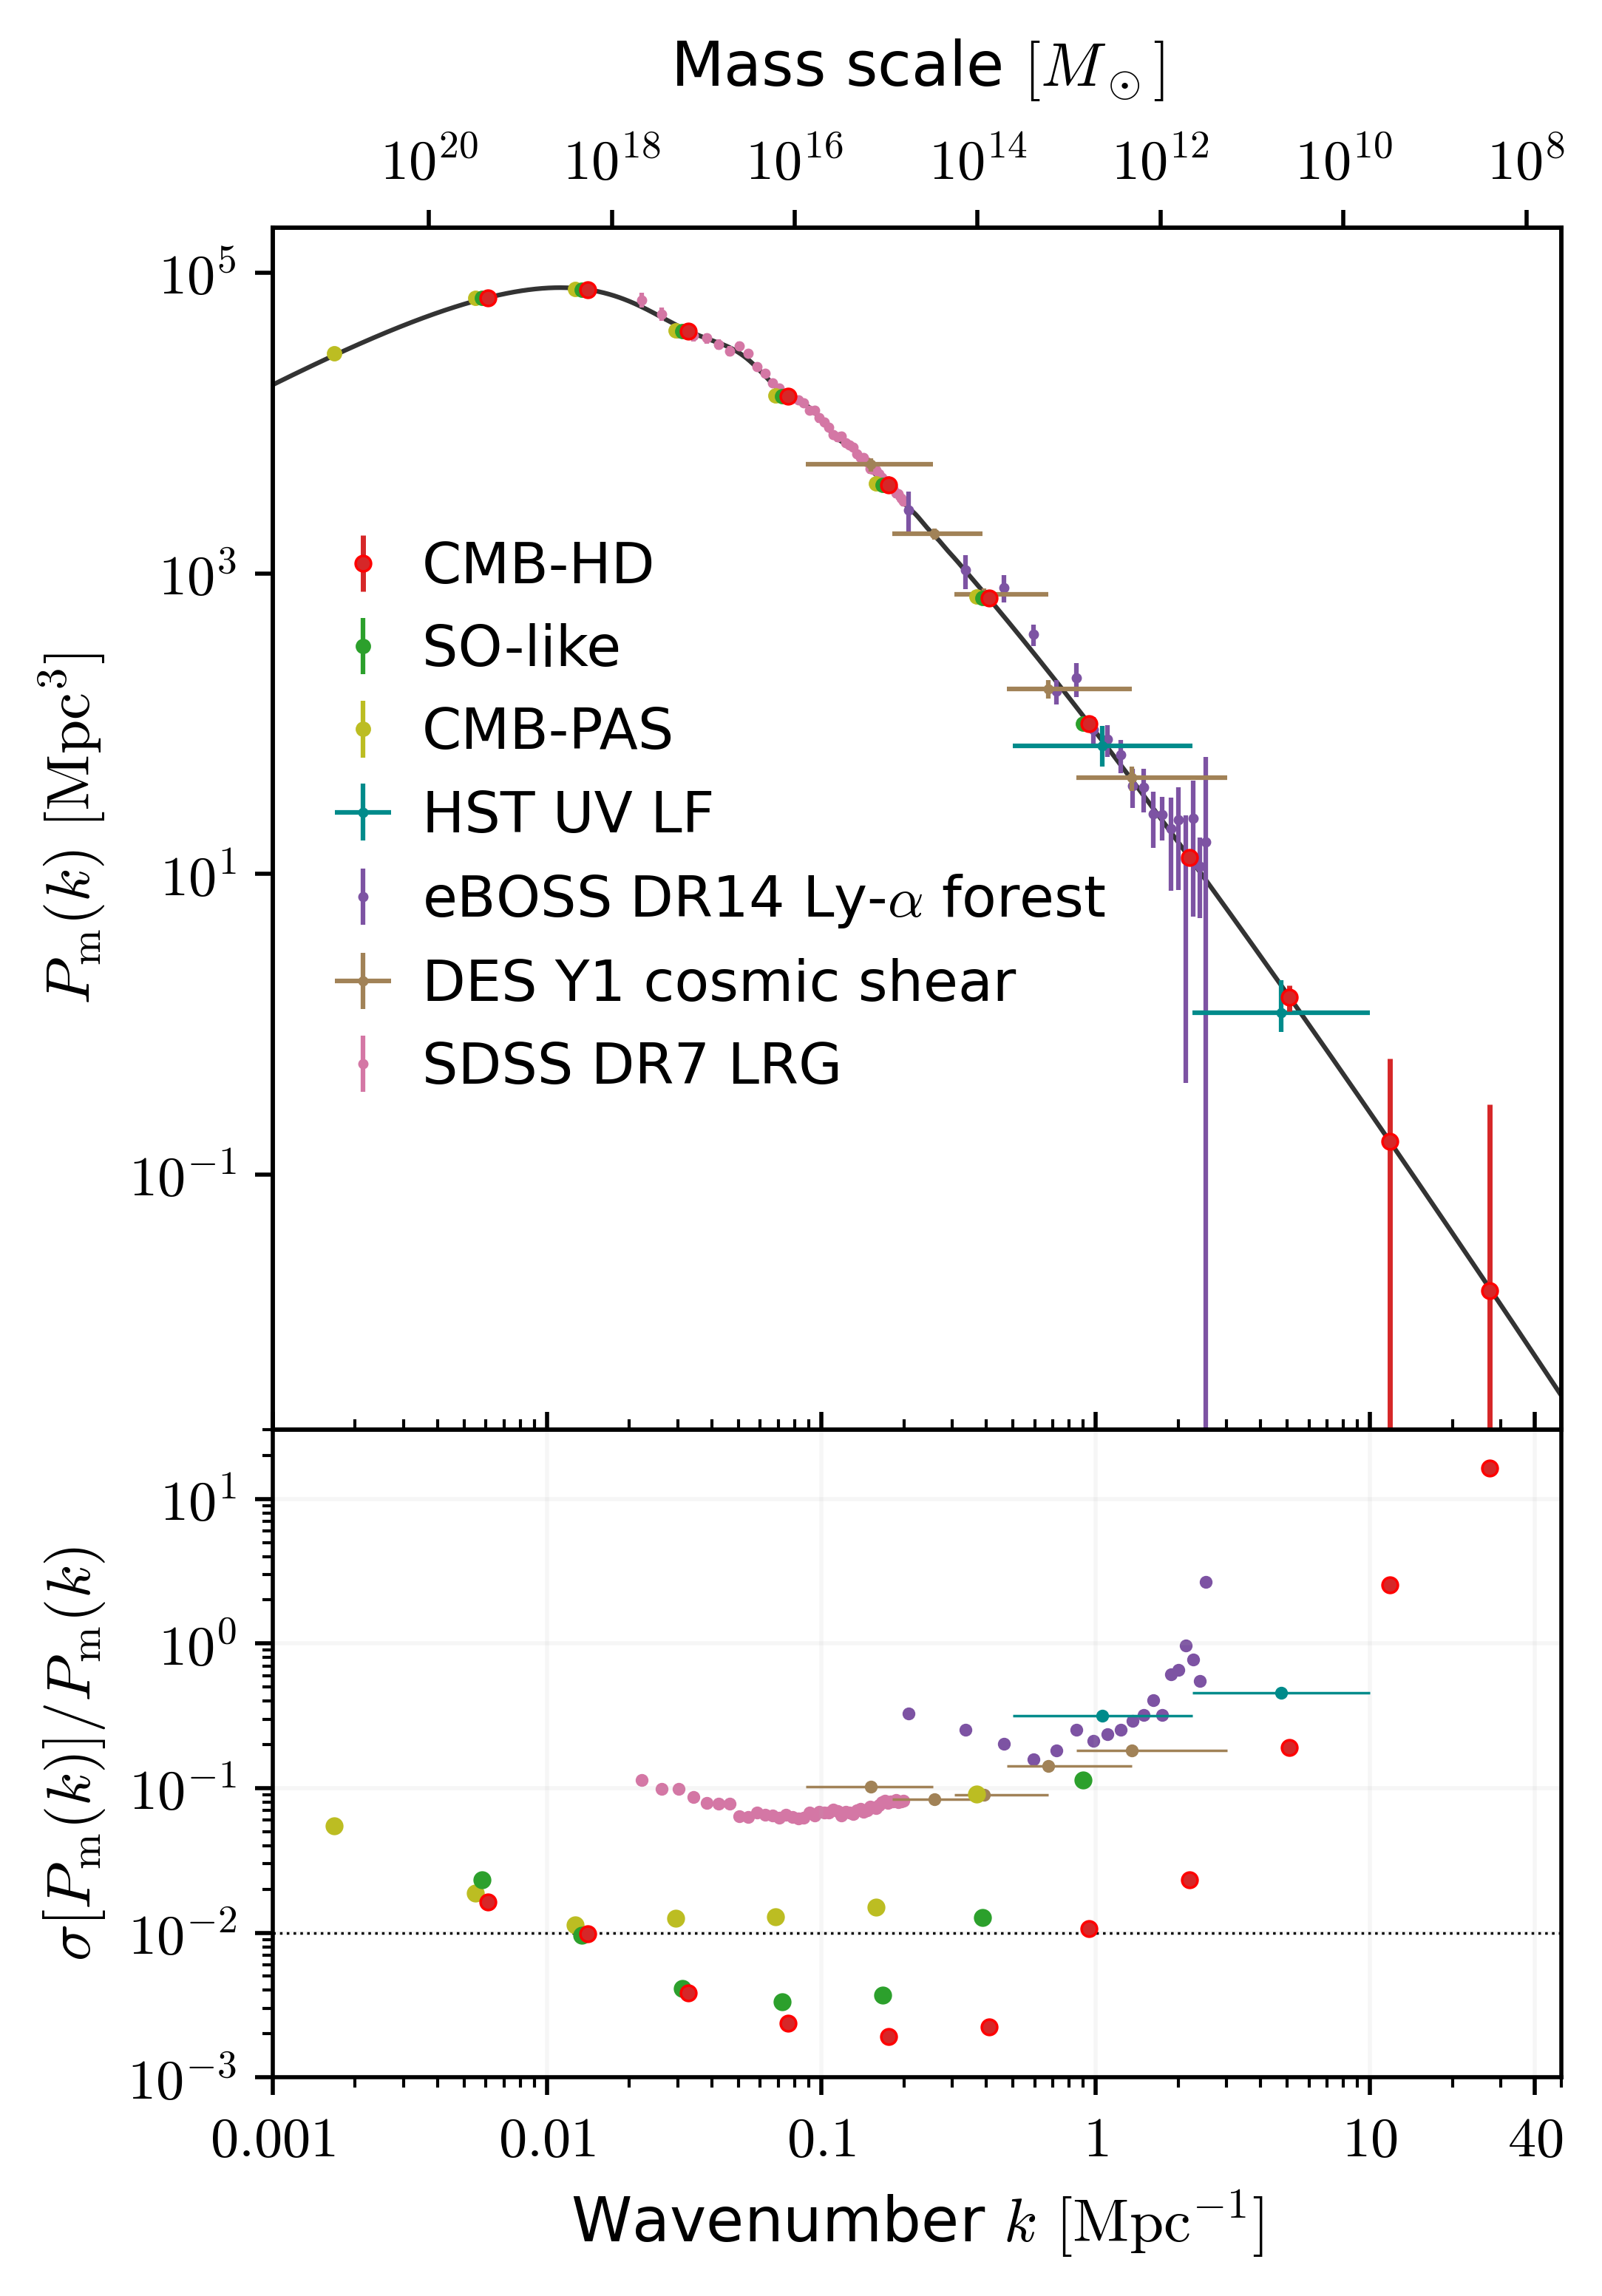

In [39]:
mpk_marker = '.'
mpk_mew = 0.5
mpk_markersize = {key: 3 for key in mpk_data_set_names}
mpk_markersize['so'] = 5
mpk_markersize['pas'] = 5
mpk_markersize['hd'] = 6
mpk_elw = 0.9
mpk_alpha = 1
plt.rcParams['mathtext.fontset'] = 'cm'

fig6_xmin, fig6_xmax = 1e-3, 50
fig6_xticks = [10**i for i in range(-3, 3)]
fig6_xticks[-1] = 40

fig, (ax, ax3) = plt.subplots(figsize=(4.5, 6.5), nrows=2,
                              height_ratios=[0.65, 0.35], dpi=500, facecolor='w')

# --- top panel: P_m(k) ---
ax.margins(0.1)
ax.plot(theo_ks, theo_Pks, color='k', alpha=0.8, lw=0.9, zorder=-10)

# CMB-HD:
ax.errorbar(mpk_ks['hd'], mpk_Pks['hd'], yerr=mpk_Pk_errs['hd'],
            label=mpk_labels['hd'], color=mpk_colors['hd'],
            zorder=mpk_zorders['hd'], ls='none', marker=mpk_marker,
            markeredgewidth=mpk_mew, markeredgecolor='r',
            markersize=mpk_markersize['hd'], elinewidth=1)

for key in mpk_data_set_names[1:]:
    yerr = ([mpk_Pk_lower_errs[key], mpk_Pk_upper_errs[key]]
            if key in mpk_Pk_upper_errs else mpk_Pk_errs[key])
    xerr = mpk_k_errs[key] if key in mpk_k_errs else None
    ax.errorbar(mpk_ks[key], mpk_Pks[key], yerr=yerr, xerr=xerr,
                label=mpk_labels[key], zorder=mpk_zorders.get(key),
                color=mpk_colors[key], alpha=mpk_alpha, marker=mpk_marker,
                markeredgewidth=mpk_mew, markersize=mpk_markersize[key],
                elinewidth=mpk_elw, ls='none')

ax.set_xlim([fig6_xmin, fig6_xmax])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'$P_\mathrm{m}(k)~[{\rm Mpc}^3]$', fontsize=12)
ax.set_xticks(fig6_xticks)
ax.set_xticklabels(['' for _ in fig6_xticks])
ytick_exps = [-3, -1, 1, 3, 5]
ax.set_yticks([10**e for e in ytick_exps])
ax.set_yticklabels([r'$10^{%d}$' % e for e in ytick_exps])
ax.tick_params(labelsize=11)
ax.tick_params(axis='x', direction='in', which='both')
ax.set_ylim([2e-3, 2e5])

# top mass-scale axis:
ax2 = ax.twiny()
ax2.set_xlim([fig6_xmin, fig6_xmax])
ax2.set_xlabel(r'Mass scale $[M_\odot]$', fontsize=12, labelpad=10)
ax2.set_xscale('log')
ax2.minorticks_off()
M_exps = list(range(8, 25, 2))[::-1]
ax2.set_xticks([k_c(10**e) for e in M_exps], minor=False)
ax2.set_xticklabels([r'$10^{%d}$' % e for e in M_exps], fontsize=11,
                    fontfamily='dejavusans')

# --- bottom panel: fractional error ---
ax3.margins(0.1)
ax3.errorbar(mpk_ks['hd'], mpk_Pk_errs['hd'] / mpk_Pks['hd'],
             color=mpk_colors['hd'], zorder=mpk_zorders['hd'], ls='none',
             marker=mpk_marker, markeredgewidth=mpk_mew, markeredgecolor='r',
             markersize=mpk_markersize['hd'], elinewidth=1)
for key in mpk_data_set_names[1:]:
    pk_errs = mpk_Pk_errs[key]
    if hasattr(pk_errs, 'shape') and len(np.shape(pk_errs)) > 1:
        pk_errs = (np.asarray(pk_errs[1]) + np.asarray(pk_errs[0])) / 2
    xerr = mpk_k_errs[key] if key in mpk_k_errs else None
    ax3.errorbar(mpk_ks[key], np.asarray(pk_errs) / mpk_Pks[key], xerr=xerr,
                 label=mpk_labels[key], zorder=mpk_zorders.get(key),
                 color=mpk_colors[key], alpha=mpk_alpha, marker=mpk_marker,
                 markeredgewidth=mpk_mew, markersize=mpk_markersize[key] + 1,
                 elinewidth=0.5, ls='none')

ax3.axhline(y=0.01, color='k', ls=':', lw=0.5)
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.grid(alpha=0.1)
ax3.set_xticks(fig6_xticks)
ax3.set_xticklabels([r'$%s$' % str(tick) for tick in fig6_xticks])
ax3.set_xlim([fig6_xmin, fig6_xmax])
ax3.set_xlabel(r'Wavenumber $k$ $[{\rm Mpc}^{-1}]$', fontsize=12)
ax3_exps = [-3, -2, -1, 0, 1]
ax3.set_yticks([10**e for e in ax3_exps])
ax3.set_ylim(10**-3, 30)
ax3.set_yticklabels([r'$10^{%d}$' % e for e in ax3_exps])
ax3.set_ylabel(r'$\sigma\left[P_\mathrm{m}(k)\right] / P_\mathrm{m}(k)$',
               fontsize=12)
ax3.tick_params(labelsize=11)

for plt_ax in [ax, ax2, ax3]:
    plt_ax.set_xlim([fig6_xmin, fig6_xmax])

ax.legend(frameon=False, loc='lower left', bbox_to_anchor=(0, 0.25),
          handletextpad=0.05, borderpad=0.1)
plt.subplots_adjust(hspace=0)
save_figure('fig6', bbox_inches='tight', dpi=500)
print('CMB-HD fractional errors:', mpk_Pk_errs['hd'] / mpk_Pks['hd'])
plt.show()

# restore the default mathtext font for the remaining figures:
plt.rcParams['mathtext.fontset'] = 'dejavusans'

# Boltzmann-code accuracy: Figure 7, and where Figure 8 went

Figure 7 compares the binned CAMB and CLASS spectra at the accuracy
settings adopted for the paper. Both sets of spectra ship with the package,
so this section needs nothing external.

**The bias calculation and Figure 8 are not in this notebook.** They are the
one part of the paper that needs the CAMB and CLASS Fisher *derivative*
directories, which are far too large to distribute. They live in
`run_hdInitPk_verify_accuracy_settings.py` in the repository root: point it at your own
derivatives (calculated with `Fisher(...).calculate_fisher_derivs()`; see
`example_calc_binnedPk_forecasts.py`) and it computes

$$b_i = (F^{-1})_{ij} \, \partial_j C^T \, \mathrm{Cov}^{-1} \, (C^\mathrm{true} - C^\mathrm{fid})$$

for each accuracy setting, divides it by the forecasted error, and draws
Figure 8.

In [40]:
# `bin_spec` is used by Figure 7 below. The rest of the bias machinery
# (`calc_bias`, `order_spectra`, `order_derivs`) lives in
# `run_hdInitPk_verify_accuracy_settings.py`, together with the Figure 8 calculation.
def bin_spec(cl, matrix, lmax):
    """Take in a dict of unbinned spectra, the binning matrix, and the
    maximum ell to go to, and return the binned spectra.

    Args:
        cl (dictionary): A dict containing the unbinned spectra. Should have
            keys 'tt', 'te', 'ee', 'bb', 'kk'.
        matrix: The binning matrix to be used to bin the data.
        lmax: The maximum ell of the binning matrix, to cut the spectra at.

    Returns:
        binned_cl (dictionary): a dictionary of the binned spectra.
    """
    slice_end = lmax + 1
    binned_cl = {'tt': (matrix @ cl['tt'][2:slice_end]),
                 'te': (matrix @ cl['te'][2:slice_end]),
                 'ee': (matrix @ cl['ee'][2:slice_end]),
                 'bb': (matrix @ cl['bb'][2:slice_end]),
                 'kk': (matrix @ cl['kk'][2:slice_end])}
    return binned_cl

In [41]:
# Load the CAMB and CLASS spectra, computed over a grid of accuracy
# settings (`lens_potential_accuracy` for CAMB, `P_k_max_h/Mpc` for CLASS).
# These ship with the package, under `<data>/spectra_for_bias`, alongside
# the high-accuracy "true universe" reference spectra that
# `run_hdInitPk_verify_accuracy_settings.py` compares them against.
spectra_path = hdinitpk.data_path('spectra_for_bias')

P_k_max_values = [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
lens_potential_values = [8, 10, 15, 20, 25, 30, 35, 40]
camb_spectra = {}
class_spectra = {}
for p in lens_potential_values:  # CAMB
    camb_spectra[p] = utils.load_from_file(
        os.path.join(spectra_path, 'camb',
                     f'lensed_lmax=24000_lens_potential_accuracy={p}_camb_spectra.txt'),
        ['tt', 'te', 'ee', 'bb', 'kk'])
for p in P_k_max_values:  # CLASS
    class_spectra[p] = utils.load_from_file(
        os.path.join(spectra_path, 'class',
                     f'lensed_lmax=24000_P_k_max_h_Mpc={p}_class_spectra.txt'),
        ['tt', 'te', 'ee', 'bb', 'kk'])

# Figure 7

Ratio of the binned CAMB and CLASS spectra at the accuracy settings adopted
for the paper (`lens_potential_accuracy=30` for CAMB and
`P_k_max_h/Mpc=500` for CLASS).

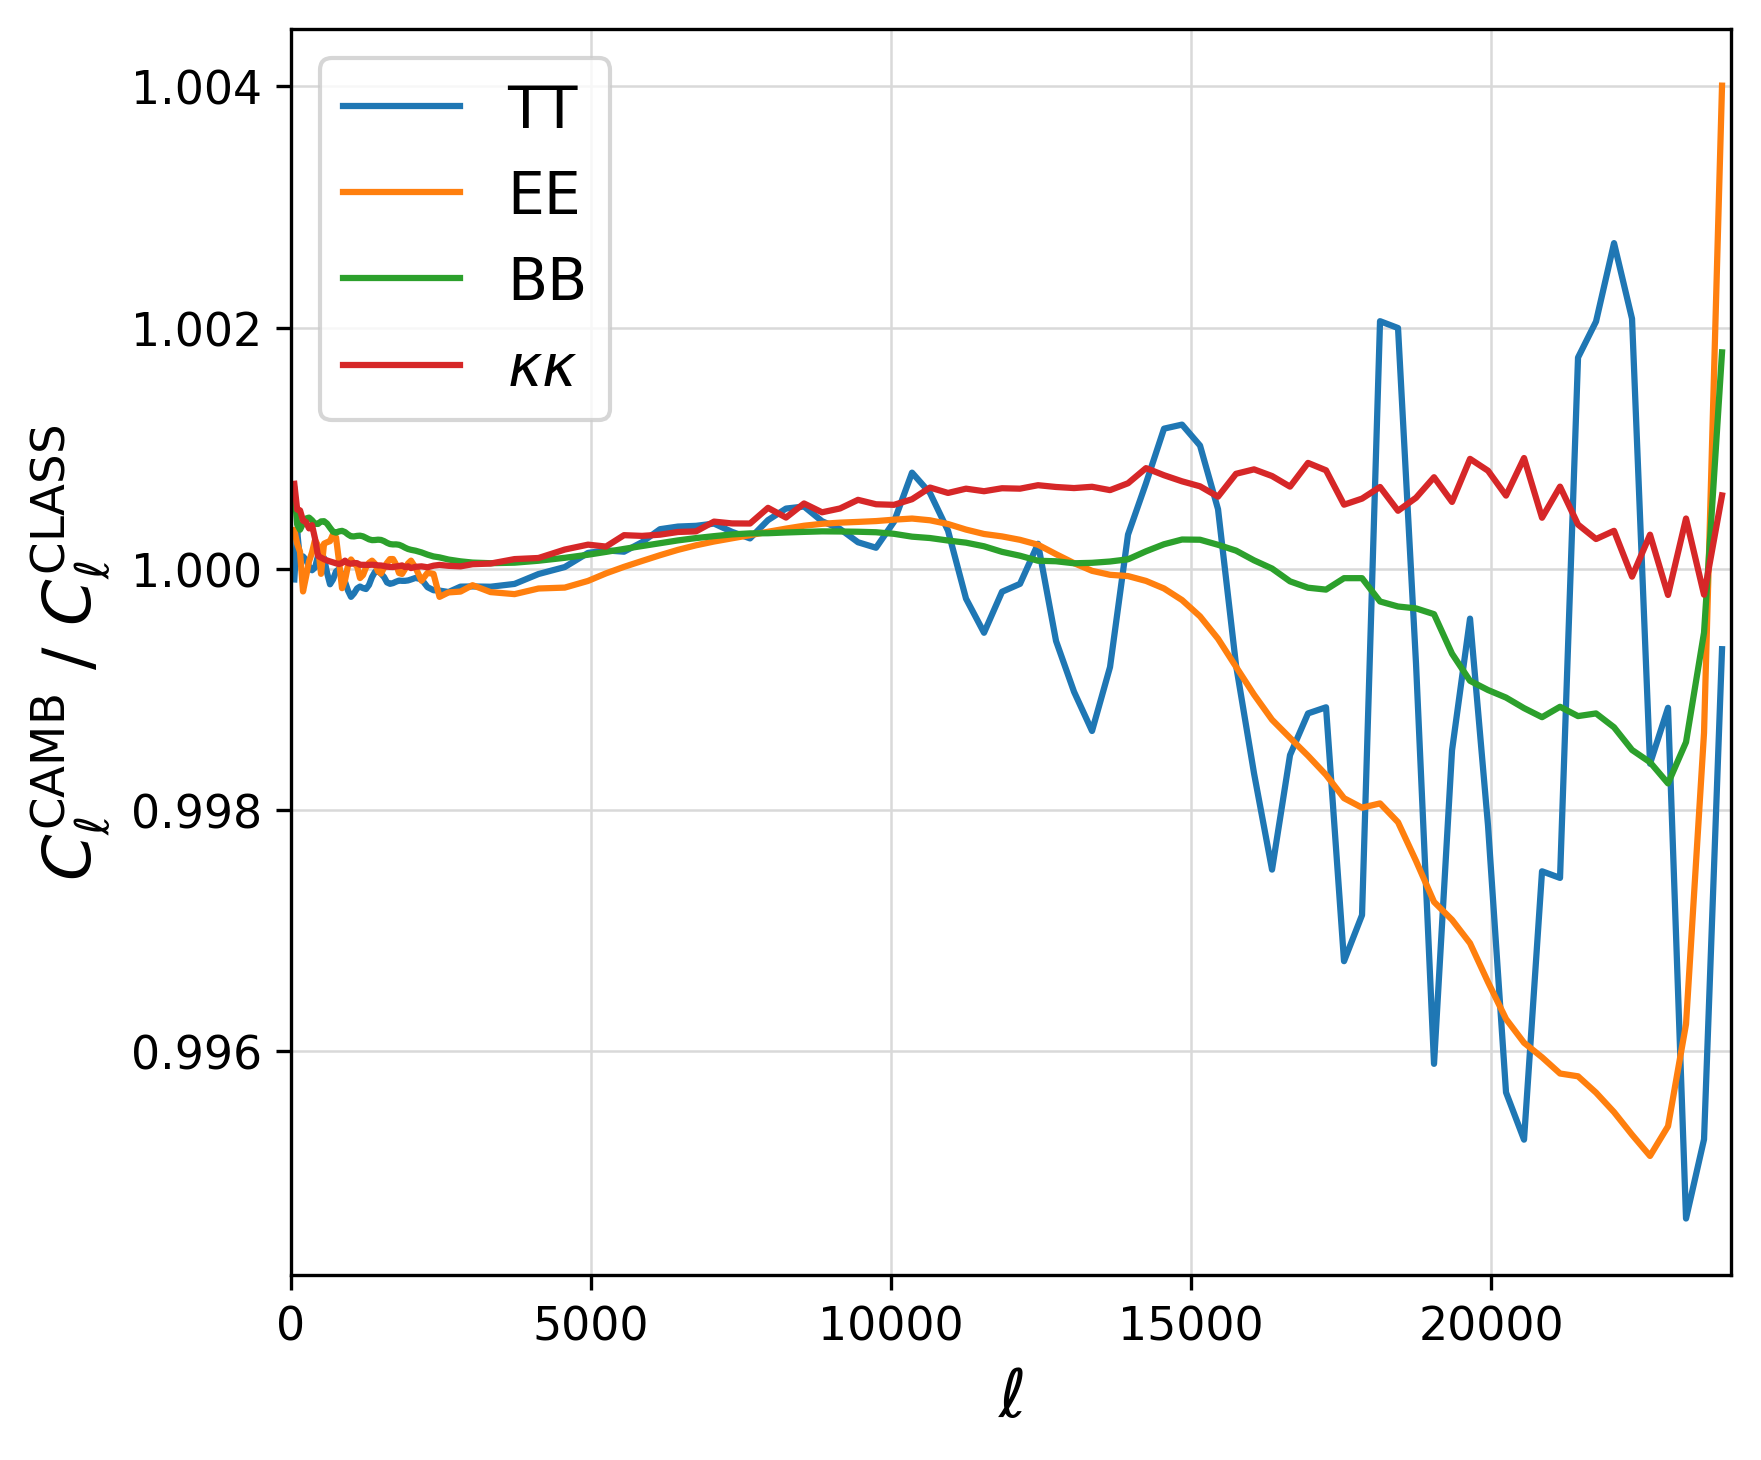

In [42]:
binning_matrix_lmax_24000 = hd_datalib.binning_matrix(lmin=30, lmax=24000)
binned_camb_24000 = bin_spec(camb_spectra[30], binning_matrix_lmax_24000, 24000)
binned_class_24000 = bin_spec(class_spectra[500], binning_matrix_lmax_24000, 24000)
binned_ells = binning_matrix_lmax_24000 @ np.arange(2, 24001)

binned_ratio = {}
for s in ['tt', 'te', 'ee', 'bb', 'kk']:
    binned_ratio[s] = binned_camb_24000[s] / binned_class_24000[s]

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

spectra_labels = {'tt': 'TT', 'ee': 'EE', 'bb': 'BB', 'kk': r'$\kappa \kappa$'}
for s in ['tt', 'ee', 'bb', 'kk']:
    ax.plot(binned_ells, binned_ratio[s], label=spectra_labels[s], linewidth=1.5)

ax.set_xlabel(r'$\ell$', fontsize=16)
ax.set_ylabel(r'$C_\ell^{\mathrm{CAMB}} \ / \ C_\ell^{\mathrm{CLASS}}$', fontsize=16)
ax.legend(fontsize=14)
plt.xlim(0, 24000)
plt.tight_layout()
ax.grid(which='major', linestyle='-', linewidth=0.6, color='0.85')
save_figure('fig7')
plt.show()

# Figure 9

Validation of the Fisher forecasts against full MCMC chains: triangle plot
of the CAMB and CLASS Fisher forecasts versus the corresponding (thinned)
CAMB and CLASS MCMC chains, for CMB-HD + DESI BAO in the 9-parameter model.

In [43]:
def reorder_fisher_matrix(fisher_matrix, original_order, target_order):
    """Reorders the Fisher matrix from `original_order` to `target_order`.

    Args:
        fisher_matrix (ndarray): The Fisher matrix to reorder.
        original_order (list): Current order of parameter names.
        target_order (list): Desired order of parameter names.

    Returns:
        ndarray: Reordered Fisher matrix.
    """
    index_map = [original_order.index(param) for param in target_order]
    return fisher_matrix[np.ix_(index_map, index_map)]

In [44]:
# CAMB MCMC chain (CMB-HD + DESI BAO, 9 parameters), thinned
# (burn-in already removed):
camb_mcmc_samples = load_chain('hd_camb_mcmc_9param')
camb_mcmc_samples.paramNames.parWithName('nrun').label = r'\alpha_\mathrm{s}'
print('R-1 = ', chain_convergence.get('hd_camb_mcmc_9param', float('nan')),
      '(full chain)')

# parameter names (sampled and derived), excluding the chi2 and prior
# bookkeeping columns:
camb_chain_params = [p.name for p in camb_mcmc_samples.getParamNames().names
                     if ('chi2' not in p.name) and ('minuslogprior' not in p.name)]
camb_mcmc_means = {}
camb_mcmc_errors = {}
camb_mstats = camb_mcmc_samples.getMargeStats()
for param in camb_chain_params:
    par = camb_mstats.parWithName(param)
    camb_mcmc_means[param] = par.mean
    camb_mcmc_errors[param] = par.err
print(camb_mcmc_means)
print(camb_mcmc_errors)


/gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdInitPk_upload_latest/hdinitpk/data/chains/hd/hd_camb_mcmc_9param.txt
Removed no burn in
R-1 =  0.009363603415963087 (full chain)
{'logA': 3.0432329518021644, 'ns': 0.9648294558009275, 'H0': 67.3740343745286, 'ombh2': 0.02236990022343122, 'omch2': 0.12003597926738799, 'mnu': 0.05656924968380463, 'nnu': 3.044234836445132, 'tau': 0.05398076169143741, 'nrun': 6.243799655690494e-05, 'As': 2.097361995678516e-09, 'sigma8': 0.8132889691641422}
{'logA': 0.008061862275930391, 'ns': 0.0019366451720601342, 'H0': 0.3066504401942534, 'ombh2': 2.609798946002093e-05, 'omch2': 0.00038824303682306546, 'mnu': 0.027278661100172498, 'nnu': 0.015439135537156411, 'tau': 0.004368932343016975, 'nrun': 0.001281070042573798, 'As': 1.691472419650798e-11, 'sigma8': 0.0037953789257706982}


In [45]:
# CLASS MCMC chain, thinned as above. The chain columns
# use native CLASS/cobaya names (note 'N_eff', unlike the 'N_ur' used by the
# Fisher parameter files), so we use a separate translation dictionary from
# the Fisher one above.
camb_to_class_chain_params = {
    'ombh2': 'omega_b',
    'omch2': 'omega_cdm',
    'tau': 'tau_reio',
    'logA': 'ln_A_s_1e10',
    'As': 'A_s',
    'ns': 'n_s',
    'H0': 'H0',
    'nnu': 'N_eff',
    'mnu': 'mnu',
    'nrun': 'alpha_s',
}

class_mcmc_samples = load_chain('hd_class_mcmc_9param')

# Add CAMB-named aliases for the CLASS parameters, so getdist can match them
# across the four sets of samples in the Figure 9 triangle plot. Driven by
# `camb_to_class_chain_params` and `nine_params` rather than a hard-coded
# list, so it cannot fall out of step with the plot: every parameter the
# triangle plot asks for gets an alias, and any that already carries its
# CAMB name in the chain (`H0`, `mnu`) is skipped.
#
# NOTE the CLASS chain calls the running `alpha_s`, so `parWithName('nrun')`
# is None until the alias below exists, so setting its label before this loop
# raises `AttributeError: 'NoneType' object has no attribute 'label'`.
for param in nine_params:
    class_name = camb_to_class_chain_params[param]
    if class_name == param:
        continue  # same name in both codes; nothing to alias
    par = class_mcmc_samples.paramNames.parWithName(class_name)
    if par is None:
        raise KeyError(
            f"the CLASS chain has no parameter '{class_name}' (the CLASS name "
            f"for '{param}'). Its parameters are: "
            f"{[p.name for p in class_mcmc_samples.getParamNames().names]}. "
            "Fix `camb_to_class_chain_params` above to match the chain.")
    class_mcmc_samples.addDerived(
        getattr(class_mcmc_samples.getParams(), class_name),
        param, label=param_labels[param])

# label the running with the same symbol used for the CAMB chains:
class_mcmc_samples.paramNames.parWithName('nrun').label = r'\alpha_\mathrm{s}'

print('R-1 = ', chain_convergence.get('hd_class_mcmc_9param', float('nan')),
      '(full chain)')

class_chain_params = [p.name for p in class_mcmc_samples.getParamNames().names
                      if ('chi2' not in p.name) and ('minuslogprior' not in p.name)]
class_mcmc_means = {}
class_mcmc_errors = {}
class_mstats = class_mcmc_samples.getMargeStats()
for param in class_chain_params:
    par = class_mstats.parWithName(param)
    class_mcmc_means[param] = par.mean
    class_mcmc_errors[param] = par.err
print(class_mcmc_means)
print(class_mcmc_errors)

/gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdInitPk_upload_latest/hdinitpk/data/chains/hd/hd_class_mcmc_9param.txt
Removed no burn in
R-1 =  0.0110561982892497 (full chain)
{'ln_A_s_1e10': 3.0433424371424715, 'n_s': 0.9648194058486238, 'H0': 67.37568624116298, 'omega_b': 0.022371177336751213, 'omega_cdm': 0.12004326805383163, 'mnu': 0.0566569651154625, 'N_eff': 3.044838208648138, 'tau_reio': 0.05401471172827847, 'alpha_s': 4.9698895113030956e-05, 'A_s': 2.097594945068807e-09, 'tau': 0.05401471172827847, 'logA': 3.0433424371424715, 'ombh2': 0.022371177336751213, 'omch2': 0.12004326805383163, 'ns': 0.9648194058486238, 'nnu': 3.044838208648137, 'nrun': 4.9698895113030956e-05}
{'ln_A_s_1e10': 0.008254311151243249, 'n_s': 0.00197640283343727, 'H0': 0.31669898139526936, 'omega_b': 2.6226491222548124e-05, 'omega_cdm': 0.00038888194681415897, 'mnu': 0.028456993547106988, 'N_eff': 0.015294206599054193, 'tau_reio': 0.004416383907290139, 'alpha_s': 0.0012405105952906636, 'A_s': 1.7323819534261953

In [46]:
# Reorder the Fisher matrices into the plotting order:
print(class_fisher_matrix_with_desi[1])
print(camb_fisher_matrix_with_desi[1])
reordered_class_fisher_matrix_with_desi = reorder_fisher_matrix(
    class_fisher_matrix_with_desi[0], class_fisher_matrix_with_desi[1], nine_params)
reordered_camb_fisher_matrix_with_desi = reorder_fisher_matrix(
    camb_fisher_matrix_with_desi[0], camb_fisher_matrix_with_desi[1], nine_params)

['H0', 'nnu', 'nrun', 'logA', 'ns', 'ombh2', 'omch2', 'mnu', 'tau']
['H0', 'logA', 'mnu', 'nnu', 'nrun', 'ns', 'ombh2', 'omch2', 'tau']


In [47]:
# Fiducial parameter values used to center the Fisher contours and to mark
# the fiducial point in the triangle plot. (The chain files include the
# cobaya-named 'omegabh2'/'omegach2' aliases.)
fig9_fid_params = {'ombh2': 0.02237,
                   'omch2': 0.1200,
                   'omegabh2': 0.02237,
                   'omegach2': 0.1200,
                   'ns': 0.9649,
                   'logA': 3.044,
                   'As': np.exp(3.044) * 1.e-10,
                   'H0': 67.36,
                   'tau': 0.0544,
                   'nnu': 3.044,
                   'mnu': 0.06,
                   'HMCode_logT_AGN': 7.8,
                   'nrun': 0.0,
                   'A_ksz': 1.0,
                   'n_ksz': 0.0}

camb_fisher_samples = getdist_samples(reordered_camb_fisher_matrix_with_desi,
                                      nine_params, fig9_fid_params)
class_fisher_samples = getdist_samples(reordered_class_fisher_matrix_with_desi,
                                       nine_params, fig9_fid_params)

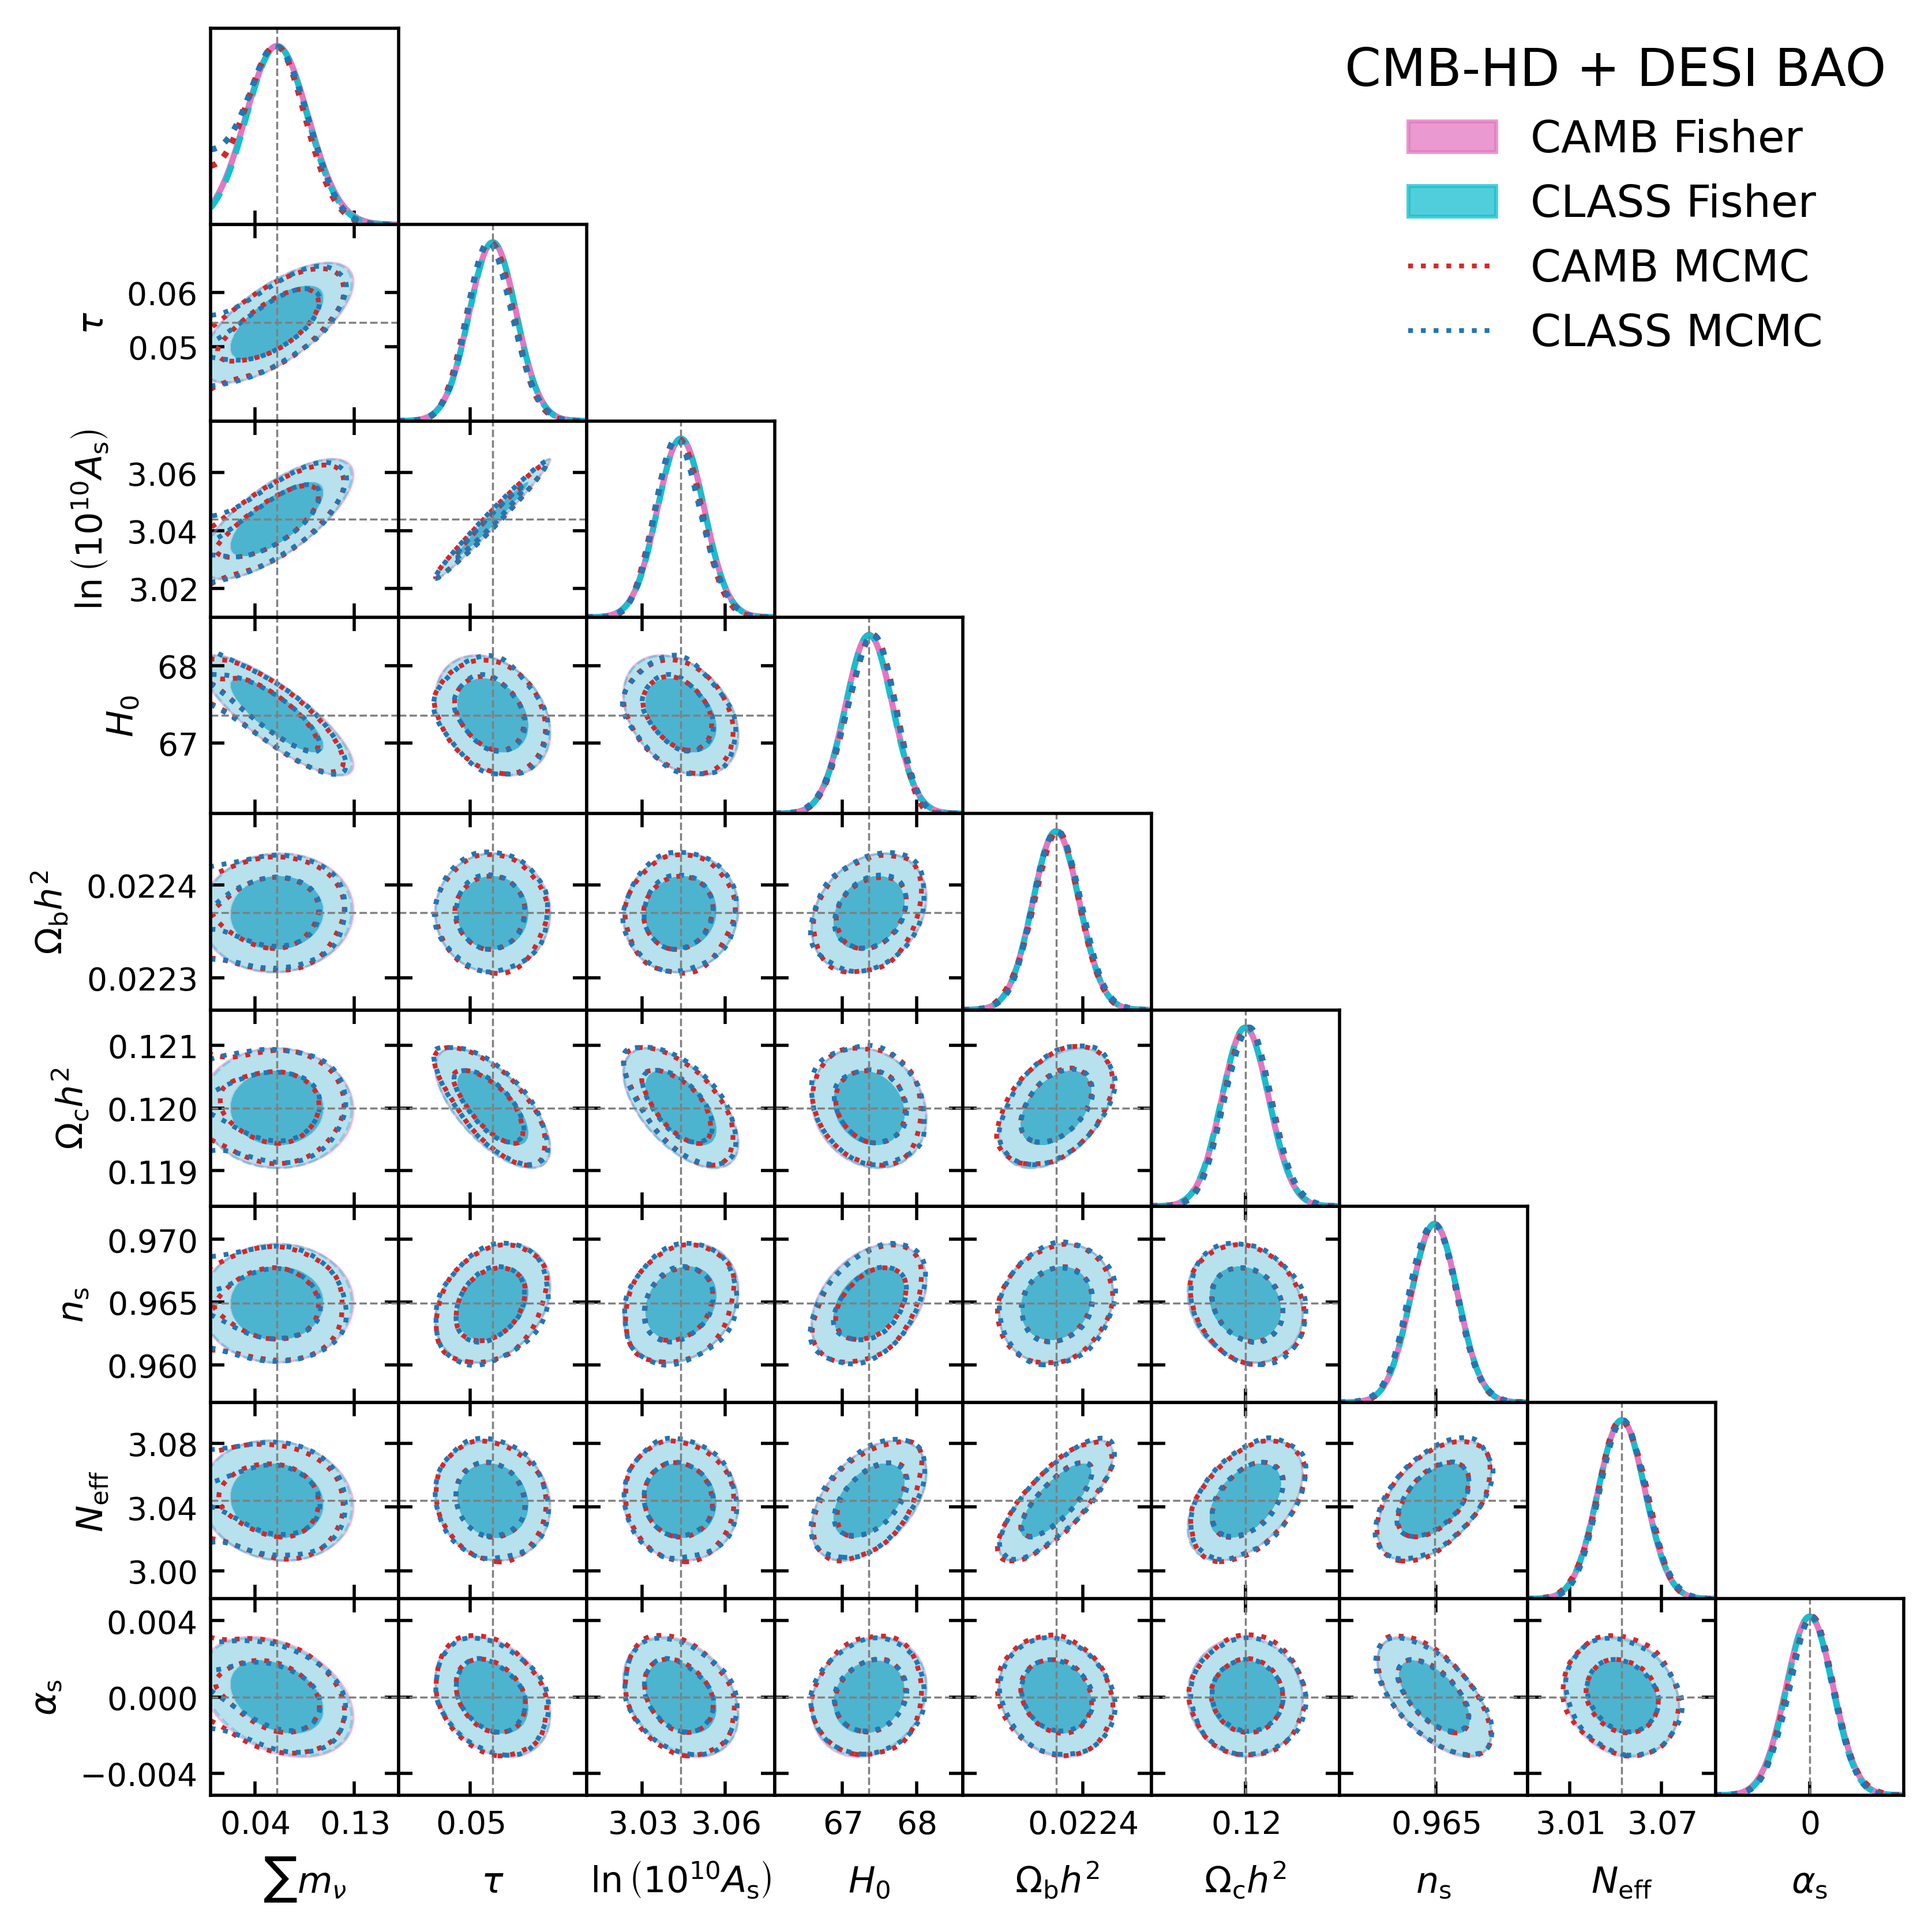

In [48]:
fig9_colors = ['tab:pink', 'tab:cyan', 'tab:red', 'tab:blue']
fig9_filled = [True, True, False, False]
fig9_ls = ['-', '--', ':', ':']
fig9_lw_1d = [1.5, 1.5, 1.5, 1.5]
fig9_lw = [1.5, 1.5, 1.2, 1.2]
fig9_legend_labels = ['CAMB Fisher', 'CLASS Fisher', 'CAMB MCMC', 'CLASS MCMC']

plt.rcParams['legend.title_fontsize'] = 13

g = plots.get_subplot_plotter(width_inch=6.5)
g.settings.scaling_factor = 1.1
g.settings.legend_fontsize = 14
g.settings.axes_fontsize = 11
g.settings.axes_labelsize = 12
g.settings.constrained_layout = True
g.settings.figure_legend_frame = False
g.triangle_plot([camb_fisher_samples, class_fisher_samples,
                 camb_mcmc_samples, class_mcmc_samples],
                params=nine_params,
                filled=fig9_filled, param_limits={'mnu': [0, 0.17]},
                diag1d_kwargs={'lws': fig9_lw_1d, 'ls': fig9_ls},
                contour_colors=fig9_colors,
                contour_args=[{'alpha': 0.75}, {'alpha': 0.75},
                              {'alpha': 1.0}, {'alpha': 1.0}],
                ls=fig9_ls, lws=fig9_lw,
                legend_loc='upper right',
                legend_labels=fig9_legend_labels, markers=fig9_fid_params)
g.legend.set_title(r'CMB-HD + DESI BAO')

# reduce the tick clutter in the ns column:
g.subplots[-1, 6].set_xticks([0.965])

plt.gcf().set_dpi(500)
save_figure('fig9')
plt.show()

plt.rcParams['legend.title_fontsize'] = None

In [49]:
# Compare the Fisher and MCMC error bars (CAMB and CLASS):
class_mcmc_errors_camb_names = {}
for p in errs_with_desi_camb.keys():
    class_mcmc_errors_camb_names[p] = class_mcmc_errors[camb_to_class_chain_params[p]]

table_list = [errs_with_desi_camb, camb_mcmc_errors,
              ratio(errs_with_desi_camb, camb_mcmc_errors),
              errs_with_desi_class, class_mcmc_errors_camb_names,
              ratio(errs_with_desi_class, class_mcmc_errors_camb_names)]
label_list = ['CAMB + DESI fisher', 'CAMB + DESI MCMC',
              'CAMB Ratio (Fisher/MCMC)', 'CLASS + DESI fisher',
              'CLASS + DESI MCMC', 'CLASS Ratio (Fisher/MCMC)']
print_table(table_list, label_list, list_of_keys=nine_params)

,CAMB + DESI fisher,CAMB + DESI MCMC,CAMB Ratio (Fisher/MCMC),CLASS + DESI fisher,CLASS + DESI MCMC,CLASS Ratio (Fisher/MCMC)
mnu,0.028232,0.027279,1.034955,0.027559,0.028457,0.968455
tau,0.004538,0.004369,1.038720,0.004502,0.004416,1.019425
logA,0.008473,0.008062,1.051051,0.008408,0.008254,1.018676
H0,0.317110,0.306650,1.034109,0.314379,0.316699,0.992675
ombh2,0.000026,0.000026,0.999541,0.000026,0.000026,0.993803
omch2,0.000389,0.000388,1.002068,0.000392,0.000389,1.006900
ns,0.001932,0.001937,0.997592,0.001934,0.001976,0.978355
nnu,0.015340,0.015439,0.993588,0.015380,0.015294,1.005588
nrun,0.001288,0.001281,1.005078,0.001257,0.001241,1.013618


In [50]:
# The CAMB/CLASS Fisher-vs-MCMC error comparison as it appears in the
# paper's table: rounded to the significant figures used there, with the
# ratios. The input dicts are all keyed by CAMB parameter names.
fisher_mcmc_row_order = ['ombh2', 'omch2', 'H0', 'tau', 'logA', 'ns',
                         'nrun', 'nnu', 'mnu']
fisher_mcmc_columns = ['CAMB Fisher', 'CLASS Fisher', 'Ratio (CAMB / CLASS Fisher)',
                       'CAMB MCMC', 'CLASS MCMC',
                       'CAMB Ratio (Fisher / MCMC)', 'CLASS Ratio (Fisher / MCMC)']


def fisher_mcmc_table(camb_fisher, class_fisher, camb_mcmc, class_mcmc,
                      order=fisher_mcmc_row_order,
                      sig_figs=err_sig_figs, rdec=ratio_decimals):
    """The columns of `fisher_mcmc_columns` for `print_table`, as
    formatted strings."""
    columns = {label: {} for label in fisher_mcmc_columns}
    for p in order:
        n = sig_figs[p]
        r = f'{{:.{rdec}f}}'             # ratio format (fixed decimals)
        cf, clf = camb_fisher[p], class_fisher[p]
        cm, clm = camb_mcmc[p], class_mcmc[p]
        columns['CAMB Fisher'][p] = sigfig(cf, n)
        columns['CLASS Fisher'][p] = sigfig(clf, n)
        columns['Ratio (CAMB / CLASS Fisher)'][p] = r.format(cf / clf)
        columns['CAMB MCMC'][p] = sigfig(cm, n)
        columns['CLASS MCMC'][p] = sigfig(clm, n)
        columns['CAMB Ratio (Fisher / MCMC)'][p] = r.format(cf / cm)
        columns['CLASS Ratio (Fisher / MCMC)'][p] = r.format(clf / clm)
    return [columns[label] for label in fisher_mcmc_columns]


print_table(fisher_mcmc_table(errs_with_desi_camb, errs_with_desi_class,
                              camb_mcmc_errors, class_mcmc_errors_camb_names),
            fisher_mcmc_columns,
            title='CMB-HD + DESI, 9 parameters: Fisher and MCMC 1-sigma errors as in the paper',
            list_of_keys=fisher_mcmc_row_order)


 CMB-HD + DESI, 9 parameters: Fisher and MCMC 1-sigma errors as in the paper


,CAMB Fisher,CLASS Fisher,Ratio (CAMB / CLASS Fisher),CAMB MCMC,CLASS MCMC,CAMB Ratio (Fisher / MCMC),CLASS Ratio (Fisher / MCMC)
ombh2,0.000026,0.000026,1.001,0.000026,0.000026,1.000,0.994
omch2,0.000389,0.000392,0.994,0.000388,0.000389,1.002,1.007
H0,0.317,0.314,1.009,0.307,0.317,1.034,0.993
tau,0.00454,0.00450,1.008,0.00437,0.00442,1.039,1.019
logA,0.00847,0.00841,1.008,0.00806,0.00825,1.051,1.019
ns,0.00193,0.00193,0.999,0.00194,0.00198,0.998,0.978
nrun,0.00129,0.00126,1.024,0.00128,0.00124,1.005,1.014
nnu,0.0153,0.0154,0.997,0.0154,0.0153,0.994,1.006
mnu,0.0282,0.0276,1.024,0.0273,0.0285,1.035,0.968


# Figure 10

Binned $e^{-2\tau} \mathcal{P}(k)$ constraints with finer (30-bin) binning,
compared to the official P-ACT-LB binned-P(k) chain.

In [51]:
# The marginalized statistics of the 30-bin chains (including the official
# P-ACT-LB chain) were loaded in Part 1. Here, load the 62-bin (kmax = 50)
# binning they use (k bin centers, fiducial P(k), and bin edges):
ks_62bin, pk_62bin = np.loadtxt(
    os.path.join(binning_data_path, 'binning_62bins.txt'), unpack=True)
bin_edges_62 = np.loadtxt(
    os.path.join(binning_data_path, 'act_bin_edges_kmax50.txt'))

0.021462568110678277
0.015967402761903202
0.01576541245426923


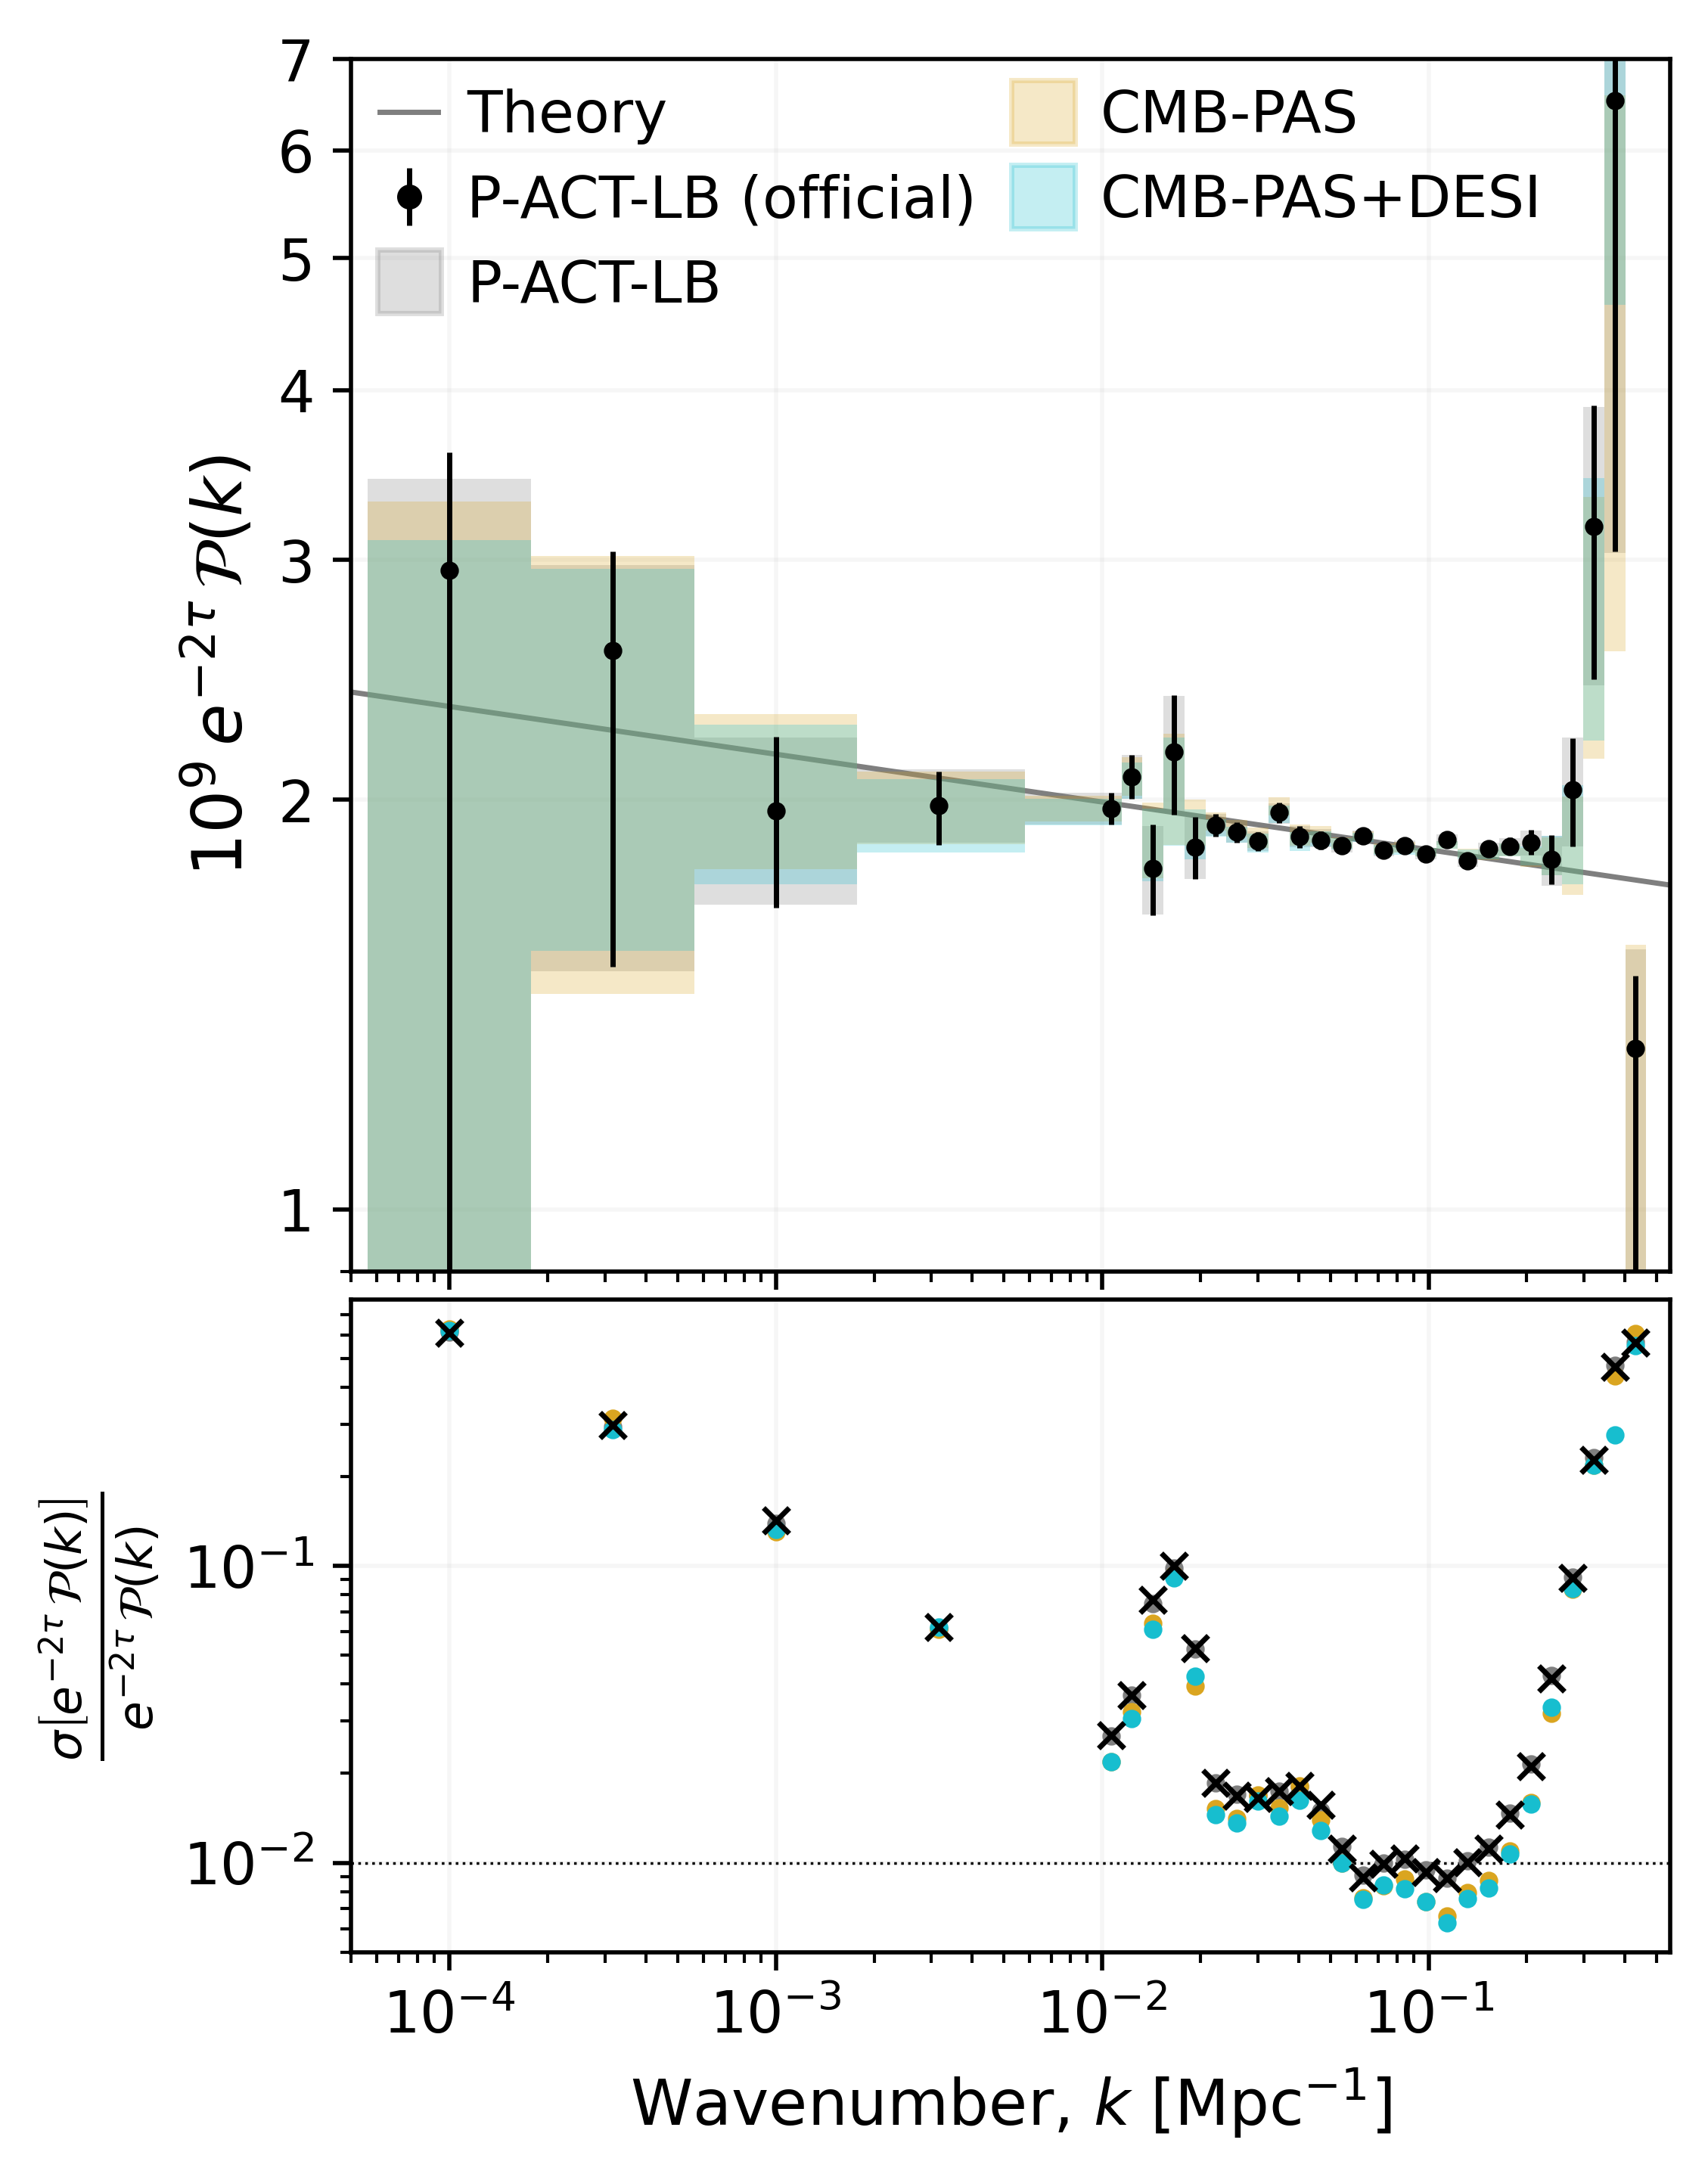

In [52]:
fig10_legend_kwargs = {
    'frameon': False,
    'fontsize': legend_fontsize,
    'loc': 'upper left',
    'bbox_to_anchor': (0, 1),
    'ncol': 2,
    'columnspacing': 0.65,
    'handletextpad': 0.5,
    'handlelength': 1.0,
    'markerscale': 1.5,
    'borderpad': 0,
}

plt_kmin, plt_kmax = 5e-5, 5.5e-1
plt_ymin, plt_ymax = 0.9, 7

ks_extended_30bin = np.logspace(np.log10(plt_kmin), np.log10(plt_kmax), 500)
hd_pk_extended_30bin = [1e9 * np.exp(-2 * tau) * hd_Pk(k) for k in ks_extended_30bin]

fig, (ax_main, ax_frac) = plt.subplots(
    2, 1, figsize=(4.5, 6.5), dpi=500, facecolor='w', sharex=True,
    gridspec_kw={'height_ratios': [0.65, 0.35], 'hspace': 0.03})

ks_chains_30bin = ks_62bin[0:30]

fig10_sample_sets = [
    ('P-ACT-LB', p_act_means_30bin, p_act_asymmetric_errors_30bin, 'tab:grey'),
    ('CMB-PAS', pas_means_30bin, pas_asymmetric_errors_30bin, 'goldenrod'),
    ('CMB-PAS+DESI', pas_desi_means_30bin, pas_desi_asymmetric_errors_30bin, 'tab:cyan'),
]

# --- main panel ---
set_loglog(ax_main)
ax_main.plot(ks_extended_30bin, hd_pk_extended_30bin, linestyle='-',
             color='tab:gray', linewidth=1, zorder=1, label='Theory')
for label, means, (lower_errs, upper_errs), color in fig10_sample_sets:
    add_box_errors(ax_main, ks_chains_30bin, means, lower_errs, upper_errs,
                   color=color, alpha=0.25, edges=bin_edges_62)
ax_main.errorbar(ks_62bin[0:30], official_means, yerr=official_asymmetric_errors,
                 fmt='.', markersize=5, capsize=0.0, elinewidth=elinewidth,
                 color='k', zorder=3, label='P-ACT-LB (official)')
ax_main.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
ax_main.set_yticks(list(range(1, plt_ymax + 1)))
ax_main.set_yticklabels([str(i) for i in range(1, plt_ymax + 1)])
ax_main.set_ylabel(pk_ylabel_top, fontsize=axis_label_fontsize + 1)
for label, means, errs, color in fig10_sample_sets:
    ax_main.plot([], [], 's', color=color, alpha=0.25, markersize=8, label=label)

desired_order = ['Theory', 'P-ACT-LB (official)', 'P-ACT-LB', 'CMB-PAS',
                 'CMB-PAS+DESI']
handles, labels = ax_main.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ordered_handles = [by_label[l] for l in desired_order if l in by_label]
ordered_labels = [l for l in desired_order if l in by_label]
ax_main.legend(ordered_handles, ordered_labels, **fig10_legend_kwargs)

ax_main.set_ylim(plt_ymin, plt_ymax)
ax_main.set_xlim(plt_kmin, plt_kmax)
ax_main.grid(alpha=0.1)

# --- fractional-error panel ---
set_loglog(ax_frac)
ax_frac.axhline(y=0.01, color='k', ls=':', lw=0.5)
for label, means, (lower_errs, upper_errs), color in fig10_sample_sets:
    residuals = [np.mean([lower_errs[i], upper_errs[i]]) / means[i]
                 for i in range(len(means))]
    print(residuals[-6])
    ax_frac.plot(ks_chains_30bin, residuals, ls='None', marker='.',
                 markersize=5, color=color)
residual_act = [np.mean([official_upper_errs[i], official_lower_errs[i]]) / official_means[i]
                for i in range(len(official_upper_errs))]
ax_frac.plot(ks_62bin[0:30], residual_act, marker='x', markersize=5,
             ls='None', color='k')
ax_frac.set_xlabel(pk_xlabel, fontsize=axis_label_fontsize)
ax_frac.set_ylabel(pk_ylabel_frac, fontsize=axis_label_fontsize + 1)
ax_frac.margins(0.05)
ax_frac.set_xlim(plt_kmin, plt_kmax)
ax_frac.grid(alpha=0.1)

plt.subplots_adjust(hspace=0.03)
save_figure('fig10', bbox_inches='tight')
plt.show()

# Figure 11

Same as Figure 3, but including the CMB-PAS + DESI DR2 constraints and
omitting the SO-like forecast.

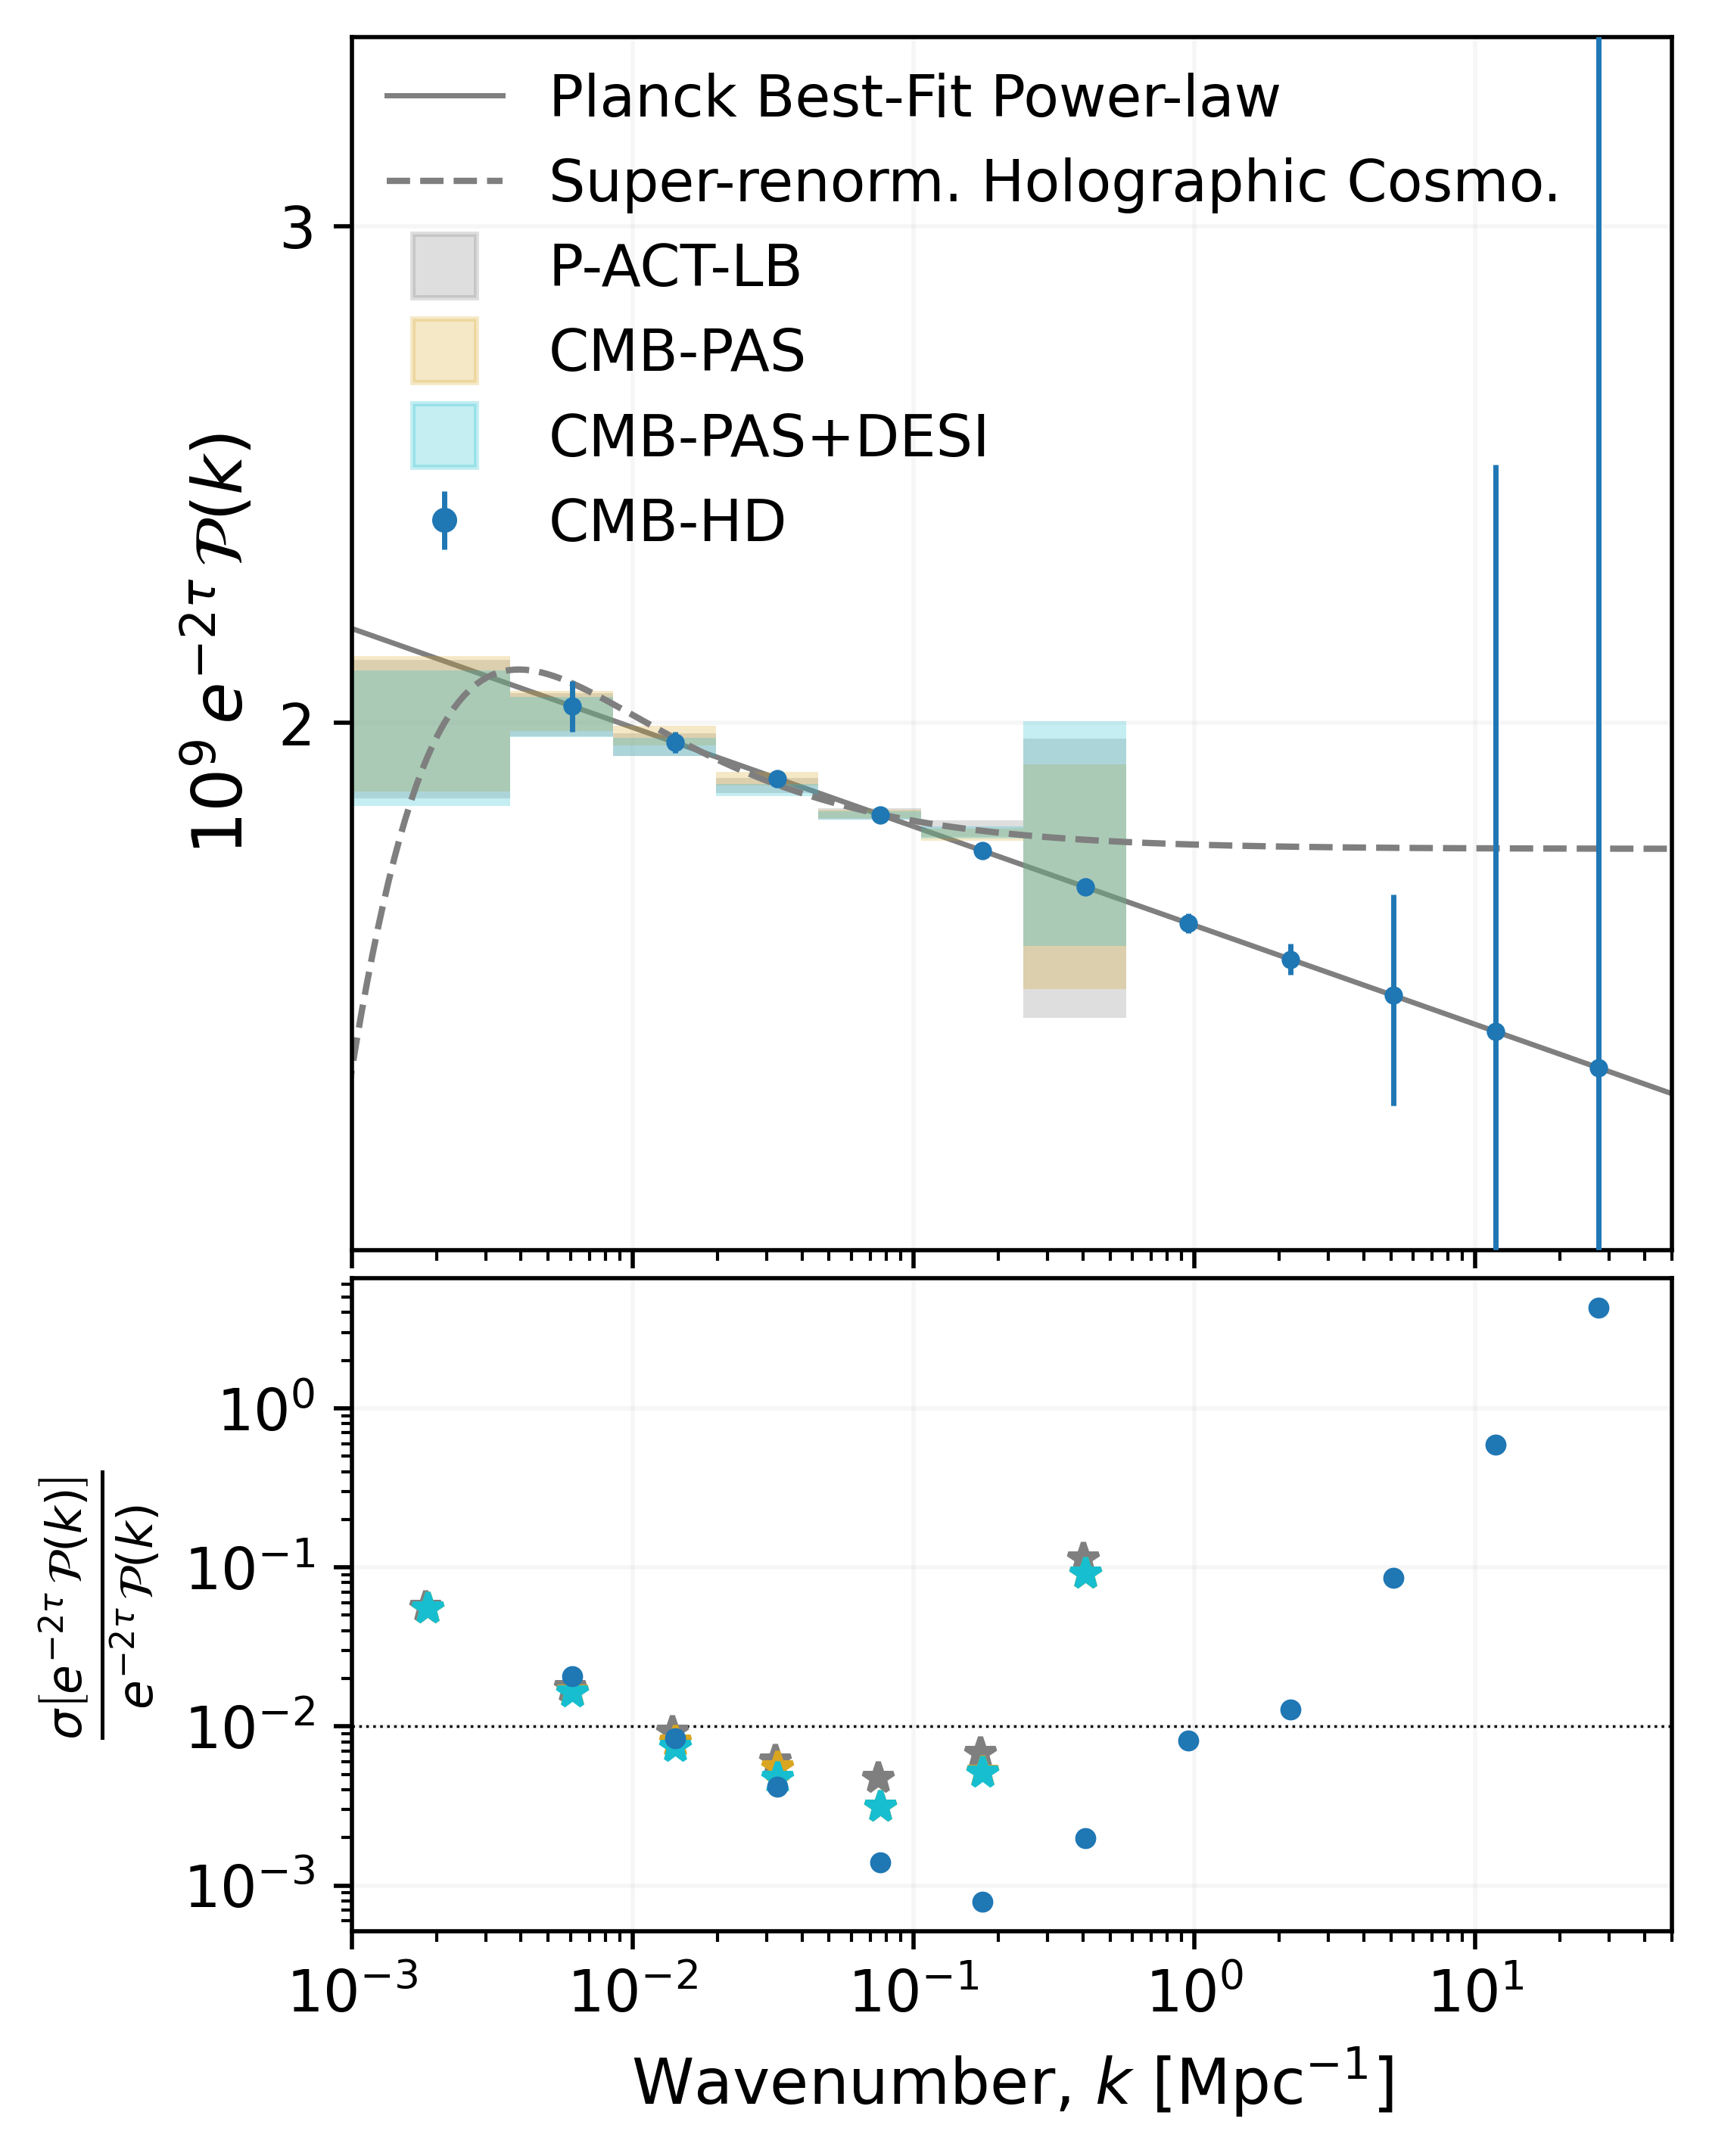

In [53]:
fig11_legend_kwargs = {
    'frameon': False,
    'fontsize': legend_fontsize,
    'loc': 'upper left',
    'bbox_to_anchor': (0, 1),
    'markerscale': 1.5,
    'borderpad': 0.1,
}

plt_kmin, plt_kmax = 1e-3, 50

fig, (ax_main, ax_frac) = plt.subplots(
    2, 1, figsize=(4.5, 6.5), dpi=500, facecolor='w', sharex=True,
    gridspec_kw={'height_ratios': [0.65, 0.35], 'hspace': 0.03})

fig11_sample_sets = [
    ('P-ACT-LB', p_act_means, p_act_asymmetric_errors, 'tab:grey'),
    ('CMB-PAS', pas_means, pas_asymmetric_errors, 'goldenrod'),
    ('CMB-PAS+DESI', pas_desi_means, pas_desi_asymmetric_errors, 'tab:cyan'),
]

# --- main panel ---
set_loglog(ax_main)
ax_main.plot(ks_extended, hd_pk_extended, linestyle='-', color='tab:gray',
             linewidth=1, zorder=1, label='Planck Best-Fit Power-law')
for label, means, (lower_errs, upper_errs), color in fig11_sample_sets:
    add_box_errors(ax_main, ks_chains_7bin, means, lower_errs, upper_errs,
                   color=color, alpha=0.25, edges=pk_bin_edges[:8])
ax_main.errorbar(binning['k bin center [Mpc^-1]'], eneg2tau_hd_pk_eleven_bins,
                 yerr=hd_err, fmt='.', markersize=5, capsize=0.0,
                 elinewidth=elinewidth, color='tab:blue', zorder=3,
                 label='CMB-HD')
ax_main.plot(ks_extended, srhc_pk_extended, linestyle='--', color='tab:grey',
             linewidth=1.2, zorder=2, label='Super-renorm. Holographic Cosmo.')
ax_main.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
ax_main.set_yticks(list(range(1, 7)))
ax_main.set_yticklabels([str(i) for i in range(1, 7)])
ax_main.set_ylabel(pk_ylabel_top, fontsize=axis_label_fontsize + 1)
for label, means, errs, color in fig11_sample_sets:
    ax_main.plot([], [], 's', color=color, alpha=0.25, markersize=8, label=label)
ax_main.legend(**fig11_legend_kwargs)
ax_main.set_ylim(1.3, 3.5)
ax_main.set_xlim(plt_kmin, plt_kmax)
ax_main.grid(alpha=0.1)

# --- fractional-error panel ---
set_loglog(ax_frac)
ax_frac.axhline(y=0.01, color='k', ls=':', lw=0.5)

offset_ks = []
for i in range (0, len(ks_chains_7bin)):
    offset_ks.append(0.98 * ks_chains_7bin[i])
ks = [offset_ks, ks_chains_7bin,ks_chains_7bin]
j =  0
for label, means, (lower_errs, upper_errs), color in fig11_sample_sets:
    residuals = [np.mean([lower_errs[i], upper_errs[i]]) / means[i]
                 for i in range(len(means))]
    ax_frac.plot(ks[j], residuals, marker='*', markersize=6,
                 ls='None', color=color)
    j+=1

ax_frac.plot(binning['k bin center [Mpc^-1]'], residual_hd,
             marker='.', markersize=6, ls='None', color='tab:blue')
ax_frac.set_xlabel(pk_xlabel, fontsize=axis_label_fontsize)
ax_frac.set_ylabel(pk_ylabel_frac, fontsize=axis_label_fontsize + 1)
ax_frac.margins(0.05)
ax_frac.set_xlim(plt_kmin, plt_kmax)
ax_frac.grid(alpha=0.1)

plt.subplots_adjust(hspace=0.03)
save_figure('fig11', bbox_inches='tight')
plt.show()

## Binned-P(k) table

The binned-P(k) table of the paper, in units of
$10^9 e^{-2\tau} \mathcal{P}(k)$. The data columns (P-ACT-LB, CMB-PAS,
CMB-PAS + DESI) show the mean $\pm$ 1-sigma from the chains; the SO-like
and CMB-HD columns show only the $\pm$ 1-sigma Fisher error.

In [54]:
# 12 k-labels exactly as displayed in the table (first two truncated, not
# rounded):
table_k_labels = ['0.0018', '0.0060', '0.0141', '0.0327', '0.0759', '0.176',
                  '0.408', '0.947', '2.20', '5.09', '11.8', '27.4']

# column data: chains carry means + symmetric 1-sigma (tot_err);
# SO/HD carry only the symmetric 1-sigma Fisher error.
chain_cols = [
    ('P-ACT-LB', p_act_means, p_act_tot_err),
    ('CMB-PAS', pas_means, pas_tot_err),
    ('CMB-PAS + DESI', pas_desi_means, pas_desi_tot_err),
]
fisher_cols = [('SO-like', so_err), ('CMB-HD', hd_err)]   # error only


def mean_pm_err(mean, err):
    return f'{mean:.3f} ± {err:.3f}'


def err_only(err):
    return f'± {sigfig(err, 3)}'


binned_table_list, binned_table_labels = [], []
for label, mean_arr, err_arr in chain_cols:
    # chains: present while the row index is within the chain arrays (rows 0-6)
    binned_table_list.append(
        {k: (mean_pm_err(mean_arr[i], err_arr[i]) if i < len(mean_arr) else '---')
         for i, k in enumerate(table_k_labels)})
    binned_table_labels.append(label)
for label, err_arr in fisher_cols:
    # SO/HD: offset by one (the first chain bin is chains-only)
    binned_table_list.append(
        {k: (err_only(err_arr[i - 1]) if 0 <= i - 1 < len(err_arr) else '---')
         for i, k in enumerate(table_k_labels)})
    binned_table_labels.append(label)

print_table(binned_table_list, binned_table_labels,
            title='Binned P(k), in units of 1e9 e^(-2 tau) P(k): mean ± 1-sigma (chains), ± 1-sigma (Fisher)',
            list_of_keys=table_k_labels)


 Binned P(k), in units of 1e9 e^(-2 tau) P(k): mean ± 1-sigma (chains), ± 1-sigma (Fisher)


,P-ACT-LB,CMB-PAS,CMB-PAS + DESI,SO-like,CMB-HD
0.0018,1.992 ± 0.113,2.001 ± 0.111,1.978 ± 0.110,---,---
0.0060,2.013 ± 0.036,2.019 ± 0.034,2.009 ± 0.033,± 0.0428,± 0.0420
0.0141,1.964 ± 0.018,1.979 ± 0.016,1.961 ± 0.015,± 0.0156,± 0.0167
0.0327,1.900 ± 0.012,1.911 ± 0.011,1.893 ± 0.009,± 0.00837,± 0.00802
0.0759,1.856 ± 0.009,1.856 ± 0.006,1.854 ± 0.006,± 0.00274,± 0.00261
0.176,1.835 ± 0.013,1.825 ± 0.010,1.828 ± 0.009,± 0.00182,± 0.00143
0.408,1.769 ± 0.206,1.771 ± 0.164,1.834 ± 0.167,± 0.0196,± 0.00346
0.947,---,---,---,± 0.153,± 0.0139
2.20,---,---,---,---,± 0.0211
5.09,---,---,---,---,± 0.138
